# Latent Volatility Modelling Through Bayesian Machine Learning

Estimating latent volatility trends via Bayesian inference on daily S&P 500 data. Models are developed on priors, tested under in-sample regression, and evaluated under sequential (out-of-sample) updating — see below for each stage.


## What is Volatility?

Volatility is defined as the standard deviation of daily log returns — an unobservable ("latent") quantity, since it's not directly published like price. 

## Import and Process Data

Data is imported from Yahoo Finance in three sets, corresponding to the three stages of the analysis:

- **2013–2017**: developing priors
- **2018–2021**: testing under regression (in-sample) conditions
- **2022–2025**: testing under sequential updating (out-of-sample)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import norm, kstest
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf
import statsmodels.api as sm
import yfinance as yf
np.random.seed(42)

# Download data
full_data = yf.download("SPY",
                         start="2013-01-01",
                         end="2025-12-31",
                         auto_adjust=True,
                         progress=False)


Below, the daily log returns are computed for each time period.

In [2]:
def data_returns(data):
    '''Compute log returns from a price series r_t = ln(P_t/P_(t-1))'''
    return np.log(data["Close"]).diff().dropna()
full_returns = data_returns(full_data)

# Split by date
prior_returns      = full_returns["2013-01-01":"2017-12-31"]
regression_returns = full_returns["2018-01-01":"2021-12-31"]
sequential_returns = full_returns["2022-01-01":"2025-12-31"]

# 1d for computation
prior_returns_1d      = prior_returns.values.flatten()
regression_returns_1d = regression_returns.values.flatten()
sequential_returns_1d = sequential_returns.values.flatten()

prior_dates = prior_returns.index
regression_dates = regression_returns.index
sequential_dates = sequential_returns.index

# check type/date
print(type(prior_returns))          
print(type(prior_returns_1d))        

print(prior_returns.shape)          
print(prior_returns_1d.shape)

<class 'pandas.core.frame.DataFrame'>
<class 'numpy.ndarray'>
(1258, 1)
(1258,)


### Dates indices for all periods

For future computation, it makes sense to lay out the date indices for all the periods.

In [3]:
# Prior period
def print_date(dates, title):
      print(f"{title}: {dates[0].date()} to {dates[-1].date()}, "
            f"n={len(dates)}")

print_date(prior_dates, 'Prior_Returns')
print_date(regression_dates, 'Regression_Returns')
print_date(sequential_dates, 'Sequential_Returns')

Prior_Returns: 2013-01-03 to 2017-12-29, n=1258
Regression_Returns: 2018-01-02 to 2021-12-31, n=1008
Sequential_Returns: 2022-01-03 to 2025-12-30, n=1002


# General Procedure

3 models will be tested, a baseline rolling average, a time series model and a stochastic model.

Note that each model will be developed and then tested on both regression and sequential data. At the end of this notebook, the models will be compared to each other using different metrics like Realized Volatility (QLIKE and Realized Volatility Coverage), PIT Histogram and Return Coverage



## Regression

## Regression Conditions

Priors developed on 2013–2017 data are updated using 2018–2021 data to obtain posterior samples for model parameters.

This is an in-sample test: the fitted parameters are propagated forward through the regression-period data itself to obtain implied volatility paths.



## Sequential Updating

Starting with posterior samples from the regression period, models are sequentially updated over windows spanning 2022–2025.

In each window:
1. Volatility is forecast using the previous window's posterior samples
2. The posterior is then updated by treating the previous window's posterior as the new prior (via fitting posterior samples to the original prior distributions), conditioned on the current window's data

## Baseline: Rolling Average

The rolling average calculates the volatility over the past month 21 days, and uses it as the estimate for the volatility over the next 21 days.

This volatility is the sample standard deviation of the previous $h$ log returns:

\begin{equation*}
    \hat{\sigma}_t^{roll} = \sqrt{\frac{1}{h-1}
    \sum_{i=0}^{h-1}(r_{t-i} - \bar{r}_t)^2}
\end{equation*}
where $\bar{r}_t = \frac{1}{h}\sum_{i=0}^{h-1} r_{t-i}$ is the rolling mean and $h=21$

In [4]:
def rolling_vol(returns, h=21):
    '''Return Rolling Volatility'''
    return returns.rolling(h).std()


full_rolling = rolling_vol(full_returns)

rolling_prior      = full_rolling.loc[prior_dates].dropna()
rolling_regression = full_rolling.loc[regression_dates].dropna()
rolling_sequential = full_rolling.loc[sequential_dates].dropna()

rolling_prior_1d      = rolling_prior.values.flatten()
rolling_regression_1d = rolling_regression.values.flatten()
rolling_sequential_1d = rolling_sequential.values.flatten()

rolling_prior_dates      = rolling_prior.index
rolling_regression_dates = rolling_regression.index
rolling_sequential_dates = rolling_sequential.index

print_date(rolling_prior_dates, 'Prior_Rolling')
print_date(rolling_regression_dates, 'Regression_Rolling')
print_date(rolling_sequential_dates, 'Sequential_Rolling')

Prior_Rolling: 2013-02-01 to 2017-12-29, n=1238
Regression_Rolling: 2018-01-02 to 2021-12-31, n=1008
Sequential_Rolling: 2022-01-03 to 2025-12-30, n=1002


## Metrics


## Historical Volatility

### What is Historical Volatility

The historical volatility is the standard deviation of log returns over the next 21 log returns. It represents the average volatility throughout that period by assuming constant volatility throughout this period.

In particular, 

\begin{equation*}
    \hat{\sigma}_t^{empirical} = \sqrt{\frac{1}{h-1}
    \sum_{i=1}^{h}(r_{t+i} - \bar{r}_t)^2}
\end{equation*}

where $r_{t}=ln(\frac{P_{t}}{P_{t-1}})$ and $\bar{r}_t = \frac{1}{h}\sum_{i=1}^{h} r_{t+i}$ and $h=21$ 



### Model Historical Volatility

In order to use the empirical historical volatility for a fair comparison, a model equivalent historical volatility is required.

For the rolling average, this is relatively straightforward since the rolling volatility estimates are already in the appropriate format

Note that the final values have NaN since computing their realized volatility would require data from 2026 onwards.

In [5]:
def historical_vol(returns, h=21):
    '''Compute forward-looking historical volatility: std of r_{t+1},...,r_{t+h}.'''
    return returns.rolling(h).std().shift(-h)

full_hv = historical_vol(full_returns)

hv_prior      = full_hv.loc[prior_dates].dropna()
hv_regression = full_hv.loc[regression_dates].dropna()
hv_sequential = full_hv.loc[sequential_dates].dropna()

hv_prior_1d      = hv_prior.values.flatten()
hv_regression_1d = hv_regression.values.flatten()
hv_sequential_1d = hv_sequential.values.flatten()

hv_prior_dates      = hv_prior.index
hv_regression_dates = hv_regression.index
hv_sequential_dates = hv_sequential.index

print_date(hv_prior_dates, 'Prior_hv')
print_date(hv_regression_dates, 'Regression_hv')
print_date(hv_sequential_dates, 'Sequential_hv')

Prior_hv: 2013-01-03 to 2017-12-29, n=1258
Regression_hv: 2018-01-02 to 2021-12-31, n=1008
Sequential_hv: 2022-01-03 to 2025-11-28, n=981


### QLIKE Comparison with Realized Voalatility

### What is QLIKE?

The QLIKE estimator compares the pointwise estimates of realized volatility.

\begin{equation*}
    \text{QLIKE}(\hat{\sigma}_t, RV_t) = \frac{RV_t^2}{\hat{\sigma}_t^2} 
    - \log\!\left(\frac{RV_t^2}{\hat{\sigma}_t^2}\right) - 1
\end{equation*}

### Why QLIKE?

QLIKE Loss is used since it takes into account the volatility asymmetry (generally underpredicting volatility is worse than overpredicting volatility)

Furthermore, the QLIKE loss is known to work well with volatility proxies (like historical volatility).

### Interpreting QLIKE

Simply put, a lower mean QLIKE loss is better since it suggests the model closely fits the realized volatility. 

In [6]:
def align_series(series_a, series_b):
    '''Align two Series on their common dates, returning aligned 1D arrays + the shared index.'''
    common_dates = series_a.index.intersection(series_b.index)
    a_aligned = series_a.loc[common_dates]
    b_aligned = series_b.loc[common_dates]
    return a_aligned.values.flatten(), b_aligned.values.flatten(), common_dates

forecast_prior_rolling,      actual_prior_rolling,      dates_prior_rolling      = align_series(rolling_prior, hv_prior)
forecast_regression_rolling, actual_regression_rolling, dates_regression_rolling = align_series(rolling_regression, hv_regression)
forecast_sequential_rolling, actual_sequential_rolling, dates_sequential_rolling  = align_series(rolling_sequential, hv_sequential)

print_date(dates_prior_rolling, 'Prior_Aligned')
print_date(dates_regression_rolling, 'Regression_Aligned')
print_date(dates_sequential_rolling, 'Sequential_Aligned')

Prior_Aligned: 2013-02-01 to 2017-12-29, n=1238
Regression_Aligned: 2018-01-02 to 2021-12-31, n=1008
Sequential_Aligned: 2022-01-03 to 2025-11-28, n=981


In [7]:
def qlike(sigma, rv):
    ratio = rv**2 / sigma**2
    return ratio - np.log(ratio) - 1

ql_regression = qlike(forecast_regression_rolling, actual_regression_rolling)
ql_sequential = qlike(forecast_sequential_rolling, actual_sequential_rolling)

print(f"QLIKE (regression): mean = {ql_regression.mean():.4f}")
print(f"QLIKE (sequential): mean = {ql_sequential.mean():.4f}")

QLIKE (regression): mean = 1.2659
QLIKE (sequential): mean = 0.3955


Note that the high QLIKE values in the regression period is likely due to COVID.

## 

In the regression section, COVID is important including the COVID spike etc.

For the regression segregate the QLIKE keeping COVID in mind.


In [9]:
covid_start_date = pd.Timestamp("2020-01-30")
covid_end_date = pd.Timestamp("2020-04-30")

def covid_indices(dates, start_date=covid_start_date, end_date=covid_end_date):
    return np.searchsorted(dates, start_date), np.searchsorted(dates, end_date)

def covid_breakdown(forecast, actual, start_idx, end_idx, metric_fn):
    values = metric_fn(forecast, actual)
    return {
        'pre':   values[:start_idx].mean(),
        'covid': values[start_idx:end_idx].mean(),
        'post':  values[end_idx:].mean(),
    }


def print_covid_breakdown(breakdown, dates, start_idx, end_idx, label="", metric_name="Metric"):
    print(f"{label} — COVID start: {dates[start_idx].date()} (obs {start_idx})")
    print(f"{label} — COVID end:   {dates[end_idx].date()} (obs {end_idx})")
    print(f"{label} — Pre-COVID {metric_name}:  {breakdown['pre']:.4f}")
    print(f"{label} — COVID {metric_name}:      {breakdown['covid']:.4f}")
    print(f"{label} — Post-COVID {metric_name}: {breakdown['post']:.4f}")

In [10]:
covid_start_rolling, covid_end_rolling = covid_indices(dates_regression_rolling)

qlike_breakdown_rolling = covid_breakdown(
    forecast_regression_rolling, actual_regression_rolling,
    covid_start_rolling, covid_end_rolling, qlike
)
print_covid_breakdown(
    qlike_breakdown_rolling, dates_regression_rolling, covid_start_rolling, covid_end_rolling,
    label="Rolling Average", metric_name="QLIKE"
)

Rolling Average — COVID start: 2020-01-30 (obs 522)
Rolling Average — COVID end:   2020-04-30 (obs 585)
Rolling Average — Pre-COVID QLIKE:  1.2380
Rolling Average — COVID QLIKE:      6.3624
Rolling Average — Post-COVID QLIKE: 0.5413


Historical Volatility Coverage for baseline

Since the baseline doesn't have a model assumption, need to assume normal distribution for this test to work

In [ ]:
def hv_coverage(forecast, actual, levels=[50, 60, 70, 80, 85, 90, 95, 99]):
    '''Compute log-normal noise-adjusted RV coverage at multiple CI levels.'''
    sigma_eta = np.std(np.log(actual) - np.log(forecast))
    results = {}
    for level in levels:
        _, _, inside, _ = hv_coverage_intervals(forecast, actual, level, sigma_eta)
        results[level] = np.mean(inside)
    return sigma_eta, results


def hv_coverage_intervals(forecast, actual, level=90, sigma_eta=None):
    '''Return lower/upper bounds and inside-mask for a single CI level.
    If sigma_eta is not provided, it is computed from forecast/actual.'''
    if sigma_eta is None:
        sigma_eta = np.std(np.log(actual) - np.log(forecast))
    z = norm.ppf(1 - (100 - level) / 200)
    lower = forecast * np.exp(-z * sigma_eta)
    upper = forecast * np.exp(+z * sigma_eta)
    inside = (actual >= lower) & (actual <= upper)
    return lower, upper, inside, sigma_eta


def hv_coverage_covid_breakdown(inside_mask, covid_start_idx, covid_end_idx):
    '''Split an inside-CI boolean mask into pre/during/post-COVID coverage rates.'''
    return {
        'pre':   np.mean(inside_mask[:covid_start_idx]),
        'covid': np.mean(inside_mask[covid_start_idx:covid_end_idx]),
        'post':  np.mean(inside_mask[covid_end_idx:]),
    }


# ── Print helpers ─────────────────────────────────────────
def print_hv_coverage(sigma_eta, results, label=""):
    print(f"{label} — Measurement noise std: {sigma_eta:.4f}")
    print("Coverage at different CI levels:")
    print("-" * 40)
    for level, coverage in results.items():
        print(f"{level}% CI coverage: {coverage:.2%}")


def print_hv_coverage_covid(breakdown, label="", level=90):
    print(f"At {level}% CI coverage")
    print(f"{label} — Pre-COVID coverage:  {breakdown['pre']:.2%}")
    print(f"{label} — COVID coverage:      {breakdown['covid']:.2%}")
    print(f"{label} — Post-COVID coverage: {breakdown['post']:.2%}")

In [ ]:
# Multi-level summary
sigma_eta_regression_rolling, hv_coverage_rolling = hv_coverage(forecast_regression_rolling, actual_regression_rolling)
print_hv_coverage(sigma_eta_regression_rolling, hv_coverage_rolling, label="Rolling Average")

# Single-level (90%) bounds, reusing the already-computed sigma_eta for consistency
lower_90_regression_rolling, upper_90_regression_rolling, inside_90_regression_rolling, _ = hv_coverage_intervals(
    forecast_regression_rolling, actual_regression_rolling, level=90, sigma_eta=sigma_eta_regression_rolling
)

# COVID sub-period breakdown, reusing the same inside_90_rolling mask
covid_coverage_rolling = hv_coverage_covid_breakdown(inside_90_regression_rolling, covid_start_rolling, covid_end_rolling)
print_hv_coverage_covid(covid_coverage_rolling, label="Rolling Average")


Rolling Average — Measurement noise std: 0.5822
Coverage at different CI levels:
----------------------------------------
50% CI coverage: 52.28%
60% CI coverage: 61.41%
70% CI coverage: 70.54%
80% CI coverage: 80.46%
85% CI coverage: 84.42%
90% CI coverage: 89.78%
95% CI coverage: 95.34%
99% CI coverage: 99.11%
Rolling Average — Pre-COVID coverage:  88.70%
Rolling Average — COVID coverage:      52.38%
Rolling Average — Post-COVID coverage: 96.69%


### Output from these Results

While overall RV coverage for the rolling baseline is well-calibrated (e.g. 89.78% at the 90% level), this aggregate figure masks severe regime-dependent miscalibration: coverage drops to 52.38% during the COVID period, before overshooting to 96.69% immediately after. This illustrates the homoscedasticity limitation of the log-normal noise model (a single, period-wide $\hat\sigma_\eta$ cannot adapt to a volatility regime shift), compounded by the rolling average's inherent sluggishness in adjusting its own point forecast — both contributing to under-coverage during the shock and over-coverage in its immediate aftermath.


Still need the plot, PIT/KS stuff and other uniformity tests

In [13]:
def plot_hv_coverage(forecast, actual, dates, lower, upper, inside,
                      covid_start_date=None, covid_end_date=None,
                      label="Model", title=None):
    '''Plot forecast vs. actual with a shaded CI band and miss markers.'''
    fig, ax = plt.subplots(figsize=(12, 5))

    ax.fill_between(dates, lower, upper, alpha=0.3, color='blue', label='90% CI')
    ax.plot(dates, forecast, color='darkblue', lw=1.5, label=f'{label} Forecast')
    ax.plot(dates, actual, color='red', lw=1, label='Actual Historical Volatility')

    miss_idx = np.where(~inside)[0]
    miss_dates = dates[miss_idx]
    miss_pct = (1 - np.mean(inside)) * 100

    ax.scatter(miss_dates, actual[miss_idx], color='darkred', s=15, zorder=5,
               label=f'Misses ({miss_pct:.1f}%)')

    if covid_start_date is not None:
        ax.axvline(covid_start_date, color='black', linestyle='--', alpha=0.7, lw=1, label='COVID spike start')
    if covid_end_date is not None:
        ax.axvline(covid_end_date, color='black', linestyle=':', alpha=0.7, lw=1, label='COVID spike end')

    ax.set_title(title or f"{label}: Forecast vs. Actual with 90% CI")
    ax.set_xlabel("Dates")
    ax.set_ylabel("Volatility")
    ax.legend()
    plt.tight_layout()
    plt.show()

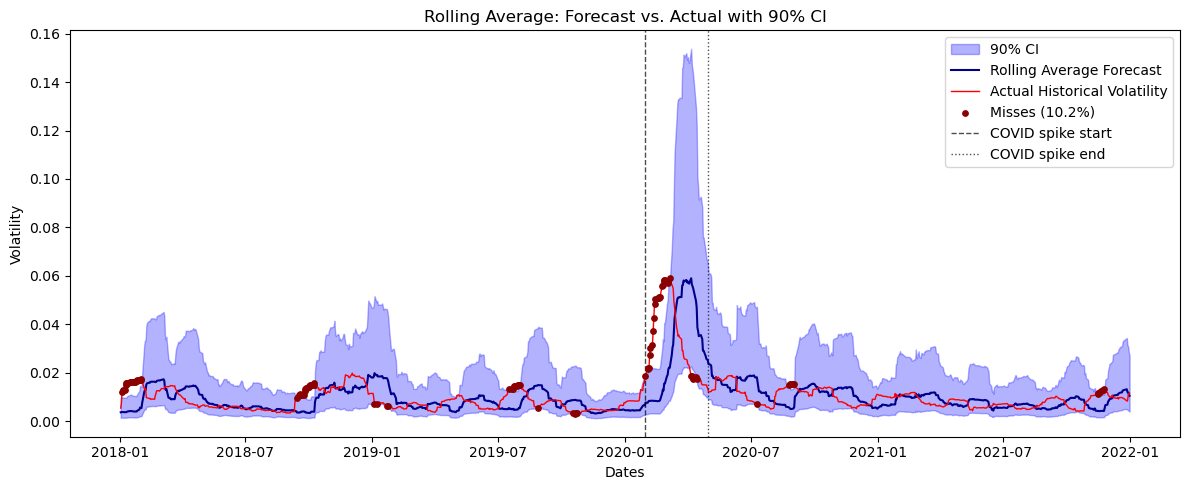

In [ ]:
plot_hv_coverage(
    forecast_regression_rolling, actual_regression_rolling, dates_regression_rolling,
    lower_90_regression_rolling, upper_90_regression_rolling, inside_90_regression_rolling,
    covid_start_date=covid_start_date, covid_end_date=covid_end_date,
    label="Rolling Average"
)

This diagram shows that volatility model is miscalibrated in massive clusters. Additionally the confidence intervals seem to be unnecessarily large.

In [19]:
def compute_pit(returns, sigma, dist='normal', df=None):
    '''Compute u_t = F_t(r_t) and run KS test against Uniform(0,1).
    dist: 'normal' or 't' (Student-t, requires df).'''
    if dist == 'normal':
        u = norm.cdf(returns / sigma)
    elif dist == 't':
        u = stats.t.cdf(returns / sigma, df=df)
    else:
        raise ValueError("dist must be 'normal' or 't'")
    ks_stat, p_value = kstest(u, 'uniform')
    return u, ks_stat, p_value


def print_pit_result(ks_stat, p_value, label=""):
    print(f"{label} — KS statistic: {ks_stat:.4f}")
    print(f"{label} — p-value: {p_value:.4f}")
    if p_value < 0.05:
        print(f"{label} — Reject null: model is not well calibrated")
    else:
        print(f"{label} — Fail to reject null: no evidence of miscalibration")


def plot_pit(u, label=""):
    '''Histogram + empirical CDF diagnostic plots for PIT values.'''
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].hist(u, bins=20, density=True, color='steelblue', edgecolor='black', alpha=0.7)
    axes[0].axhline(1.0, color='red', linestyle='--', label='Ideal uniform density')
    axes[0].set_title(f"Histogram of PIT values (u_t) — {label}")
    axes[0].set_xlabel("u_t")
    axes[0].set_ylabel("Density")
    axes[0].legend()

    sorted_u = np.sort(u)
    empirical_cdf = np.arange(1, len(sorted_u)+1) / len(sorted_u)
    axes[1].plot(sorted_u, empirical_cdf, color='steelblue', label='Empirical CDF of $u_t$')
    axes[1].plot([0, 1], [0, 1], color='red', linestyle='--', label='Uniform(0,1) CDF')
    axes[1].set_title(f"PIT: Empirical CDF vs. Uniform — {label}")
    axes[1].set_xlabel("u_t")
    axes[1].set_ylabel("Cumulative probability")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

Rolling Average — KS statistic: 0.0824
Rolling Average — p-value: 0.0000
Rolling Average — Reject null: model is not well calibrated


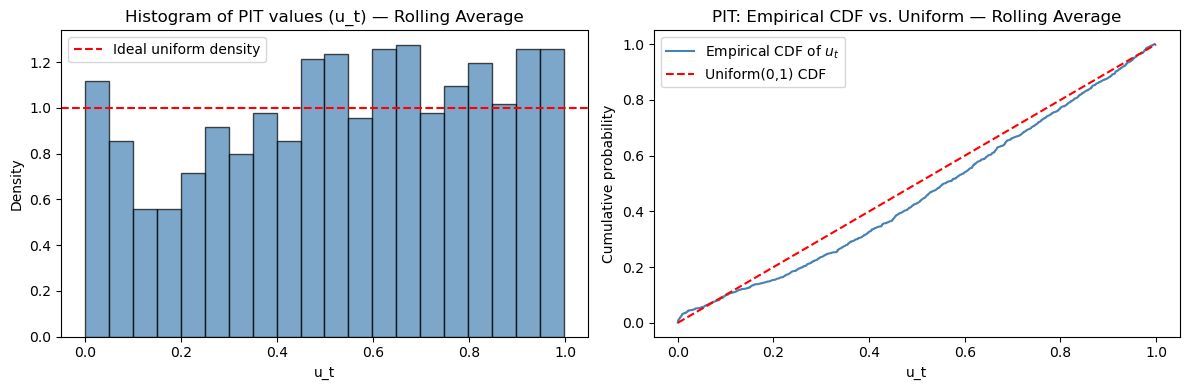

In [ ]:
forecast_regression_rolling_pit, returns_regression_rolling, dates_regression_rolling_pit = align_series(
    rolling_regression, regression_returns
)

u_t_regression_rolling, ks_stat_regression_rolling, p_value_regression_rolling = compute_pit(
    returns_regression_rolling, forecast_regression_rolling_pit, dist='normal'
)

print_pit_result(ks_stat_regression_rolling, p_value_regression_rolling, label="Rolling Average")
plot_pit(u_t_regression_rolling, label="Rolling Average")

The model is not well-calibrated for volatility.

In [17]:
def compute_z(u, dates):
    '''Transform u_t to z_t = Phi^{-1}(u_t) as a date-indexed Series, dropping non-finite values.'''
    z_raw = pd.Series(norm.ppf(u), index=dates)
    return z_raw[np.isfinite(z_raw)]


def ljung_box_tests(z, lags=[1, 5, 10]):
    '''Run Ljung-Box on z_t (level) and z_t^2 (squared).'''
    lb_level = acorr_ljungbox(z, lags=lags, return_df=True)
    lb_sq    = acorr_ljungbox(z**2, lags=lags, return_df=True)
    return lb_level, lb_sq


def print_ljung_box(lb_level, lb_sq, label=""):
    print(f"Ljung-Box test on z_t (level) — {label}:")
    print(lb_level)
    print(f"\nLjung-Box test on z_t^2 (squared, ARCH-LM style) — {label}:")
    print(lb_sq)


def plot_acf_diagnostics(z, lags=20, label=""):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    plot_acf(z, lags=lags, ax=axes[0])
    axes[0].set_title(f"ACF of $z_t$ (level) — {label}")
    plot_acf(z**2, lags=lags, ax=axes[1])
    axes[1].set_title(f"ACF of $z_t^2$ (squared) — {label}")
    plt.tight_layout()
    plt.show()


def sign_bias_test(z, returns, dates):
    '''Engle-Ng sign-bias test: regress z_t^2 on sign(r_{t-1}), aligned strictly by date.'''
    returns_series = pd.Series(returns, index=dates)
    z_sq = z**2
    sign_lag = np.sign(returns_series).shift(1)

    aligned = pd.concat([z_sq, sign_lag], axis=1, join='inner').dropna()
    aligned.columns = ['z_sq', 'sign_lag']

    X = sm.add_constant(aligned['sign_lag'])
    model = sm.OLS(aligned['z_sq'], X).fit(cov_type='HC3')
    return model


def print_sign_bias(model, label=""):
    print(f"Engle-Ng Sign-Bias Test — {label}:")
    print(model.summary())

Ljung-Box test on z_t (level) — Rolling Average:
      lb_stat  lb_pvalue
1    0.509386   0.475405
5    1.277851   0.937194
10  12.527067   0.251328

Ljung-Box test on z_t^2 (squared, ARCH-LM style) — Rolling Average:
      lb_stat     lb_pvalue
1   26.020724  3.377720e-07
5   87.482981  2.268936e-17
10  99.660379  6.372849e-17


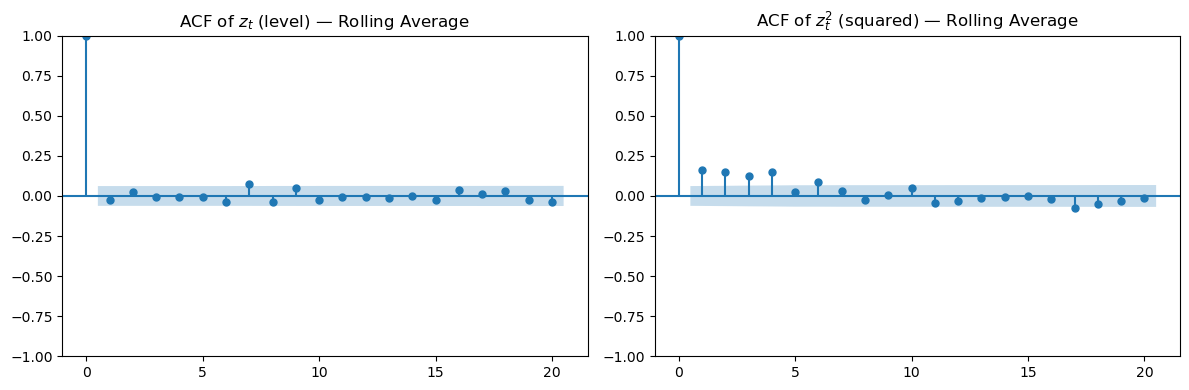

Engle-Ng Sign-Bias Test — Rolling Average:
                            OLS Regression Results                            
Dep. Variable:                   z_sq   R-squared:                       0.022
Model:                            OLS   Adj. R-squared:                  0.021
Method:                 Least Squares   F-statistic:                     19.76
Date:                Wed, 29 Jul 2026   Prob (F-statistic):           9.78e-06
Time:                        13:53:36   Log-Likelihood:                -1982.0
No. Observations:                1007   AIC:                             3968.
Df Residuals:                    1005   BIC:                             3978.
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const    

In [ ]:
z_t_regression_rolling = compute_z(u_t_regression_rolling, dates_regression_rolling_pit)

lb_level_regression_rolling, lb_sq_regression_rolling = ljung_box_tests(z_t_regression_rolling)
print_ljung_box(lb_level_regression_rolling, lb_sq_regression_rolling, label="Rolling Average")
plot_acf_diagnostics(z_t_regression_rolling, label="Rolling Average")

sign_bias_model_regression_rolling = sign_bias_test(z_t_regression_rolling, returns_regression_rolling, dates_regression_rolling_pit)
print_sign_bias(sign_bias_model_regression_rolling, label="Rolling Average")

Test 1 (level): p-values well above 0.05 at all lags → fail to reject the null of no autocorrelation. No evidence that calibration errors have directional persistence (errors don't systematically run in one direction from day to day).

Test 2 (squared): p-values far below 0.05 at all lags → reject the null of no autocorrelation. Strong evidence of leftover volatility clustering — the model's errors bunch up in time, consistent with the rolling average failing to adapt quickly enough to genuine regime shifts.

Test 3 (sign bias): coefficient on sign(r_{t-1}) is significant (p<0.001, coefficient=-0.26) → reject the null of no sign-dependence. Calibration errors are meaningfully larger following negative returns than positive ones, indicating the rolling average fails to capture the leverage effect.

Therefore, the baseline model didn't work well for volatility modelling on the regression. 
Therefore, the baseline model shouldn't work on sequential but this should still be checked to understand the differences in the data between sequential and regression periods 

## Sequential Rolling

For sequential need the windows, need timestamps for the 8 regions each in 8 6 month periods from 2022 to 2025

Then for plotting hv coverage, need a new function for sequential with the window lines similar to the COVID lines (everything else unchanged)

Additionally QLIKe by window. 
Maybe also the Return Coverage at 90% for that period, (replacing the COVID breakdown)

In [32]:
# ── Window boundaries ────────────────────────────────────────────
window_boundaries = pd.date_range(start="2022-01-01", end="2026-01-01", freq="6MS")

def window_indices(dates, window_boundaries):
    '''Return list of (start_idx, end_idx) pairs for each window.'''
    return [(np.searchsorted(dates, window_boundaries[i]), np.searchsorted(dates, window_boundaries[i+1]))
            for i in range(len(window_boundaries) - 1)]

In [33]:
def qlike_by_window(forecast, actual, dates, window_boundaries):
    '''Mean QLIKE within each window.'''
    results = {}
    for i, (start_idx, end_idx) in enumerate(window_indices(dates, window_boundaries)):
        window_qlike = qlike(forecast[start_idx:end_idx], actual[start_idx:end_idx]).mean()
        results[f"window_{i+1}"] = {
            'start': window_boundaries[i], 'end': window_boundaries[i+1], 'qlike': window_qlike
        }
    return results

def print_qlike_by_window(results, label=""):
    print(f"QLIKE by window — {label}:")
    for name, r in results.items():
        print(f"  {name} ({r['start'].date()} to {r['end'].date()}): {r['qlike']:.4f}")


In [34]:
qlike_windows_rolling = qlike_by_window(forecast_sequential_rolling, actual_sequential_rolling, dates_sequential_rolling, window_boundaries)
print_qlike_by_window(qlike_windows_rolling, label="Rolling Average")

QLIKE by window — Rolling Average:
  window_1 (2022-01-01 to 2022-07-01): 0.2578
  window_2 (2022-07-01 to 2023-01-01): 0.1093
  window_3 (2023-01-01 to 2023-07-01): 0.0842
  window_4 (2023-07-01 to 2024-01-01): 0.1296
  window_5 (2024-01-01 to 2024-07-01): 0.1702
  window_6 (2024-07-01 to 2025-01-01): 0.9491
  window_7 (2025-01-01 to 2025-07-01): 1.0283
  window_8 (2025-07-01 to 2026-01-01): 0.4464


In [35]:
def sigma_eta_sequential(forecast, actual, forecast_regression, actual_regression, dates, window_boundaries):
    '''Expanding sigma_eta: starts with regression residuals, accumulates each completed sequential window.'''
    all_log_resid = list(np.log(actual_regression) - np.log(forecast_regression))
    log_resid_sequential = np.log(actual) - np.log(forecast)

    sigma_eta_by_window = {}
    for i, (start_idx, end_idx) in enumerate(window_indices(dates, window_boundaries)):
        sigma_eta_by_window[f"window_{i+1}"] = np.std(all_log_resid)
        all_log_resid.extend(log_resid_sequential[start_idx:end_idx])

    return sigma_eta_by_window

In [36]:
sigma_eta_windows_rolling = sigma_eta_sequential(
    forecast_sequential_rolling, actual_sequential_rolling,
    forecast_regression_rolling, actual_regression_rolling,
    dates_sequential_rolling, window_boundaries
)

In [37]:
def hv_coverage_sequential(forecast, actual, dates, window_boundaries, sigma_eta_by_window, level=90):
    '''RV coverage using a different (expanding) sigma_eta per window.'''
    z = norm.ppf(1 - (100 - level) / 200)
    lower = np.zeros_like(forecast)
    upper = np.zeros_like(forecast)

    for i, (start_idx, end_idx) in enumerate(window_indices(dates, window_boundaries)):
        sigma_eta_i = sigma_eta_by_window[f"window_{i+1}"]
        lower[start_idx:end_idx] = forecast[start_idx:end_idx] * np.exp(-z * sigma_eta_i)
        upper[start_idx:end_idx] = forecast[start_idx:end_idx] * np.exp(+z * sigma_eta_i)

    inside = (actual >= lower) & (actual <= upper)
    return lower, upper, inside

def coverage_by_window(inside, dates, window_boundaries):
    '''% inside CI within each window, given a precomputed inside-mask.'''
    results = {}
    for i, (start_idx, end_idx) in enumerate(window_indices(dates, window_boundaries)):
        results[f"window_{i+1}"] = {
            'start': window_boundaries[i], 'end': window_boundaries[i+1],
            'coverage': np.mean(inside[start_idx:end_idx])
        }
    return results

def print_coverage_by_window(results, label="", level=90):
    print(f"{level}% CI Coverage by window — {label}:")
    for name, r in results.items():
        print(f"  {name} ({r['start'].date()} to {r['end'].date()}): {r['coverage']:.2%}")

In [38]:
lower_seq_rolling, upper_seq_rolling, inside_seq_rolling = hv_coverage_sequential(
    forecast_sequential_rolling, actual_sequential_rolling, dates_sequential_rolling,
    window_boundaries, sigma_eta_windows_rolling, level=90
)
coverage_windows_rolling = coverage_by_window(inside_seq_rolling, dates_sequential_rolling, window_boundaries)
print_coverage_by_window(coverage_windows_rolling, label="Rolling Average", level=90)

90% CI Coverage by window — Rolling Average:
  window_1 (2022-01-01 to 2022-07-01): 100.00%
  window_2 (2022-07-01 to 2023-01-01): 100.00%
  window_3 (2023-01-01 to 2023-07-01): 100.00%
  window_4 (2023-07-01 to 2024-01-01): 98.41%
  window_5 (2024-01-01 to 2024-07-01): 100.00%
  window_6 (2024-07-01 to 2025-01-01): 86.72%
  window_7 (2025-01-01 to 2025-07-01): 69.67%
  window_8 (2025-07-01 to 2026-01-01): 94.34%


In [39]:
def plot_hv_coverage_windows(forecast, actual, dates, lower, upper, inside, window_boundaries, label="Model"):
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.fill_between(dates, lower, upper, alpha=0.3, color='blue', label='90% CI')
    ax.plot(dates, forecast, color='darkblue', lw=1.5, label=f'{label} Forecast')
    ax.plot(dates, actual, color='red', lw=1, label='Actual Historical Volatility')

    miss_idx = np.where(~inside)[0]
    miss_pct = (1 - np.mean(inside)) * 100
    ax.scatter(dates[miss_idx], actual[miss_idx], color='darkred', s=15, zorder=5,
               label=f'Misses ({miss_pct:.1f}%)')

    for i, boundary in enumerate(window_boundaries):
        if dates[0] <= boundary <= dates[-1]:
            ax.axvline(boundary, color='black', linestyle='--', alpha=0.5, lw=1,
                       label='Window boundary' if i == 0 else None)

    ax.set_title(f"{label}: Forecast vs. Actual with 90% CI (Sequential Windows)")
    ax.set_xlabel("Dates")
    ax.set_ylabel("Volatility")
    ax.legend()
    plt.tight_layout()
    plt.show()

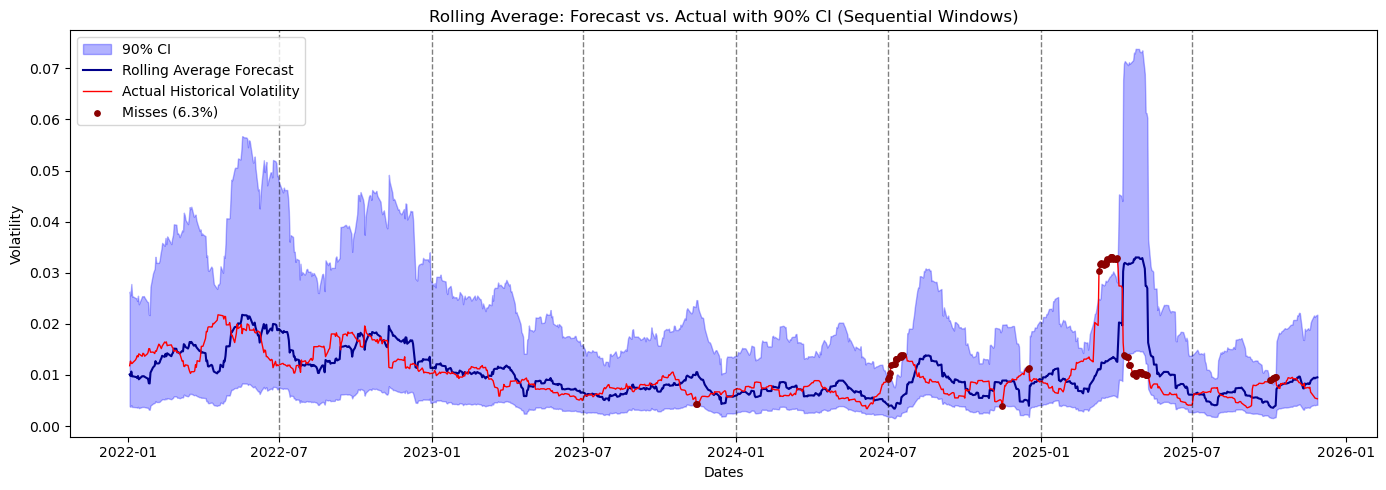

In [40]:
plot_hv_coverage_windows(forecast_sequential_rolling, actual_sequential_rolling, dates_sequential_rolling,
                          lower_seq_rolling, upper_seq_rolling, inside_seq_rolling, window_boundaries,
                          label="Rolling Average")

PIT 

Rolling Average (Sequential) — KS statistic: 0.0602
Rolling Average (Sequential) — p-value: 0.0013
Rolling Average (Sequential) — Reject null: model is not well calibrated


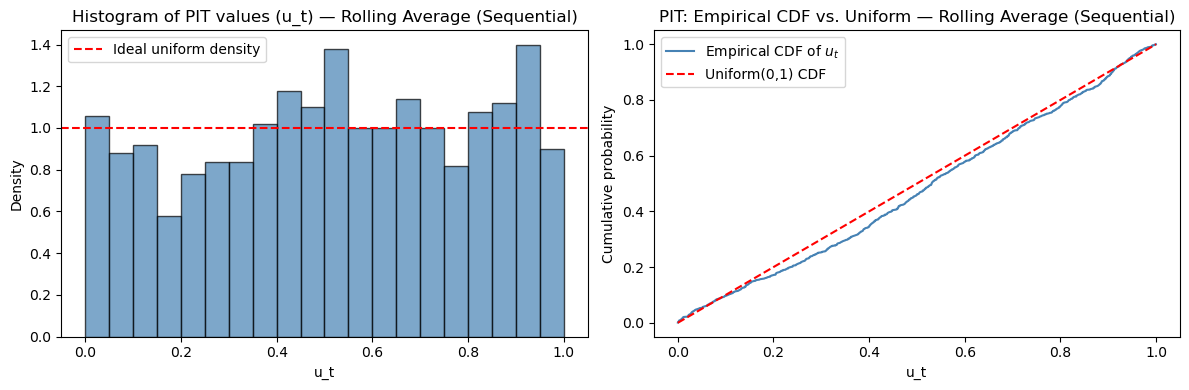

In [41]:
forecast_sequential_rolling_pit, returns_sequential_rolling, dates_sequential_rolling_pit = align_series(
    rolling_sequential, sequential_returns
)
u_t_sequential_rolling, ks_stat_sequential_rolling, p_value_sequential_rolling = compute_pit(
    returns_sequential_rolling, forecast_sequential_rolling_pit, dist='normal'
)
print_pit_result(ks_stat_sequential_rolling, p_value_sequential_rolling, label="Rolling Average (Sequential)")
plot_pit(u_t_sequential_rolling, label="Rolling Average (Sequential)")

Serial Dependence

Ljung-Box test on z_t (level) — Rolling Average (Sequential):
     lb_stat  lb_pvalue
1   0.012920   0.909502
5   1.079259   0.955923
10  1.736199   0.997991

Ljung-Box test on z_t^2 (squared, ARCH-LM style) — Rolling Average (Sequential):
      lb_stat  lb_pvalue
1    1.534656   0.215415
5   13.257883   0.021078
10  17.049091   0.073285


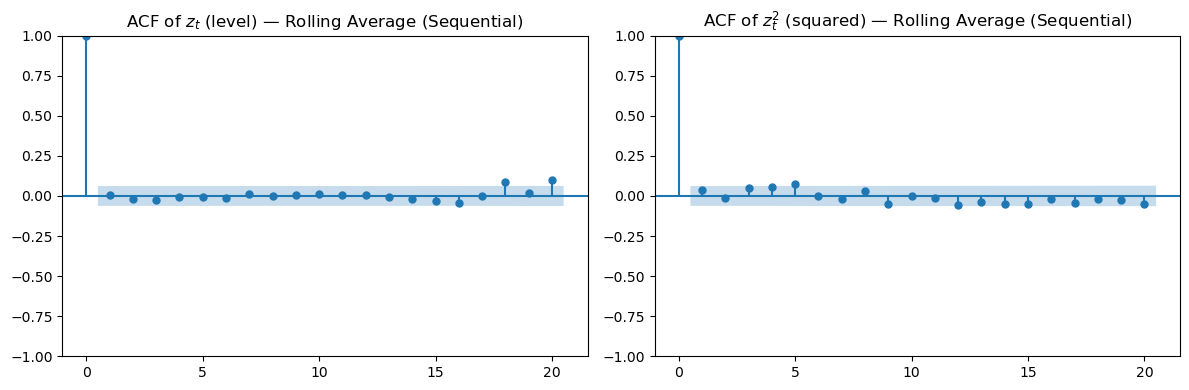

Engle-Ng Sign-Bias Test — Rolling Average (Sequential):
                            OLS Regression Results                            
Dep. Variable:                   z_sq   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     7.738
Date:                Wed, 29 Jul 2026   Prob (F-statistic):            0.00551
Time:                        23:51:29   Log-Likelihood:                -1844.5
No. Observations:                1001   AIC:                             3693.
Df Residuals:                     999   BIC:                             3703.
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------

In [42]:
z_t_sequential_rolling = compute_z(u_t_sequential_rolling, dates_sequential_rolling_pit)
lb_level_seq_rolling, lb_sq_seq_rolling = ljung_box_tests(z_t_sequential_rolling)
print_ljung_box(lb_level_seq_rolling, lb_sq_seq_rolling, label="Rolling Average (Sequential)")
plot_acf_diagnostics(z_t_sequential_rolling, label="Rolling Average (Sequential)")

sign_bias_model_seq_rolling = sign_bias_test(z_t_sequential_rolling, returns_sequential_rolling, dates_sequential_rolling_pit)
print_sign_bias(sign_bias_model_seq_rolling, label="Rolling Average (Sequential)")

## Model 2- Time Series

### Model Selection

Note that all the model selection code should be done using the prior returns. 

In order to select the models, AIC and BIC are used where these are given by:

AIC = -2loglikelihood+2k
BIC = -2loglikelihood + kln(n)

In [46]:
import pandas as pd
import numpy as np
from scipy import stats
from arch import arch_model
# GARCH
garch_mle = arch_model(prior_returns * 100, vol="Garch", p=1, q=1,mean="Constant",dist="t")
result_garch = garch_mle.fit(disp="off")


#GJR GARCH
# EGARCH
egarch_mle = arch_model(prior_returns * 100, vol="EGARCH", p=1, o=1, q=1,mean="Constant",dist="t")
result_egarch = egarch_mle.fit(disp="off")
gjr_garch_mle = arch_model(prior_returns*100, vol='Garch',p=1,o=1,q=1,mean="Constant",dist="t")
result_gjr_garch = gjr_garch_mle.fit(disp='off')

garch_2_1_mle = arch_model(prior_returns * 100,vol="Garch", p=2, q=1,mean="Constant",dist="t")
result_garch_2_1 = garch_2_1_mle.fit(disp="off")

garch_1_2_mle = arch_model(prior_returns*100, vol="Garch", p=1, q=2, mean="Constant", dist="t")
result_garch_1_2 = garch_1_2_mle.fit(disp="off")



From the table below, EGARCH-t has minimal AIC and BIC so it is the best time series model for this task.

In [47]:
import pandas as pd

model_selection = pd.DataFrame({
    "Model": ["GARCH(1,1)-t", "EGARCH(1,1)-t", "GJR-GARCH(1,1)-t", "GARCH(2,1)-t","GARCH(1,2)-t"],
    "AIC":   [result_garch.aic, result_egarch.aic, result_gjr_garch.aic, result_garch_2_1.aic, result_garch_1_2.aic],
    "BIC":   [result_garch.bic, result_egarch.bic, result_gjr_garch.bic, result_garch_2_1.bic, result_garch_1_2.bic],
    "Log-Likelihood": [result_garch.loglikelihood, result_egarch.loglikelihood, result_gjr_garch.loglikelihood, result_garch_2_1.loglikelihood, result_garch_1_2.loglikelihood]
})

model_selection = model_selection.set_index("Model")
print(model_selection.round(2))

                      AIC      BIC  Log-Likelihood
Model                                             
GARCH(1,1)-t      2492.98  2518.66        -1241.49
EGARCH(1,1)-t     2422.57  2453.40        -1205.29
GJR-GARCH(1,1)-t  2443.80  2474.62        -1215.90
GARCH(2,1)-t      2494.88  2525.70        -1241.44
GARCH(1,2)-t      2494.98  2525.80        -1241.49


### EGARCH

The EGARCH(1,1)-t model is parameterized by:

\begin{align}
r_t &= \mu + \epsilon_t, \quad \epsilon_t = \sigma_t z_t, \quad z_t \overset{\text{i.i.d.}}{\sim} t_\nu(0,1) \\
\ln\sigma_t^2 &= \omega + \alpha\left(|z_{t-1}| - \mathbb{E}|z_{t-1}|\right) + \gamma z_{t-1} + \beta\ln\sigma_{t-1}^2
\end{align}

Its key differentiator over other time series models is its ability to capture the leverage effect (the principle that volatility reacts asymmetrically to equal changes in positive and negative returns) through $\gamma$.

It also captures other key properties of volatility (the t-distribution captures fat-tailedness of returns and $\alpha$ captures the effect of sudden large changes in price).

From the summary below, potential parameters for priors can be determined

In [48]:
print(result_egarch.summary())

                        Constant Mean - EGARCH Model Results                        
Dep. Variable:                          SPY   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                           EGARCH   Log-Likelihood:               -1205.29
Distribution:      Standardized Student's t   AIC:                           2422.57
Method:                  Maximum Likelihood   BIC:                           2453.40
                                              No. Observations:                 1258
Date:                      Fri, Jul 31 2026   Df Residuals:                     1257
Time:                              13:00:48   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu  

In [ ]:


prior_std = prior_returns_1d.std()
print(f"prior_std: {prior_std:.6f}")

prior_std: 0.007444


In [80]:
import scipy.special

# ── Fix: log-space E_abs_z_t to avoid gamma-function overflow ──
def E_abs_z_t(nu):
    """E[|z|] for standardized t with unit variance — log-space to avoid overflow for large nu."""
    log_num = np.log(2) + 0.5*np.log(nu-2) + scipy.special.gammaln((nu+1)/2)
    log_den = 0.5*np.log(np.pi) + np.log(nu-1) + scipy.special.gammaln(nu/2)
    return np.exp(log_num - log_den)

nu_grid = np.linspace(2.1,100, 1000)
e_abs_grid = E_abs_z_t(nu_grid)

def E_abs_z_interp_numpy(nu, nu_grid=nu_grid, e_abs_grid=e_abs_grid):
    '''NumPy equivalent of the JAX E_abs_z_interp used inside egarch_model — safe for any nu.'''
    return np.interp(nu, nu_grid, e_abs_grid)

def simulate_egarch_t_vectorized(omega, alpha, beta, gamma, nu, mu, n, ls2_init=None):
    '''Simulate n days for a batch of S parameter draws (all arrays of length S).
    ls2_init: optional per-draw starting state (array of length S). If None, uses the
    stationary initial condition omega/(1-beta) — used for prior predictive checking.
    If provided (e.g. carried-forward state), used for sequential forecast generation.
    Returns (r, sigma), each of shape (S, n).'''
    S = len(omega)
    log_sigma2 = np.zeros((S, n))
    r = np.zeros((S, n))
    e_abs = E_abs_z_interp_numpy(nu)

    if ls2_init is None:
        log_sigma2[:, 0] = np.clip(omega / (1 - beta), -20, 2)
    else:
        log_sigma2[:, 0] = np.clip(ls2_init, -20, 2)

    for t in range(1, n):
        scale = np.sqrt((nu - 2) / nu)
        z = np.random.standard_t(nu) * scale
        r[:, t] = mu + np.exp(0.5 * log_sigma2[:, t-1]) * z
        log_sigma2[:, t] = np.clip(
            omega + beta * log_sigma2[:, t-1] + gamma * z + alpha * (np.abs(z) - e_abs),
            -20, 2
        )
    return r, np.sqrt(np.exp(log_sigma2))

def sigma_to_hv_correct(sigma_paths, h=21):
    '''Correct order: average sigma^2 ACROSS PATHS first (per timestep), then RMS-aggregate over the window.'''
    mean_sigma_sq_per_t = np.mean(sigma_paths**2, axis=0)   # E[sigma_{t+i}^2] at each t, across paths
    rv = pd.Series(mean_sigma_sq_per_t).rolling(h).mean().shift(-h+1)  # window average, forward-looking
    return np.sqrt(rv).values

def sigma_sq_windowed_per_path(sigma_paths, h=21):
    '''Per-path windowed mean of sigma^2 (no sqrt), for percentile-band purposes.'''
    result = np.zeros((sigma_paths.shape[0], sigma_paths.shape[1]))
    for n_idx in range(sigma_paths.shape[0]):
        result[n_idx] = pd.Series(sigma_paths[n_idx]**2).rolling(h).mean().shift(-h+1).values
    return result


Valid paths: 992/1000 (99%)


c:\Users\Adit\anaconda3\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1650: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


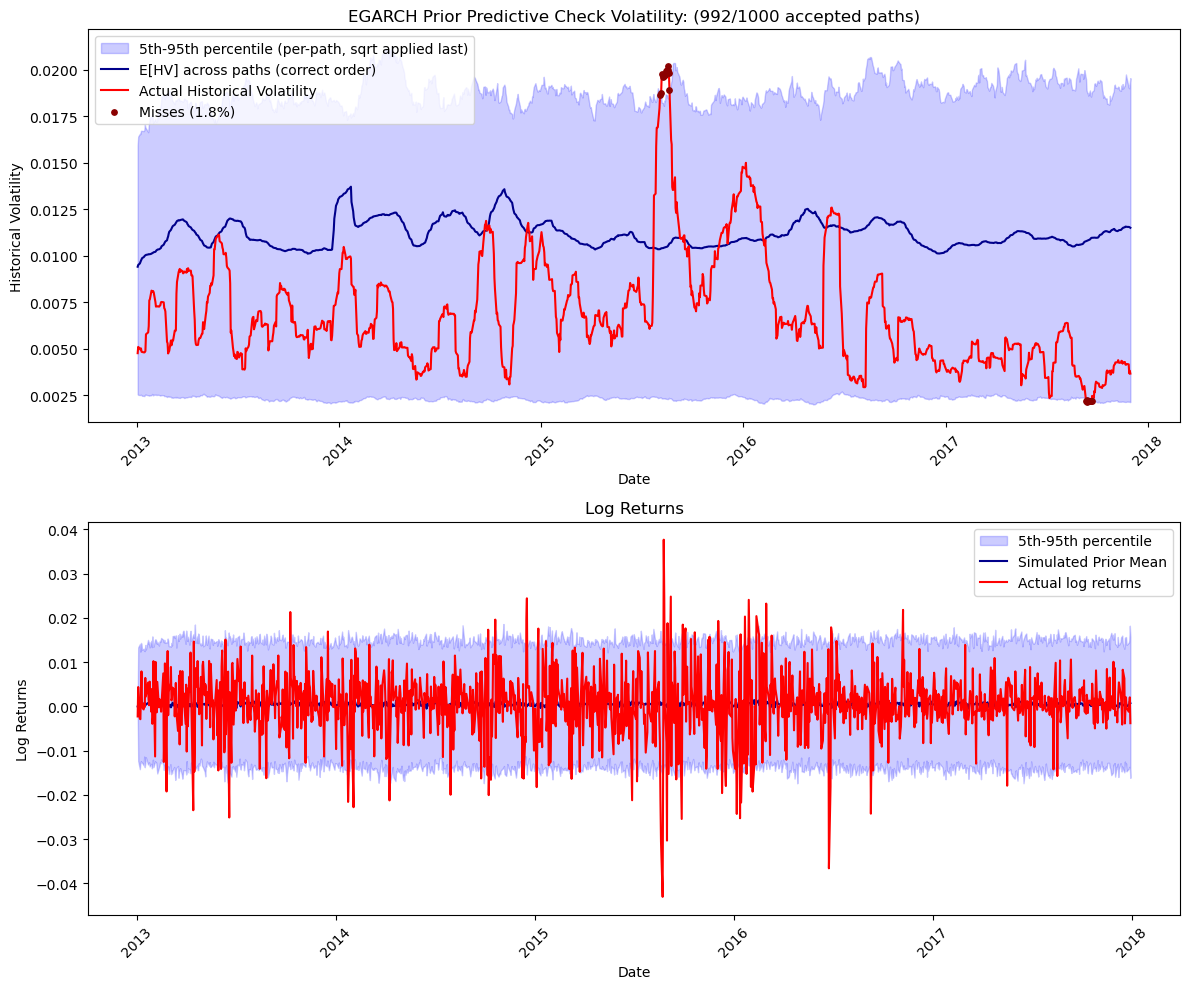

Valid paths: 992/1000 (99%)
Miss rate (visual diagnostic only): 1.8%
Rejection rate indicates prior stationarity constraint tightness


In [60]:
# ── Fitted MLE values (from earlier arch_model fit) ──
omega_egarch = result_egarch.params['omega']
alpha_egarch = result_egarch.params['alpha[1]']  # magnitude
gamma_egarch = result_egarch.params['gamma[1]']  # leverage
beta_egarch  = result_egarch.params['beta[1]']
nu_egarch    = result_egarch.params['nu']
mu_egarch    = result_egarch.params['mu'] / 100  # divide by 100
prior_std    = prior_returns_1d.std()

# ── Prior predictive simulation ──────────────────────────────────
np.random.seed(42)
n_paths = 1000
n = len(prior_returns_1d)

# Sample all parameters up front, vectorized, with rejection applied via masking
alpha_arr = stats.truncnorm.rvs((0 - alpha_egarch) / 0.05, np.inf, loc=alpha_egarch, scale=0.05, size=n_paths)
beta_arr  = np.random.beta(47, 3, size=n_paths)
gamma_arr = np.random.normal(gamma_egarch, 0.05, size=n_paths)
mu_arr    = np.random.normal(mu_egarch, 0.001, size=n_paths)
nu_arr    = 2.1 + np.random.gamma(shape=(nu_egarch - 2.1) / 2, scale=2, size=n_paths)
uncond_vol_arr = stats.truncnorm.rvs((0 - prior_std) / 0.003, (0.02 - prior_std) / 0.003,
                                      loc=prior_std, scale=0.003, size=n_paths)
omega_arr = np.log(uncond_vol_arr**2) * (1 - beta_arr)

# Filter: finite E_abs_z_t, stationary beta
valid_mask = np.array([np.isfinite(E_abs_z_t(nu_i)) for nu_i in nu_arr]) & (np.abs(beta_arr) < 1)

alpha_v, beta_v, gamma_v, mu_v, nu_v, omega_v = (
    alpha_arr[valid_mask], beta_arr[valid_mask], gamma_arr[valid_mask],
    mu_arr[valid_mask], nu_arr[valid_mask], omega_arr[valid_mask]
)

ret_paths, vol_paths = simulate_egarch_t_vectorized(omega_v, alpha_v, beta_v, gamma_v, nu_v, mu_v, n)

# Reject explosive paths (post-hoc, same criterion as before)
explosive_mask = np.any(np.isnan(ret_paths), axis=1) | np.any(np.isinf(ret_paths), axis=1) | (np.max(np.abs(ret_paths), axis=1) > 0.5)
vol_paths = vol_paths[~explosive_mask]
ret_paths = ret_paths[~explosive_mask]

valid_paths = vol_paths.shape[0]
print(f"Valid paths: {valid_paths}/{n_paths} ({valid_paths/n_paths*100:.0f}%)")

# ── Correct aggregation: average across paths BEFORE sqrt/window ──
mean_correct = sigma_to_hv_correct(vol_paths, h=21)  # single series, not per-path anymore

# For a plausibility band, still need per-path spread — but computed correctly:
# aggregate each path's sigma^2 into window sums first (no sqrt yet), THEN take percentiles, THEN sqrt
sigma_sq_windowed = sigma_sq_windowed_per_path(vol_paths, h=21)
lower = np.sqrt(np.nanpercentile(sigma_sq_windowed, 5, axis=0))
upper = np.sqrt(np.nanpercentile(sigma_sq_windowed, 95, axis=0))

# ── Build as date-indexed Series, drop NaN (both ends) ──
mean_correct_series = pd.Series(mean_correct, index=prior_dates[:len(mean_correct)]).dropna()
lower_series = pd.Series(lower, index=prior_dates[:len(lower)]).dropna()
upper_series = pd.Series(upper, index=prior_dates[:len(upper)]).dropna()

# ── Align against the empirical benchmark (hv_prior, already built in the baseline pipeline) ──
forecast_prior_egarch, actual_prior_egarch, dates_prior_egarch = align_series(
    mean_correct_series, hv_prior
)
lower_aligned = lower_series.reindex(dates_prior_egarch).values
upper_aligned = upper_series.reindex(dates_prior_egarch).values

# ── Misses / informal coverage (visual diagnostic, not a formal test) ──
inside_prior = (actual_prior_egarch >= lower_aligned) & (actual_prior_egarch <= upper_aligned)
miss_pct_prior = (1 - np.mean(inside_prior)) * 100

# ── Plot ──
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# use dates_prior_egarch instead of raw prior_vol_rv_dates
axes[0].fill_between(dates_prior_egarch, lower_aligned, upper_aligned,
                     alpha=0.2, color="blue",
                     label="5th-95th percentile (per-path, sqrt applied last)")
axes[0].plot(dates_prior_egarch, forecast_prior_egarch, color="darkblue",
             linewidth=1.5, label="E[HV] across paths (correct order)")
axes[0].plot(dates_prior_egarch, actual_prior_egarch, color="red",
             linewidth=1.5, label="Actual Historical Volatility")

miss_idx = np.where(~inside_prior)[0]
axes[0].scatter(dates_prior_egarch[miss_idx], actual_prior_egarch[miss_idx],
                color='darkred', s=15, zorder=5, label=f'Misses ({miss_pct_prior:.1f}%)')

axes[0].set_title(f"EGARCH Prior Predictive Check Volatility: ({valid_paths}/{n_paths} accepted paths)")
axes[0].set_ylabel("Historical Volatility")
axes[0].set_xlabel("Date")
axes[0].legend()

# Returns panel — no aggregation needed at the daily/return level
ret_lower = np.percentile(ret_paths, 5, axis=0)
ret_upper = np.percentile(ret_paths, 95, axis=0)
ret_mean  = np.mean(ret_paths, axis=0)

axes[1].fill_between(prior_dates, ret_lower, ret_upper,
                     alpha=0.2, color="blue", label="5th-95th percentile")
axes[1].plot(prior_dates, ret_mean, color="darkblue",
             linewidth=1.5, label="Simulated Prior Mean")
axes[1].plot(prior_dates, prior_returns_1d, color="red",
             linewidth=1.5, label="Actual log returns")

axes[1].set_title("Log Returns")
axes[1].set_ylabel("Log Returns")
axes[1].set_xlabel("Date")
axes[1].legend()

plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45)
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.savefig("egarch_prior_predictive.pdf", bbox_inches='tight')
plt.show()

print(f"Valid paths: {valid_paths}/{n_paths} ({valid_paths/n_paths*100:.0f}%)")
print(f"Miss rate (visual diagnostic only): {miss_pct_prior:.1f}%")
print("Rejection rate indicates prior stationarity constraint tightness")

In [57]:
print(mean_correct_series.index.min(), mean_correct_series.index.max())
print(hv_prior.index.min(), hv_prior.index.max())
print(dates_prior_egarch.min(), dates_prior_egarch.max())
print(len(dates_prior_egarch))

2013-01-03 00:00:00 2017-11-30 00:00:00
2013-01-03 00:00:00 2017-12-29 00:00:00
2013-01-03 00:00:00 2017-11-30 00:00:00
1238


The plots above are sufficiently good, (even though the confidence intervals don't actually map much onto the actual rolling std, it covers it which is enough for the MCMC)

### Implementation

Use Numpyro for implementation of the MCMC method

In [22]:
pip install numpyro jax

Note: you may need to restart the kernel to use updated packages.


### Regression Code

In [64]:
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS
import jax
jax.config.update("jax_enable_x64", True)  # MUST be before any JAX operations
import jax.numpy as jnp
import numpyro
numpyro.set_host_device_count(4)
returns_jax = jnp.array(regression_returns_1d)  
def egarch_model(returns):
    mu_ret     = numpyro.sample("mu_ret",     dist.Normal(mu_egarch, 0.001))
    alpha      = numpyro.sample("alpha",      dist.TruncatedNormal(alpha_egarch, 0.05, low=0))
    beta       = numpyro.sample("beta",       dist.Beta(47, 3))
    gamma      = numpyro.sample("gamma",      dist.Normal(gamma_egarch, 0.05))
    nu_shift   = numpyro.sample("nu_shift",   dist.Gamma((nu_egarch-2.1)/2, 0.5))
    nu         = nu_shift + 2.1
    uncond_vol = numpyro.sample("uncond_vol", dist.TruncatedNormal(
                                    prior_std, 0.003, low=0, high=0.02))
    omega      = jnp.log(uncond_vol**2) * (1 - beta_egarch)  # jnp + fixed beta (can't use beta as otherwise divergences occurs)

    e_abs_grid_t = jnp.array(e_abs_grid)
    def E_abs_z_interp(nu):
        idx      = (nu - 2.1) / (100 - 2.1) * 999
        idx_low  = jnp.clip(jnp.floor(idx).astype(int), 0, 998)
        idx_high = jnp.clip(idx_low + 1, 0, 999)
        frac     = idx - jnp.floor(idx)
        return e_abs_grid_t[idx_low] * (1-frac) + e_abs_grid_t[idx_high] * frac

    e_abs = E_abs_z_interp(nu)

    def egarch_step(ls2, r):
        z       = (r - mu_ret) / jnp.sqrt(jnp.exp(jnp.clip(ls2, -20.0, 2.0)))
        ls2_new = omega + beta*ls2 + gamma*z + alpha*(jnp.abs(z) - e_abs)
        return jnp.clip(ls2_new, -20.0, 2.0), ls2_new
        
    ls2_init = jnp.log(uncond_vol**2) 
    
    _, log_sigma2 = jax.lax.scan(egarch_step, ls2_init, returns[:-1])
    # log_sigma2 shape: (T-1,) — σ_1...σ_{T-1}
    
    # Prepend σ_0
    log_sigma2_full = jnp.concatenate([ls2_init.reshape(1), log_sigma2])
    # log_sigma2_full shape: (T,) — σ_0...σ_{T-1}

    sigma = jnp.sqrt(jnp.exp(log_sigma2_full))
    scale = jnp.clip(sigma * jnp.sqrt((nu-2)/nu), 1e-6, 10)
    
    # Now use full returns — all T observations
    numpyro.sample("obs", dist.StudentT(nu, mu_ret, scale), obs=returns) #not returns[1:]
    numpyro.deterministic("sigma", sigma)
# Run MCMC
nuts_kernel = NUTS(egarch_model, target_accept_prob=0.95)
mcmc_egarch= MCMC(nuts_kernel,
            num_warmup=2000,
            num_samples=2000,
            num_chains=4,
            chain_method='parallel')
mcmc_egarch.run(jax.random.PRNGKey(42), returns_jax)
mcmc_egarch.print_summary()

  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]


                  mean       std    median      5.0%     95.0%     n_eff     r_hat
       alpha      0.25      0.03      0.25      0.19      0.29   5722.30      1.00
        beta      0.94      0.00      0.94      0.93      0.95   3850.00      1.00
       gamma     -0.23      0.02     -0.23     -0.26     -0.19   5443.11      1.00
      mu_ret      0.00      0.00      0.00      0.00      0.00   8400.68      1.00
    nu_shift      3.91      0.97      3.80      2.36      5.43   5424.47      1.00
  uncond_vol      0.01      0.00      0.01      0.01      0.01   3795.81      1.00

Number of divergences: 0


Save data

In [65]:
import pickle
from pathlib import Path

Path("results/egarch").mkdir(parents=True, exist_ok=True)

samples_egarch = mcmc_egarch.get_samples()   # your existing line

with open("results/egarch/egarch_regression_mcmc.pkl", "wb") as f:
    pickle.dump({k: np.array(v) for k, v in samples_egarch.items()}, f)

print("Saved regression MCMC samples.")

Saved regression MCMC samples.


In [66]:
with open("results/egarch/egarch_regression_mcmc.pkl", "rb") as f:
    samples_egarch = pickle.load(f)

In [67]:
# ── Load/confirm the saved posterior samples ──
# samples_egarch = pickle.load(...) if reloading, or mcmc_egarch.get_samples() if freshly run
sigma_posterior_egarch = np.array(mcmc_egarch.get_samples()["sigma"])   # shape (S, T)
nu_all = np.array(mcmc_egarch.get_samples()["nu_shift"]) + 2.1          # nu_all defined here

In [100]:
def hv_per_draw_windowed(sigma_posterior, h=21):
    '''Per-draw windowed HV (sqrt applied), shape (S, T) — same as sigma_sq_windowed_per_path but with sqrt.'''
    return np.sqrt(sigma_sq_windowed_per_path(sigma_posterior, h=h))

def hv_coverage_posterior(hv_per_draw, actual, sigma_eta, level=90):
    '''Combined posterior-spread + log-normal noise interval, via simulation (Order A).'''
    S, T = hv_per_draw.shape
    noise = np.random.normal(0, sigma_eta, size=(S, T))
    noisy_hv = hv_per_draw * np.exp(noise)

    pct = (100 - level) / 2
    lower = np.percentile(noisy_hv, pct, axis=0)
    upper = np.percentile(noisy_hv, 100 - pct, axis=0)
    inside = (actual >= lower) & (actual <= upper)
    return lower, upper, inside

In [101]:
# ── QLIKE / RV Coverage: unchanged, Method 2 (posterior-averaged mean) ──
forecast_regression_egarch_series = pd.Series(
    sigma_to_hv_correct(sigma_posterior_egarch, h=21),
    index=regression_returns.index
).dropna()

forecast_regression_egarch, actual_regression_egarch, dates_regression_egarch = align_series(
    forecast_regression_egarch_series, hv_regression
)

ql_regression_egarch = qlike(forecast_regression_egarch, actual_regression_egarch)
print(f"QLIKE (EGARCH regression): mean = {ql_regression_egarch.mean():.4f}")

# ── RV Coverage: combined posterior spread + log-normal noise (Order A) ──
sigma_eta_egarch, _ = hv_coverage(forecast_regression_egarch, actual_regression_egarch)  # keep, just for sigma_eta

# Build per-draw windowed HV over the SAME dates as forecast_regression_egarch (i.e. aligned against hv_regression)
hv_per_draw_regression_egarch = hv_per_draw_windowed(sigma_posterior_egarch, h=21)  # shape (S, T_full)

# Align to match dates_regression_egarch (same dates as forecast_regression_egarch/actual_regression_egarch)
hv_per_draw_regression_egarch_df = pd.DataFrame(
    hv_per_draw_regression_egarch.T, index=regression_returns.index
).loc[dates_regression_egarch]
hv_per_draw_regression_egarch_aligned = hv_per_draw_regression_egarch_df.values.T  # (S, T_aligned)

lower_90_egarch, upper_90_egarch, inside_90_egarch = hv_coverage_posterior(
    hv_per_draw_regression_egarch_aligned, actual_regression_egarch, sigma_eta_egarch, level=90
)

coverage_90_egarch = np.mean(inside_90_egarch)
print(f"EGARCH — 90% CI coverage (posterior + noise): {coverage_90_egarch:.2%}")

QLIKE (EGARCH regression): mean = 0.0993
EGARCH — 90% CI coverage (posterior + noise): 85.73%


In [108]:
def hv_coverage_posterior_multilevel(hv_per_draw, actual, sigma_eta, levels=[50, 60, 70, 80, 85, 90, 95, 99]):
    '''Combined posterior-spread + log-normal noise coverage, at multiple CI levels — one shared noise draw.'''
    S, T = hv_per_draw.shape
    noise = np.random.normal(0, sigma_eta, size=(S, T))   # simulated once, reused for all levels
    noisy_hv = hv_per_draw * np.exp(noise)

    results = {}
    for level in levels:
        pct = (100 - level) / 2
        lower = np.percentile(noisy_hv, pct, axis=0)
        upper = np.percentile(noisy_hv, 100 - pct, axis=0)
        inside = (actual >= lower) & (actual <= upper)
        results[level] = np.mean(inside)
    return results


def print_hv_coverage_posterior(sigma_eta, results, label=""):
    print(f"{label} — Measurement noise std: {sigma_eta:.4f}")
    print("Coverage at different CI levels (posterior + noise):")
    print("-" * 40)
    for level, coverage in results.items():
        print(f"{level}% CI coverage: {coverage:.2%}")

In [109]:
hv_coverage_regression_egarch = hv_coverage_posterior_multilevel(
    hv_per_draw_regression_egarch_aligned, actual_regression_egarch, sigma_eta_egarch
)
print_hv_coverage_posterior(sigma_eta_egarch, hv_coverage_regression_egarch, label="EGARCH")

EGARCH — Measurement noise std: 0.2043
Coverage at different CI levels (posterior + noise):
----------------------------------------
50% CI coverage: 43.72%
60% CI coverage: 52.53%
70% CI coverage: 62.25%
80% CI coverage: 73.68%
85% CI coverage: 80.57%
90% CI coverage: 85.73%
95% CI coverage: 92.21%
99% CI coverage: 97.17%


EGARCH — COVID start: 2020-01-30 (obs 522)
EGARCH — COVID end:   2020-04-30 (obs 585)
EGARCH — Pre-COVID QLIKE:  0.1113
EGARCH — COVID QLIKE:      0.1624
EGARCH — Post-COVID QLIKE: 0.0739
EGARCH — Pre-COVID coverage:  80.84%
EGARCH — COVID coverage:      87.30%
EGARCH — Post-COVID coverage: 91.81%


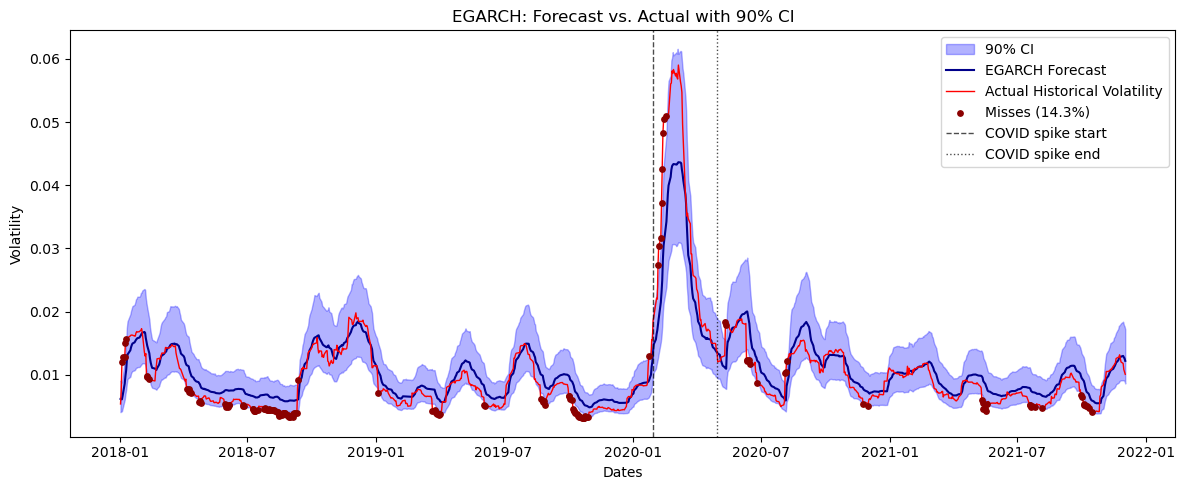

In [110]:
covid_start_egarch, covid_end_egarch = covid_indices(dates_regression_egarch, covid_start_date, covid_end_date)

qlike_breakdown_egarch = covid_breakdown(
    forecast_regression_egarch, actual_regression_egarch,
    covid_start_egarch, covid_end_egarch, qlike
)

print_covid_breakdown(
    qlike_breakdown_egarch, dates_regression_egarch, covid_start_egarch, covid_end_egarch,
    label="EGARCH", metric_name="QLIKE"
)

# ── COVID sub-period breakdown — RV Coverage (90% CI) ──
covid_coverage_egarch = hv_coverage_covid_breakdown(inside_90_egarch, covid_start_egarch, covid_end_egarch)
print_hv_coverage_covid(covid_coverage_egarch, label="EGARCH")

# ── Plot with COVID vlines (matching the baseline's plot style) ──
plot_hv_coverage(
    forecast_regression_egarch, actual_regression_egarch, dates_regression_egarch,
    lower_90_egarch, upper_90_egarch, inside_90_egarch,
    covid_start_date=covid_start_date, covid_end_date=covid_end_date,
    label="EGARCH"
)

In [111]:
# ── PIT alignment: sigma_posterior_egarch against returns (separate from HV alignment above) ──
sigma_posterior_egarch_df = pd.DataFrame(
    sigma_posterior_egarch.T,   # (T, S) — one row per date, one column per draw
    index=regression_returns.index
).dropna()

common_dates_pit = sigma_posterior_egarch_df.index.intersection(regression_returns.index)
sigma_posterior_egarch_pit = sigma_posterior_egarch_df.loc[common_dates_pit].values.T  # back to (S, T_common)
returns_regression_egarch_pit = regression_returns.loc[common_dates_pit].values.flatten()
dates_regression_egarch_pit = common_dates_pit

In [112]:
def compute_pit_posterior(returns, sigma_per_draw, dist='t', df=None):
    '''Method 1: compute u_t per posterior draw, then average across draws.
    sigma_per_draw: shape (S, T) — raw per-day sigma_t, one row per draw.'''
    S, T = sigma_per_draw.shape
    u_per_draw = np.zeros((S, T))
    for s in range(S):
        if dist == 't':
            u_per_draw[s] = stats.t.cdf(returns / sigma_per_draw[s], df=df)
        else:
            u_per_draw[s] = norm.cdf(returns / sigma_per_draw[s])
    u_t = np.mean(u_per_draw, axis=0)   # average across draws — Method 1
    ks_stat, p_value = kstest(u_t, 'uniform')
    return u_t, ks_stat, p_value

EGARCH (posterior-averaged PIT) — KS statistic: 0.0927
EGARCH (posterior-averaged PIT) — p-value: 0.0000
EGARCH (posterior-averaged PIT) — Reject null: model is not well calibrated


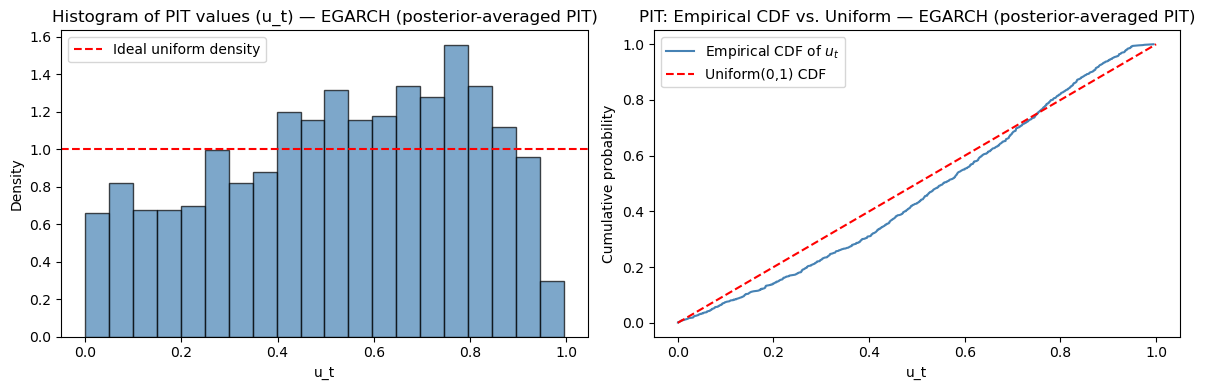

In [113]:
# ── Run PIT using Method 1 (posterior-averaged) ──
u_t_regression_egarch, ks_stat_regression_egarch, p_value_regression_egarch = compute_pit_posterior(
    returns_regression_egarch_pit, sigma_posterior_egarch_pit, dist='t', df=np.median(nu_all)
)
print_pit_result(ks_stat_regression_egarch, p_value_regression_egarch, label="EGARCH (posterior-averaged PIT)")
plot_pit(u_t_regression_egarch, label="EGARCH (posterior-averaged PIT)")

Ljung-Box test on z_t (level) — EGARCH:
      lb_stat  lb_pvalue
1    0.305083   0.580713
5    1.578024   0.903894
10  13.624420   0.190822

Ljung-Box test on z_t^2 (squared, ARCH-LM style) — EGARCH:
      lb_stat  lb_pvalue
1    0.529015   0.467021
5   10.752024   0.056524
10  14.497814   0.151471


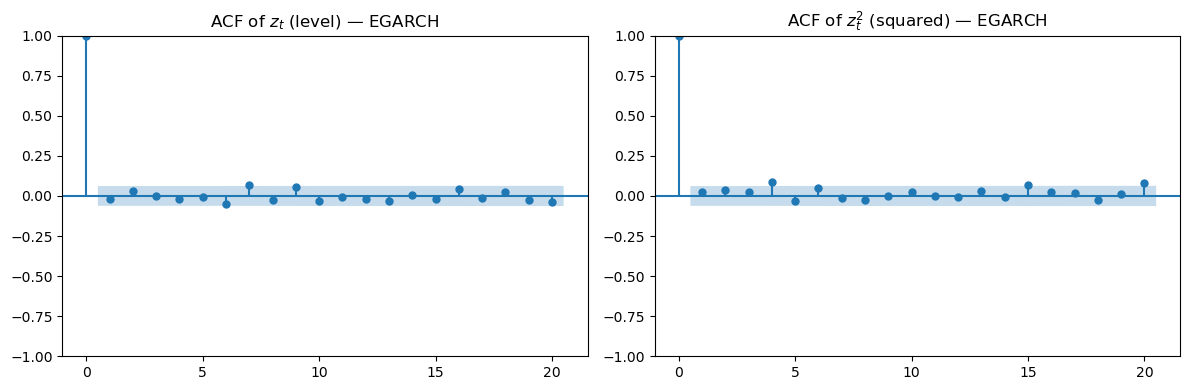

Engle-Ng Sign-Bias Test — EGARCH:
                            OLS Regression Results                            
Dep. Variable:                   z_sq   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     3.420
Date:                Fri, 31 Jul 2026   Prob (F-statistic):             0.0647
Time:                        16:10:57   Log-Likelihood:                -1524.7
No. Observations:                1007   AIC:                             3053.
Df Residuals:                    1005   BIC:                             3063.
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.7

In [73]:
# ── Serial dependence — inherits the corrected Method-1 u_t ──
z_t_regression_egarch = compute_z(u_t_regression_egarch, dates_regression_egarch_pit)

lb_level_regression_egarch, lb_sq_regression_egarch = ljung_box_tests(z_t_regression_egarch)
print_ljung_box(lb_level_regression_egarch, lb_sq_regression_egarch, label="EGARCH")
plot_acf_diagnostics(z_t_regression_egarch, label="EGARCH")

sign_bias_model_regression_egarch = sign_bias_test(
    z_t_regression_egarch, returns_regression_egarch_pit, dates_regression_egarch_pit
)
print_sign_bias(sign_bias_model_regression_egarch, label="EGARCH")

### Sequential EGARCH

In [78]:
# ── Carry forward per-draw end-of-regression state (no re-simulation needed) ──
sigma_carry_egarch = sigma_posterior_egarch[:, -1]         # shape (S,) — each draw's own sigma_T
ls2_carry_egarch = np.log(sigma_carry_egarch**2)           # convert to log-variance scale, per draw

print(f"Number of posterior draws carried forward: {len(sigma_carry_egarch)}")
print(f"Mean sigma at end of regression: {sigma_carry_egarch.mean():.6f}")
print(f"5th-95th percentile: [{np.percentile(sigma_carry_egarch, 5):.6f}, "
      f"{np.percentile(sigma_carry_egarch, 95):.6f}]")

Number of posterior draws carried forward: 8000
Mean sigma at end of regression: 0.008293
5th-95th percentile: [0.007811, 0.008803]


In [87]:
# ── Core numerical/data libraries ──
import numpy as np
import pandas as pd
import scipy.stats as scipy_stats          # note: code uses `scipy_stats.t.cdf`, not `stats.t.cdf`
from scipy.stats import norm, kstest, beta as beta_dist, gamma as gamma_dist
import scipy.special                       # for gammaln, used in E_abs_z_t

# ── JAX / NumPyro (model fitting) ──
import jax
jax.config.update("jax_enable_x64", True)  # MUST be before any JAX operations
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS
numpyro.set_host_device_count(4)

# ── Statistical diagnostics ──
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf
import statsmodels.api as sm

# ── Plotting ──
import matplotlib.pyplot as plt

# ── Saving/loading results ──
import pickle
from pathlib import Path


In [126]:
def fit_beta_params(samples):
    a, b, _, _ = beta_dist.fit(np.array(samples), floc=0, fscale=1)
    return float(a), float(b)

def fit_gamma_params(samples):
    mu, var = np.array(samples).mean(), np.array(samples).var()
    return float(mu**2 / var), float(mu / var)

def forward_simulate_egarch_window(samples_prior, ls2_start_per_draw, T_w):
    '''Forward-simulate T_w days using each draw's own parameters + own carried state.'''
    S = len(samples_prior["alpha"])
    alpha_s  = np.array(samples_prior["alpha"])
    beta_s   = np.array(samples_prior["beta"])
    gamma_s  = np.array(samples_prior["gamma"])
    nu_s     = np.array(samples_prior["nu_shift"]) + 2.1
    uncond_s = np.array(samples_prior["uncond_vol"])
    omega_s  = np.log(uncond_s**2) * (1 - beta_s)
    e_abs_s  = E_abs_z_interp_numpy(nu_s)

    sigma_paths = np.zeros((S, T_w))
    ls2 = ls2_start_per_draw.copy()
    for t in range(T_w):
        sigma_paths[:, t] = np.sqrt(np.exp(np.clip(ls2, -20, 2)))
        z = np.random.standard_t(nu_s) * np.sqrt((nu_s - 2) / nu_s)
        ls2 = np.clip(omega_s + beta_s*ls2 + gamma_s*z + alpha_s*(np.abs(z) - e_abs_s), -20, 2)
    return sigma_paths


# ── Initialize ──────────────────────────────────────────────────────
target_S = 2000
if len(samples_egarch["alpha"]) != target_S:
    idx = np.random.choice(len(samples_egarch["alpha"]), size=target_S, replace=False)
    samples_w = {k: np.array(v)[idx] for k, v in samples_egarch.items()}
    ls2_current_seq = ls2_carry_egarch[idx]   # same subsample indices, so draws stay paired correctly
else:
    samples_w = samples_egarch
    ls2_current_seq = ls2_carry_egarch

all_pit_values_egarch_seq   = []
all_returns_obs_egarch_seq  = []
all_window_stats_egarch_seq = []
all_forecast_egarch_seq     = []
all_hv_per_draw_egarch_seq  = []   # FIX: initialized as a list
all_samples_w_by_window     = []   # NEW: save every window's posterior, not just the last

for i in range(len(window_boundaries) - 1):
    window_start = window_boundaries[i]
    window_end   = window_boundaries[i+1] - pd.Timedelta(days=1)
    window_returns = full_returns[window_start:window_end].values.flatten().astype('float64')
    T_w = len(window_returns)

    # ── Step 0: forward-simulated forecast for THIS window, using ONLY the incoming posterior ──
    sim_paths = forward_simulate_egarch_window(samples_w, ls2_current_seq, T_w)
    forecast_window_egarch = sigma_to_hv_correct(sim_paths, h=21)
    all_forecast_egarch_seq.append(forecast_window_egarch)

    # NEW: per-draw windowed HV, for the posterior-spread + noise coverage construction
    hv_per_draw_window = np.sqrt(sigma_sq_windowed_per_path(sim_paths, h=21))
    all_hv_per_draw_egarch_seq.append(hv_per_draw_window)

    # ── Step 1: PIT from the forecast (sim_paths), Method 1 (averaged across draws) ──
    S = sim_paths.shape[0]
    mu_s = np.array(samples_w["mu_ret"])
    nu_s = np.array(samples_w["nu_shift"]) + 2.1
    scale_s = sim_paths * np.sqrt((nu_s[:, None] - 2) / nu_s[:, None])

    u_per_draw = np.zeros((S, T_w))
    for s in range(S):
        u_per_draw[s] = scipy_stats.t.cdf(window_returns, df=nu_s[s], loc=mu_s[s], scale=scale_s[s])

    pit_w = np.mean(u_per_draw, axis=0)

    all_pit_values_egarch_seq.extend(pit_w)
    all_returns_obs_egarch_seq.extend(window_returns)

    # ── Step 2: Extract priors from previous posterior ──
    alpha_post_seq  = float(np.array(samples_w["alpha"]).mean())
    beta_post_seq   = float(np.array(samples_w["beta"]).mean())
    gamma_post_seq  = float(np.array(samples_w["gamma"]).mean())
    uncond_post_seq = float(np.array(samples_w["uncond_vol"]).mean())
    mu_post_seq     = float(np.array(samples_w["mu_ret"]).mean())

    alpha_prior_mu, alpha_prior_std = alpha_post_seq, max(float(np.array(samples_w["alpha"]).std()), 0.01)
    beta_a, beta_b   = fit_beta_params(samples_w["beta"])
    gamma_prior_mu, gamma_prior_std = gamma_post_seq, max(float(np.array(samples_w["gamma"]).std()), 0.01)
    uncond_prior_mu, uncond_prior_std = uncond_post_seq, max(float(np.array(samples_w["uncond_vol"]).std()), 0.003)
    mu_prior_mu, mu_prior_std = mu_post_seq, max(float(np.array(samples_w["mu_ret"]).std()), 0.0001)
    nu_shape, nu_rate = fit_gamma_params(samples_w["nu_shift"])

    ls2_seed_scalar = float(np.mean(ls2_current_seq))

    # ── Step 3: Refit ──
    returns_jax_w = jnp.array(window_returns)

    def egarch_model_sequential(returns):
        mu_ret   = numpyro.sample("mu_ret",   dist.Normal(mu_prior_mu, mu_prior_std))
        alpha    = numpyro.sample("alpha",    dist.TruncatedNormal(alpha_prior_mu, alpha_prior_std, low=0))
        beta     = numpyro.sample("beta",     dist.Beta(beta_a, beta_b))
        gamma    = numpyro.sample("gamma",    dist.Normal(gamma_prior_mu, gamma_prior_std))
        nu_shift = numpyro.sample("nu_shift", dist.Gamma(nu_shape, nu_rate))
        nu       = nu_shift + 2.1
        uncond_vol = numpyro.sample("uncond_vol", dist.TruncatedNormal(uncond_prior_mu, uncond_prior_std, low=0, high=0.03))
        omega    = jnp.log(uncond_vol**2) * (1 - beta_egarch)

        e_abs_grid_t = jnp.array(e_abs_grid)
        def E_abs_z_interp(nu):
            idx      = (nu - 2.1) / (100 - 2.1) * 999
            idx_low  = jnp.clip(jnp.floor(idx).astype(int), 0, 998)
            idx_high = jnp.clip(idx_low + 1, 0, 999)
            frac     = idx - jnp.floor(idx)
            return e_abs_grid_t[idx_low]*(1-frac) + e_abs_grid_t[idx_high]*frac
        e_abs = E_abs_z_interp(nu)

        def egarch_step(ls2, r):
            z = (r - mu_ret) / jnp.sqrt(jnp.exp(jnp.clip(ls2, -20.0, 2.0)))
            ls2_new = omega + beta*ls2 + gamma*z + alpha*(jnp.abs(z) - e_abs)
            return jnp.clip(ls2_new, -20.0, 2.0), ls2_new

        ls2_init = jnp.float64(ls2_seed_scalar)
        _, log_sigma2 = jax.lax.scan(egarch_step, ls2_init, returns[:-1])
        log_sigma2_full = jnp.concatenate([ls2_init.reshape(1), log_sigma2])
        sigma = jnp.sqrt(jnp.exp(log_sigma2_full))
        numpyro.deterministic("sigma", sigma)
        scale = jnp.clip(sigma * jnp.sqrt((nu-2)/nu), 1e-6, 10)
        numpyro.sample("obs", dist.StudentT(nu, mu_ret, scale), obs=returns)

    print(f"Refitting on {len(window_returns)} observations...")
    mcmc_w = MCMC(NUTS(egarch_model_sequential, target_accept_prob=0.95),
                  num_warmup=500, num_samples=1000, num_chains=2, chain_method="sequential")
    mcmc_w.run(jax.random.PRNGKey(i+100), returns_jax_w)
    samples_w = mcmc_w.get_samples()

    # NEW: save this window's full posterior
    all_samples_w_by_window.append({k: np.array(v) for k, v in samples_w.items()})

    # ── Step 4: carry forward THIS window's own per-draw end state ──
    sigma_window_posterior = np.array(samples_w["sigma"])
    ls2_current_seq = np.log(sigma_window_posterior[:, -1]**2)

    all_window_stats_egarch_seq.append({
        "window": i+1, "start": str(window_start.date()), "end": str(window_end.date()),
        "n_obs": T_w,
        "pit_coverage": float(np.mean((pit_w >= 0.05) & (pit_w <= 0.95))),
        "uncond_vol": uncond_post_seq, "beta": beta_post_seq,
    })
    print(f"Window {i+1} PIT coverage: {all_window_stats_egarch_seq[-1]['pit_coverage']:.2%}")
    print(f"Carry forward mean sigma: {np.mean(np.sqrt(np.exp(ls2_current_seq))):.6f}")

# ── Final arrays ──────────────────────────────────────────────────────
all_pit_values_egarch_seq  = np.array(all_pit_values_egarch_seq)
all_returns_obs_egarch_seq = np.array(all_returns_obs_egarch_seq)
forecast_sequential_egarch = np.concatenate(all_forecast_egarch_seq)

Refitting on 124 observations...


sample: 100%|██████████| 1500/1500 [00:10<00:00, 140.28it/s, 127 steps of size 3.67e-02. acc. prob=0.96]


Window 1 PIT coverage: 65.32%
Carry forward mean sigma: 0.018247
Refitting on 127 observations...


sample: 100%|██████████| 1500/1500 [00:09<00:00, 163.18it/s, 127 steps of size 3.87e-02. acc. prob=0.95]


Window 2 PIT coverage: 85.83%
Carry forward mean sigma: 0.016190
Refitting on 124 observations...


...

Window 6 PIT coverage: 85.94%
Carry forward mean sigma: 0.013144
Refitting on 122 observations...


sample: 100%|██████████| 1500/1500 [00:07<00:00, 207.71it/s, 127 steps of size 2.88e-02. acc. prob=0.96]


Window 7 PIT coverage: 82.79%
Carry forward mean sigma: 0.006697
Refitting on 127 observations...


sample: 100%|██████████| 1500/1500 [00:08<00:00, 173.32it/s, 63 steps of size 3.10e-02. acc. prob=0.95] 

Window 8 PIT coverage: 97.64%
Carry forward mean sigma: 0.006462


In [127]:
sequential_mcmc_egarch = {
    "forecast_sequential":       forecast_sequential_egarch,
    "pit_values":                all_pit_values_egarch_seq,
    "returns_observed":          all_returns_obs_egarch_seq,
    "window_stats":              all_window_stats_egarch_seq,
    "final_samples_w":           {k: np.array(v) for k, v in samples_w.items()},
    "all_forecast_by_window":    all_forecast_egarch_seq,
    "all_hv_per_draw_by_window": all_hv_per_draw_egarch_seq,   # NEW
    "all_samples_w_by_window":   all_samples_w_by_window,       # NEW — avoids ever needing to rerun again
}

with open("results/egarch/egarch_sequential_mcmc.pkl", "wb") as f:
    pickle.dump(sequential_mcmc_egarch, f)

print("Saved sequential MCMC results.")

Saved sequential MCMC results.


In [128]:
forecast_sequential_egarch_pieces = []
forecast_sequential_egarch_dates = []

for i in range(len(window_boundaries) - 1):
    window_start = window_boundaries[i]
    window_end   = window_boundaries[i+1] - pd.Timedelta(days=1)
    window_dates = full_returns[window_start:window_end].index
    piece = all_forecast_egarch_seq[i]
    
    assert len(piece) == len(window_dates), f"Window {i+1}: forecast length {len(piece)} != date length {len(window_dates)}"
    
    forecast_sequential_egarch_pieces.append(piece)
    forecast_sequential_egarch_dates.append(window_dates)

forecast_sequential_egarch_series = pd.Series(
    np.concatenate(forecast_sequential_egarch_pieces),
    index=np.concatenate(forecast_sequential_egarch_dates)
).dropna()

In [129]:
# For PIT / serial dependence — use the loop's own dates and returns directly,
# since PIT (all_pit_values_egarch_seq) has no NaN/aggregation gaps at all —
# it should NOT be aligned against the HV-aggregated forecast_sequential_egarch_series.
pit_dates_pieces = []
for i in range(len(window_boundaries) - 1):
    window_start = window_boundaries[i]
    window_end   = window_boundaries[i+1] - pd.Timedelta(days=1)
    window_dates = full_returns[window_start:window_end].index
    pit_dates_pieces.append(window_dates)

dates_sequential_egarch_pit = np.concatenate(pit_dates_pieces)
returns_sequential_egarch = all_returns_obs_egarch_seq  # already correct length/order, from the loop itself

assert len(all_pit_values_egarch_seq) == len(dates_sequential_egarch_pit), \
    f"Mismatch: {len(all_pit_values_egarch_seq)} PIT values vs {len(dates_sequential_egarch_pit)} dates"
assert len(all_pit_values_egarch_seq) == len(returns_sequential_egarch), \
    f"Mismatch: {len(all_pit_values_egarch_seq)} PIT values vs {len(returns_sequential_egarch)} returns"


In [130]:
assert len(all_pit_values_egarch_seq) == len(dates_sequential_egarch_pit), "PIT values and dates length mismatch!"

In [131]:
forecast_sequential_egarch, actual_sequential_egarch, dates_sequential_egarch = align_series(
    forecast_sequential_egarch_series, hv_sequential
)

In [132]:
ql_sequential_egarch = qlike(forecast_sequential_egarch, actual_sequential_egarch)

qlike_windows_egarch = qlike_by_window(forecast_sequential_egarch, actual_sequential_egarch,
                                         dates_sequential_egarch, window_boundaries)
print_qlike_by_window(qlike_windows_egarch, label="EGARCH")

QLIKE by window — EGARCH:
  window_1 (2022-01-01 to 2022-07-01): 0.4807
  window_2 (2022-07-01 to 2023-01-01): 0.0807
  window_3 (2023-01-01 to 2023-07-01): 0.6072
  window_4 (2023-07-01 to 2024-01-01): 0.3777
  window_5 (2024-01-01 to 2024-07-01): 0.2356
  window_6 (2024-07-01 to 2025-01-01): 0.2796
  window_7 (2025-01-01 to 2025-07-01): 1.4936
  window_8 (2025-07-01 to 2026-01-01): 0.3458


In [133]:
print(len(forecast_sequential_egarch_series))
print(len(hv_sequential))
print(len(forecast_sequential_egarch), len(actual_sequential_egarch), len(dates_sequential_egarch))

842
981
841 841 841


In [134]:
# Concatenate per-window hv_per_draw along the time axis, matching forecast_sequential_egarch_series's dates
hv_per_draw_sequential_egarch_full = np.concatenate(all_hv_per_draw_egarch_seq, axis=1)  # (S, T_total)

hv_per_draw_sequential_df = pd.DataFrame(
    hv_per_draw_sequential_egarch_full.T,
    index=np.concatenate(forecast_sequential_egarch_dates)  # same date pieces used for forecast_sequential_egarch_series
).dropna()

hv_per_draw_sequential_aligned = hv_per_draw_sequential_df.loc[dates_sequential_egarch].values.T

In [135]:
print(len(all_hv_per_draw_egarch_seq))
for i, x in enumerate(all_hv_per_draw_egarch_seq):
    print(i, x.shape)

8
0 (2000, 124)
1 (2000, 127)
2 (2000, 124)
3 (2000, 126)
4 (2000, 124)
5 (2000, 128)
6 (2000, 122)
7 (2000, 127)


90% CI Coverage by window — EGARCH:
  window_1 (2022-01-01 to 2022-07-01): 88.46%
  window_2 (2022-07-01 to 2023-01-01): 100.00%
  window_3 (2023-01-01 to 2023-07-01): 98.08%
  window_4 (2023-07-01 to 2024-01-01): 96.23%
  window_5 (2024-01-01 to 2024-07-01): 100.00%
  window_6 (2024-07-01 to 2025-01-01): 98.15%
  window_7 (2025-01-01 to 2025-07-01): 76.47%
  window_8 (2025-07-01 to 2026-01-01): 93.40%


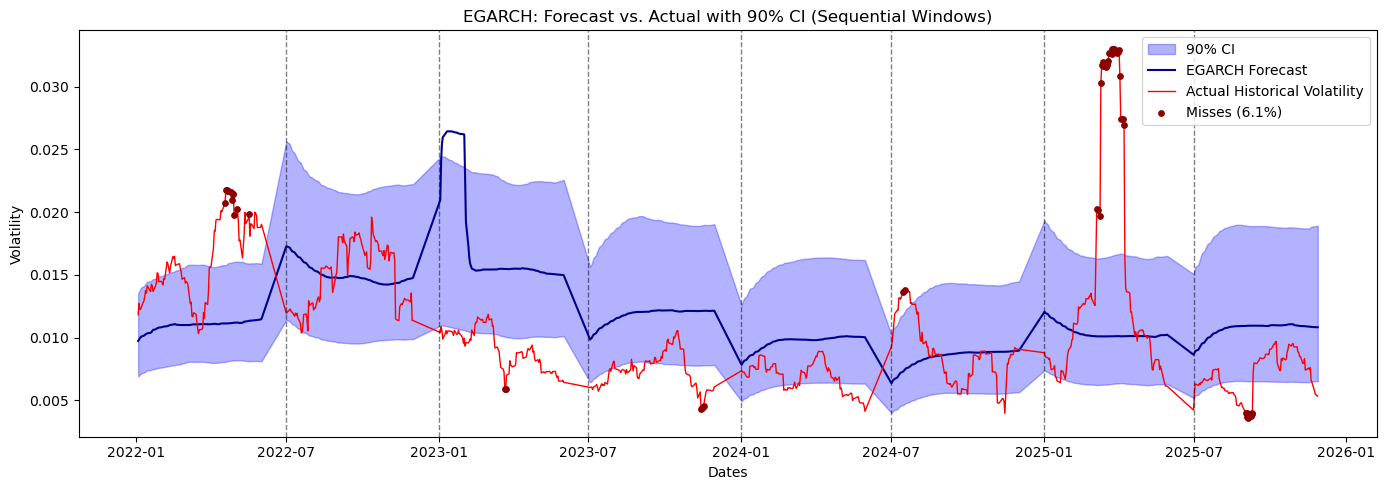

In [136]:
# ── Expanding noise estimate + RV coverage ──
sigma_eta_windows_egarch = sigma_eta_sequential(
    forecast_sequential_egarch, actual_sequential_egarch,
    forecast_regression_egarch, actual_regression_egarch,
    dates_sequential_egarch, window_boundaries
)

def hv_coverage_sequential_posterior(hv_per_draw, actual, dates, window_boundaries, sigma_eta_by_window, level=90):
    '''Combined posterior-spread + noise coverage, using a different sigma_eta per window (expanding).'''
    S, T = hv_per_draw.shape
    inside = np.zeros(T, dtype=bool)
    pct = (100 - level) / 2

    for i, (start_idx, end_idx) in enumerate(window_indices(dates, window_boundaries)):
        sigma_eta_i = sigma_eta_by_window[f"window_{i+1}"]
        window_hv_per_draw = hv_per_draw[:, start_idx:end_idx]
        noise = np.random.normal(0, sigma_eta_i, size=window_hv_per_draw.shape)
        noisy_hv = window_hv_per_draw * np.exp(noise)

        lower = np.percentile(noisy_hv, pct, axis=0)
        upper = np.percentile(noisy_hv, 100 - pct, axis=0)
        inside[start_idx:end_idx] = (actual[start_idx:end_idx] >= lower) & (actual[start_idx:end_idx] <= upper)

    return inside

inside_seq_egarch = hv_coverage_sequential_posterior(
    hv_per_draw_sequential_aligned, actual_sequential_egarch, dates_sequential_egarch,
    window_boundaries, sigma_eta_windows_egarch, level=90
)

coverage_windows_egarch = coverage_by_window(inside_seq_egarch, dates_sequential_egarch, window_boundaries)
print_coverage_by_window(coverage_windows_egarch, label="EGARCH", level=90)

plot_hv_coverage_windows(forecast_sequential_egarch, actual_sequential_egarch, dates_sequential_egarch,
                          lower_seq_egarch, upper_seq_egarch, inside_seq_egarch, window_boundaries,
                          label="EGARCH")

In [139]:
avg_of_hv_per_draw = np.mean(hv_per_draw_sequential_aligned, axis=0)
print(np.mean(forecast_sequential_egarch - avg_of_hv_per_draw))  # should be small but positive, per Jensen

0.0011673153602909285


In [140]:
print(np.mean(forecast_sequential_egarch))
print(0.0011673153602909285 / np.mean(forecast_sequential_egarch))

0.01180566820285389
0.09887753409914933


EGARCH (Sequential) — KS statistic: 0.0278
EGARCH (Sequential) — p-value: 0.4148
EGARCH (Sequential) — Fail to reject null: no evidence of miscalibration


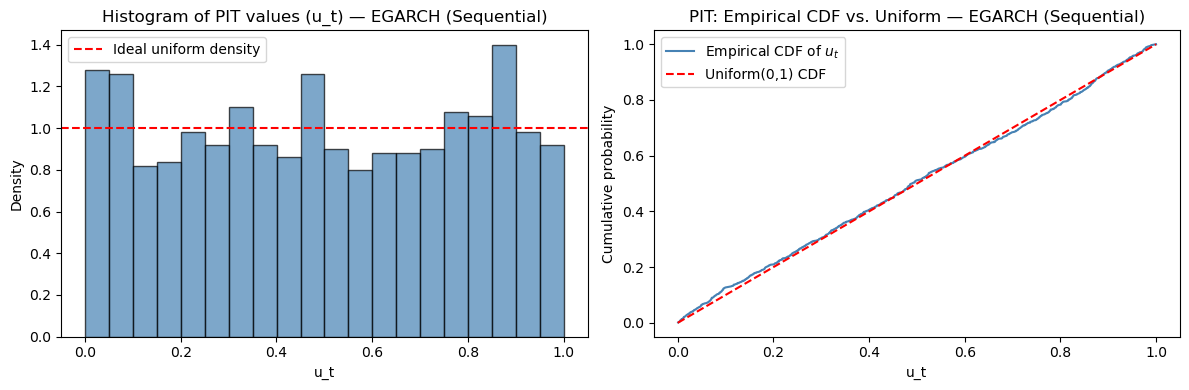

In [137]:
ks_stat_seq_egarch, p_value_seq_egarch = kstest(all_pit_values_egarch_seq, 'uniform')
print_pit_result(ks_stat_seq_egarch, p_value_seq_egarch, label="EGARCH (Sequential)")
plot_pit(all_pit_values_egarch_seq, label="EGARCH (Sequential)")

Ljung-Box test on z_t (level) — EGARCH (Sequential):
     lb_stat  lb_pvalue
1   0.000244   0.987546
5   1.643652   0.895921
10  2.361020   0.992750

Ljung-Box test on z_t^2 (squared, ARCH-LM style) — EGARCH (Sequential):
       lb_stat     lb_pvalue
1    40.080353  2.437280e-10
5   236.785601  3.754071e-49
10  409.912311  7.305037e-82


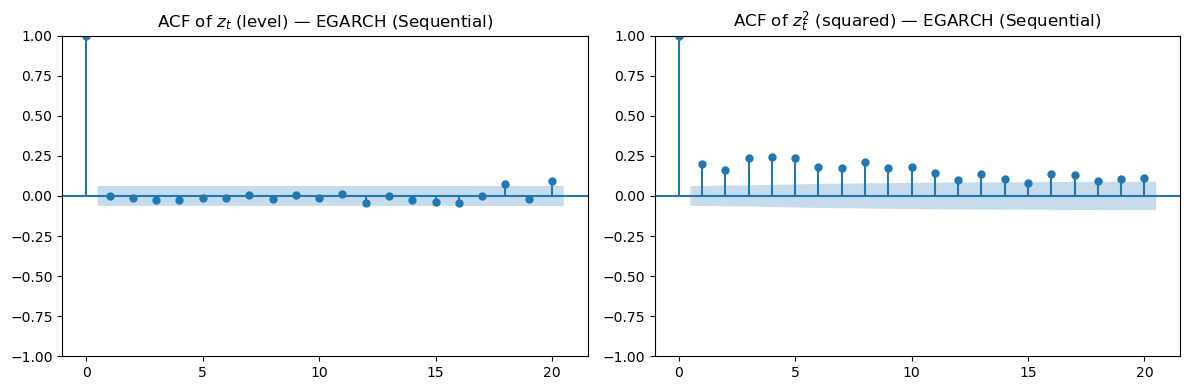

Engle-Ng Sign-Bias Test — EGARCH (Sequential):
                            OLS Regression Results                            
Dep. Variable:                   z_sq   R-squared:                       0.009
Model:                            OLS   Adj. R-squared:                  0.008
Method:                 Least Squares   F-statistic:                     8.866
Date:                Fri, 31 Jul 2026   Prob (F-statistic):            0.00298
Time:                        17:24:20   Log-Likelihood:                -1775.2
No. Observations:                1001   AIC:                             3554.
Df Residuals:                     999   BIC:                             3564.
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const

In [138]:
# ── Serial dependence — using the corrected PIT values, dates, and returns ──
z_t_sequential_egarch = compute_z(all_pit_values_egarch_seq, dates_sequential_egarch_pit)

lb_level_seq_egarch, lb_sq_seq_egarch = ljung_box_tests(z_t_sequential_egarch)
print_ljung_box(lb_level_seq_egarch, lb_sq_seq_egarch, label="EGARCH (Sequential)")
plot_acf_diagnostics(z_t_sequential_egarch, label="EGARCH (Sequential)")

sign_bias_model_seq_egarch = sign_bias_test(
    z_t_sequential_egarch, returns_sequential_egarch, dates_sequential_egarch_pit
)
print_sign_bias(sign_bias_model_seq_egarch, label="EGARCH (Sequential)")

### Particle Filters with Stochastic volatility

In [69]:
from scipy import stats, integrate
import numpy as np

def e_log_zsq_t(nu):
    # E[ln(z^2)] for standardised t_nu
    integrand = lambda z: np.log(z**2) * stats.t.pdf(z, df=nu) 
    result, _ = integrate.quad(integrand, -20, 20)
    return result


In [70]:
print(np.isnan(prior_returns_1d).sum())
print(np.isinf(prior_returns_1d).sum())

0
0


Linearlized Kalman Approximation. Demeaning is necessary since it assumed no return. Most of the parameters aren't particulary helpful since its an approximation

In [72]:
mu_return = prior_returns_1d.mean()
returns_demeaned = prior_returns_1d - mu_return
log_sq_returns = np.log(returns_demeaned**2+1e-6)

from statsmodels.tsa.statespace.structural import UnobservedComponents
model_kf = UnobservedComponents(log_sq_returns, level='local level', autoregressive=1)
res_kf = model_kf.fit(disp = False)
kf_vol = np.sqrt(np.exp(res_kf.filtered_state[0]+1.27))
print(res_kf.summary())
print(mu_return)

                        Unobserved Components Results                         
Dep. Variable:                      y   No. Observations:                 1258
Model:                    local level   Log Likelihood               -2397.086
                              + AR(1)   AIC                           4802.173
Date:                Thu, 07 May 2026   BIC                           4822.719
Time:                        21:01:13   HQIC                          4809.895
Sample:                             0                                         
                               - 1258                                         
Covariance Type:                  opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
sigma2.irregular     2.3131      0.137     16.824      0.000       2.044       2.583
sigma2.level         0.0013      0

In [75]:
# Convert to dict first
param_dict = dict(zip(res_kf.param_names, res_kf.params))
print(param_dict)

sigma_v_kf   = np.sqrt(param_dict['sigma2.irregular'])
sigma_eta_kf = np.sqrt(param_dict['sigma2.level'])
mu_kf        = float(res_kf.filtered_state[0].mean())

print(f"sigma_v:   {sigma_v_kf:.4f}")
print(f"sigma_eta: {sigma_eta_kf:.4f}")
print(f"mu:        {mu_kf:.4f}")

{'sigma2.irregular': np.float64(2.3130610593157988), 'sigma2.level': np.float64(0.001260950642425419), 'sigma2.ar': np.float64(0.10228371159978764), 'ar.L1': np.float64(0.8627536862157024)}
sigma_v:   1.5209
sigma_eta: 0.0355
mu:        -11.1010


### Prior Predictive Check

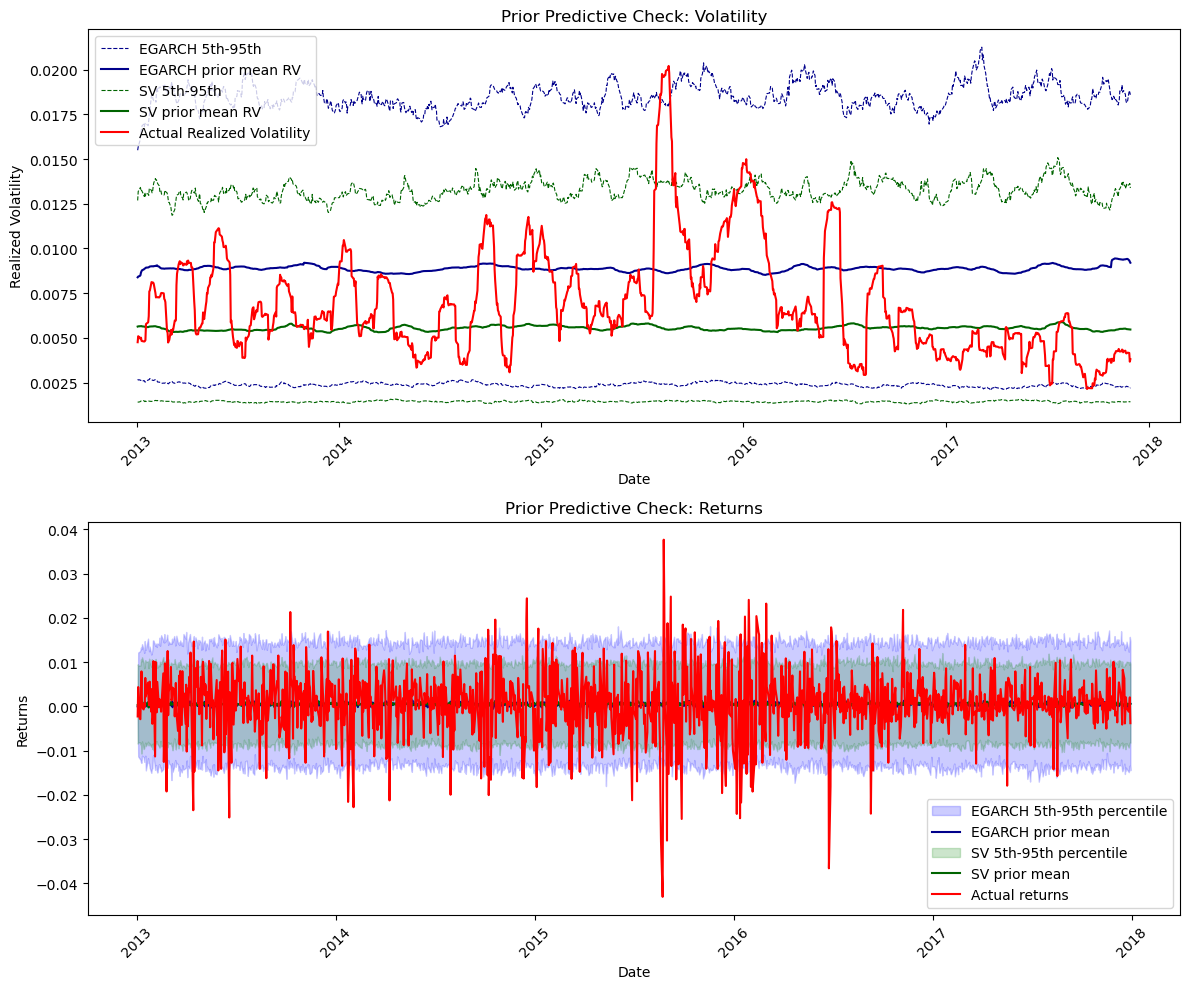

EGARCH valid paths: 991/1000 (99%)
SV valid paths:     929/1000 (93%)


In [206]:
def simulate_sv(mu, phi, sigma_eta, mu_return, n=500):
    log_sigma2 = np.zeros(n)
    r          = np.zeros(n)
    # Stationary initialization
    log_sigma2[0] = np.random.normal(mu, sigma_eta / np.sqrt(1 - phi**2))
    r[0] = mu_return + np.exp(0.5*log_sigma2[0])*np.random.normal(0,1)
    
    for t in range(1, n):
        log_sigma2[t] = mu + phi*(log_sigma2[t-1] - mu) + \
                        np.random.normal(0, sigma_eta)
        r[t] = mu_return + np.exp(0.5*log_sigma2[t]) * np.random.normal(0, 1)
    
    return r, np.sqrt(np.exp(log_sigma2))

# Prior predictive
np.random.seed(42)
n_paths = 1000
valid_paths_sv = 0
n       = len(prior_returns_1d)
vol_sv    = []
rt_sv      = []

for _ in range(n_paths):
    # Sample from priors
    mu_s        = np.random.normal(mu_kf, 1)
    phi_s       = np.random.beta(7, 1)
    sigma_eta_s = np.abs(np.random.normal(0, 0.5)) # sigma_eta is in the range
    mu_return_s = np.random.normal(mu_return, 0.001)
    
    # Stationarity check
    if np.abs(phi_s) >= 1:
        continue
    
    r, sigma = simulate_sv(mu_s, phi_s, sigma_eta_s, mu_return_s, n)
    
    if np.any(np.isnan(r)) or np.any(np.isinf(r)):
        continue
    if np.any(np.isnan(sigma)) or np.any(np.isinf(sigma)):
        continue
    if np.max(np.abs(r)) > 0.5:        # max 50% daily return
        continue
    if np.max(sigma) > 0.3:            # max 30% daily vol
        continue
    if np.min(sigma) < 1e-6:           # min vol floor
        continue
    valid_paths_sv += 1
    vol_sv.append(sigma)
    rt_sv.append(r)

vol_sv_rv = sigma_to_rv_vectorized(np.array(vol_sv),h=21)

# Define RV scale prior paths
vol_egarch_rv = sigma_to_rv_vectorized(np.array(vol_egarch), h=21)
vol_sv_rv     = sigma_to_rv_vectorized(np.array(vol_sv), h=21)
prior_vol_rv_dates = prior_dates[:vol_egarch_rv.shape[1]]

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# ── Plot 1: Volatility ─────────────────────────────────────────────────
# EGARCH
lower = np.percentile(vol_egarch_rv, 5,  axis=0)
upper = np.percentile(vol_egarch_rv, 95, axis=0)
mean  = np.mean(vol_egarch_rv, axis=0)
# Option 1 — just the boundary lines, no fill
axes[0].plot(prior_vol_rv_dates, lower, 
             color="darkblue", linewidth=0.8, linestyle='--', 
             label="EGARCH 5th-95th")
axes[0].plot(prior_vol_rv_dates, upper, 
             color="darkblue", linewidth=0.8, linestyle='--')
ql_rolling
axes[0].plot(prior_vol_rv_dates, mean, color="darkblue",
             linewidth=1.5, label="EGARCH prior mean RV")

# SV
lower = np.percentile(vol_sv_rv, 5,  axis=0)
upper = np.percentile(vol_sv_rv, 95, axis=0)
mean  = np.mean(vol_sv_rv, axis=0)
axes[0].plot(prior_vol_rv_dates, lower, 
             color="darkgreen", linewidth=0.8, linestyle='--',
             label="SV 5th-95th")
axes[0].plot(prior_vol_rv_dates, upper, 
             color="darkgreen", linewidth=0.8, linestyle='--')
axes[0].plot(prior_vol_rv_dates, mean, color="darkgreen",
             linewidth=1.5, label="SV prior mean RV")

# Actual RV
axes[0].plot(prior_rv_dates, rv_prior_1d_strict, color="red",
             linewidth=1.5, label="Actual Realized Volatility")

axes[0].set_title(f"Prior Predictive Check: Volatility")
axes[0].set_ylabel("Realized Volatility")
axes[0].set_xlabel("Date")
axes[0].legend()

# ── Plot 2: Returns ────────────────────────────────────────────────────
# EGARCH
lower = np.percentile(rt_egarch, 5,  axis=0)
upper = np.percentile(rt_egarch, 95, axis=0)
mean  = np.mean(rt_egarch, axis=0)
axes[1].fill_between(prior_ret_dates, lower, upper,
                     alpha=0.2, color="blue",
                     label="EGARCH 5th-95th percentile")
axes[1].plot(prior_ret_dates, mean, color="darkblue",
             linewidth=1.5, label="EGARCH prior mean")

# SV
lower = np.percentile(rt_sv, 5,  axis=0)
upper = np.percentile(rt_sv, 95, axis=0)
mean  = np.mean(rt_sv, axis=0)
axes[1].fill_between(prior_ret_dates, lower, upper,
                     alpha=0.2, color="green",
                     label="SV 5th-95th percentile")
axes[1].plot(prior_ret_dates, mean, color="darkgreen",
             linewidth=1.5, label="SV prior mean")

# Actual returns — once only
axes[1].plot(prior_ret_dates, prior_returns_1d[:len(prior_ret_dates)],
             color="red", linewidth=1.5, label="Actual returns")

axes[1].set_title("Prior Predictive Check: Returns")
axes[1].set_ylabel("Returns")
axes[1].set_xlabel("Date")
axes[1].legend()

plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45)
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45)
plt.tight_layout()
plt.savefig("combined_prior_predictive.pdf", bbox_inches='tight')
plt.show()

print(f"EGARCH valid paths: {valid_paths_egarch}/{n_paths} "
      f"({valid_paths_egarch/n_paths*100:.0f}%)")
print(f"SV valid paths:     {valid_paths_sv}/{n_paths} "
      f"({valid_paths_sv/n_paths*100:.0f}%)")


In [ ]:
Particle Filter

In [82]:
import numpy as np
from scipy import stats as scipy_stats

def particle_filter_sv(returns, mu, phi, sigma_eta, mu_return, N):
    T = len(returns)
    
    # Initialize particles from stationary distribution
    init_std = sigma_eta / np.sqrt(1 - phi**2)
    particles = np.random.normal(mu, init_std, N)
    log_likelihood = 0.0
    filtered_means = []
    
    for t in range(T):
        # 1. Propagate — state equation
        particles = mu + phi*(particles - mu) + \
                    np.random.normal(0, sigma_eta, N)
        
        # 2. Reweight — observation equation
        # how likely is the return given the volatility estimate
        sigma_t  = np.sqrt(np.exp(particles))
        log_w     = scipy_stats.norm.logpdf(returns[t], loc=mu_return, scale=sigma_t)
        max_lw    = log_w.max()                          
        log_w    -= max_lw
        weights   = np.exp(log_w) # just likelihood (the previous 2 lines are only there for numerical reasons)
        weights  /= weights.sum()
        
        log_likelihood += max_lw + np.log(np.mean(np.exp(log_w)))   
        # 3. Resample — systematic resampling
        # eliminate particles with low weights, so create try and duplicate high weights and discard low weights
        # so all N particles have similar weight
        cumsum = np.cumsum(weights)
        u      = np.random.uniform(0, 1/N) + np.arange(N)/N # note the left term is a common increase to all the particles (not n distinct)
        idx    = np.searchsorted(cumsum, u) # this is the key part of the code, 
                                            # as particles with more weight cover more interval length
        particles = particles[idx]
        
        filtered_means.append(particles.mean())
    
    return np.array(filtered_means), log_likelihood, particles

### Particle Filter REgression

In [83]:
# ── Regression PMCMC ──────────────────────────────────────────────────
# MH logic with ability to increase/decrease accepts based on how close/far away model is to correct solution.
def pmcmc_regression(returns, n_mcmc=1000, N=500,
                     mu_init=mu_kf, phi_init=0.93,
                     sigma_eta_init=sigma_eta_kf,
                     mu_return_init=mu_return):
    
    theta_current = np.array([mu_init, phi_init, 
                               sigma_eta_init, mu_return_init])
    _, ll_current, _ = particle_filter_sv(returns, *theta_current, N=N)
    
    samples    = np.zeros((n_mcmc, 4))
    ll_history = np.zeros(n_mcmc)
    accepted   = 0
    
    proposal_std   = np.array([0.2, 0.02, 0.05, 0.0002])
    target_rate    = 0.20
    adapt_interval = 50
    adapt_end      = 500
    scale_factor   = 0.85
    
    def log_prior(theta):
        mu_p, phi_p, sigma_eta_p, mu_ret_p = theta
        lp  = scipy_stats.norm.logpdf(mu_p,     mu_kf,      1.0)
        lp += scipy_stats.beta.logpdf(phi_p,    7,          1)
        lp += scipy_stats.halfnorm.logpdf(sigma_eta_p, scale=0.5)
        lp += scipy_stats.norm.logpdf(mu_ret_p, mu_return,  0.001)
        return lp
    
    print("Running Regression PMCMC...")
    for i in range(n_mcmc):
        if i > 0 and i < adapt_end and i % adapt_interval == 0:
            current_rate = accepted / i
            if current_rate < target_rate:
                proposal_std *= scale_factor
            else:
                proposal_std /= scale_factor
            proposal_std = np.clip(proposal_std, 1e-4, 1.0)
            print(f"Step {i}: rate={current_rate:.2%}, "
                  f"proposal_std={proposal_std.round(4)}")
        elif i % 100 == 0:
            print(f"Step {i}/{n_mcmc}, "
                  f"acceptance rate: {accepted/(i+1) if i>0 else 0:.2%}")
        
        theta_proposed = theta_current + np.random.normal(0, proposal_std, 4)
        
        if np.abs(theta_proposed[1]) >= 1:
            samples[i] = theta_current; ll_history[i] = ll_current; continue
        if theta_proposed[2] <= 0:
            samples[i] = theta_current; ll_history[i] = ll_current; continue
        
        _, ll_proposed, _ = particle_filter_sv(returns, *theta_proposed, N=N)
        
        log_alpha = (ll_proposed + log_prior(theta_proposed)) - \
                    (ll_current  + log_prior(theta_current))
        
        if np.log(np.random.uniform()) < log_alpha:
            theta_current = theta_proposed
            ll_current    = ll_proposed
            accepted     += 1
        
        samples[i]    = theta_current
        ll_history[i] = ll_current
    
    print(f"Final acceptance rate: {accepted/n_mcmc:.2%}")
    return samples, ll_history


  


Running Regression PMCMC...
Step 0/3000, acceptance rate: 0.00%
Step 50: rate=16.00%, proposal_std=[0.17   0.017  0.0425 0.0002]
Step 100: rate=14.00%, proposal_std=[1.445e-01 1.440e-02 3.610e-02 1.000e-04]
Step 150: rate=20.67%, proposal_std=[0.17   0.017  0.0425 0.0002]
Step 200: rate=23.50%, proposal_std=[0.2    0.02   0.05   0.0002]
Step 250: rate=22.40%, proposal_std=[2.353e-01 2.350e-02 5.880e-02 2.000e-04]
Step 300: rate=20.00%, proposal_std=[0.2768 0.0277 0.0692 0.0003]
Step 350: rate=18.57%, proposal_std=[2.353e-01 2.350e-02 5.880e-02 2.000e-04]
Step 400: rate=19.00%, proposal_std=[0.2    0.02   0.05   0.0002]
Step 450: rate=18.67%, proposal_std=[0.17   0.017  0.0425 0.0002]
Step 500/3000, acceptance rate: 19.56%
Step 600/3000, acceptance rate: 22.96%
Step 700/3000, acceptance rate: 23.97%
Step 800/3000, acceptance rate: 24.34%
Step 900/3000, acceptance rate: 25.42%
Step 1000/3000, acceptance rate: 26.27%
Step 1100/3000, acceptance rate: 26.79%
Step 1200/3000, acceptance rate:

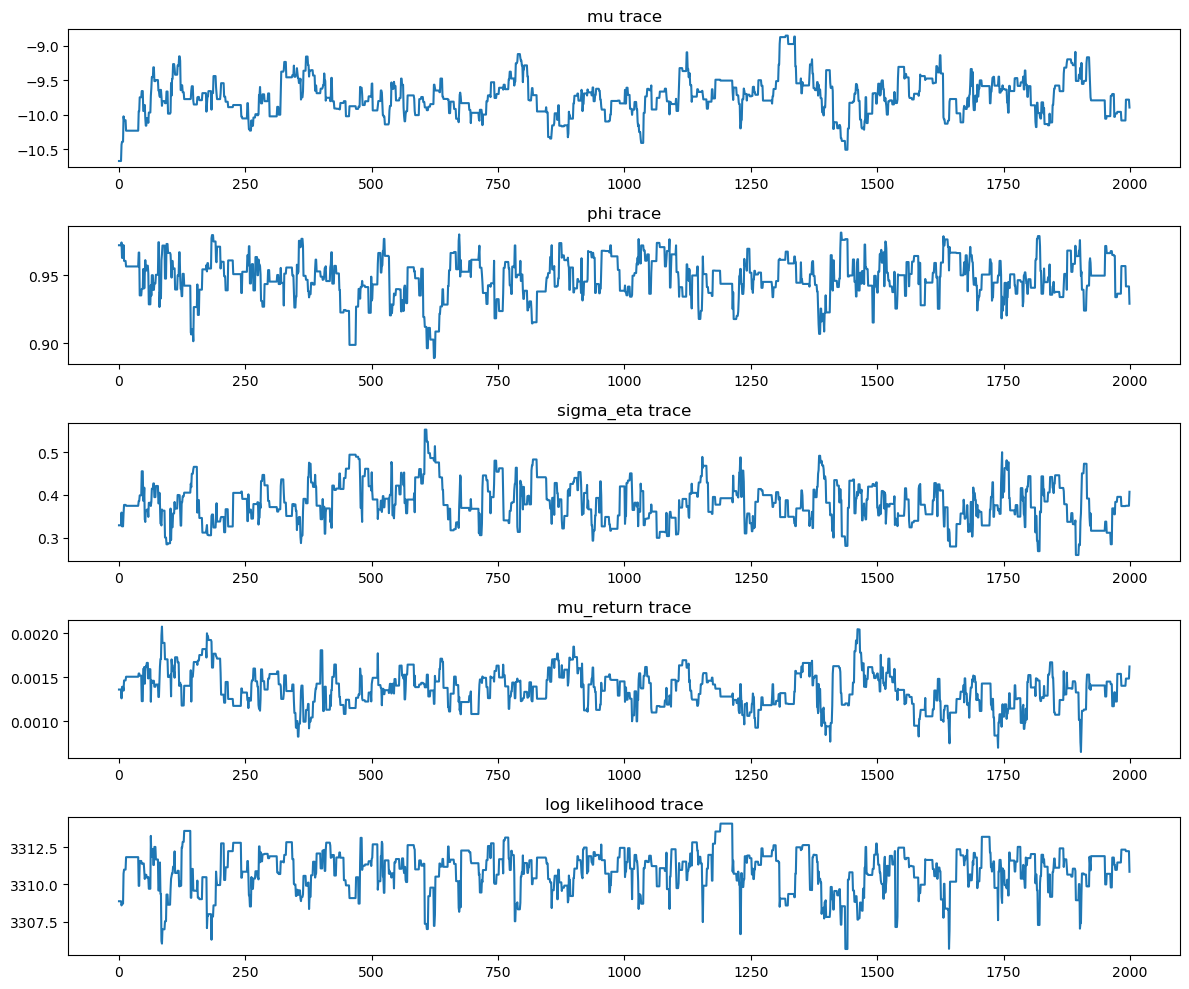

In [85]:


# Run PMCMC
samples_sv, ll_history = pmcmc_regression(
    regression_returns_1d,
    n_mcmc=3000,
    N=2000,
    mu_init=mu_kf,
    phi_init=0.875,
    sigma_eta_init=sigma_eta_kf,
    mu_return_init = mu_return
)

# Discard burn-in
burnin = 1000
samples_sv = samples_sv[burnin:]

# Results
mu_samples        = samples_sv[:, 0]
phi_samples       = samples_sv[:, 1]
sigma_eta_samples = samples_sv[:, 2]
mu_return_samples = samples_sv[:, 3]

print(f"\nPosterior means:")
print(f"mu:        {mu_samples.mean():.4f}")
print(f"phi:       {phi_samples.mean():.4f}")
print(f"sigma_eta: {sigma_eta_samples.mean():.4f}")
print(f"mu_return: {mu_return_samples.mean():.6f}")
# Plot traces
fig, axes = plt.subplots(5, 1, figsize=(12, 10))
axes[0].plot(mu_samples);        axes[0].set_title("mu trace")
axes[1].plot(phi_samples);       axes[1].set_title("phi trace")
axes[2].plot(sigma_eta_samples); axes[2].set_title("sigma_eta trace")
axes[3].plot(mu_return_samples); axes[3].set_title("mu_return trace")
axes[4].plot(ll_history[burnin:]);  axes[4].set_title("log likelihood trace")
plt.tight_layout()
plt.show()

In [86]:
# Check log-likelihood variance
ll_after_burnin = ll_history[burnin:]
print(f"ll std: {ll_after_burnin.std():.4f}")
# Should be ~1.0 for optimal PMCMC
# If >> 1 → need more particles
# If << 1 → can reduce particles

ll std: 1.4115


In [87]:
print(f"mu mean:   {mu_samples.mean():.4f}")
print(f"mu std:    {mu_samples.std():.4f}")
print(f"mu 5-95%:  [{np.percentile(mu_samples,5):.4f}, {np.percentile(mu_samples,95):.4f}]")
print(f"mu_kf:     {mu_kf:.4f}")

mu mean:   -9.7405
mu std:    0.2720
mu 5-95%:  [-10.1599, -9.2844]
mu_kf:     -11.1010


ll std after burnin: 1.4115


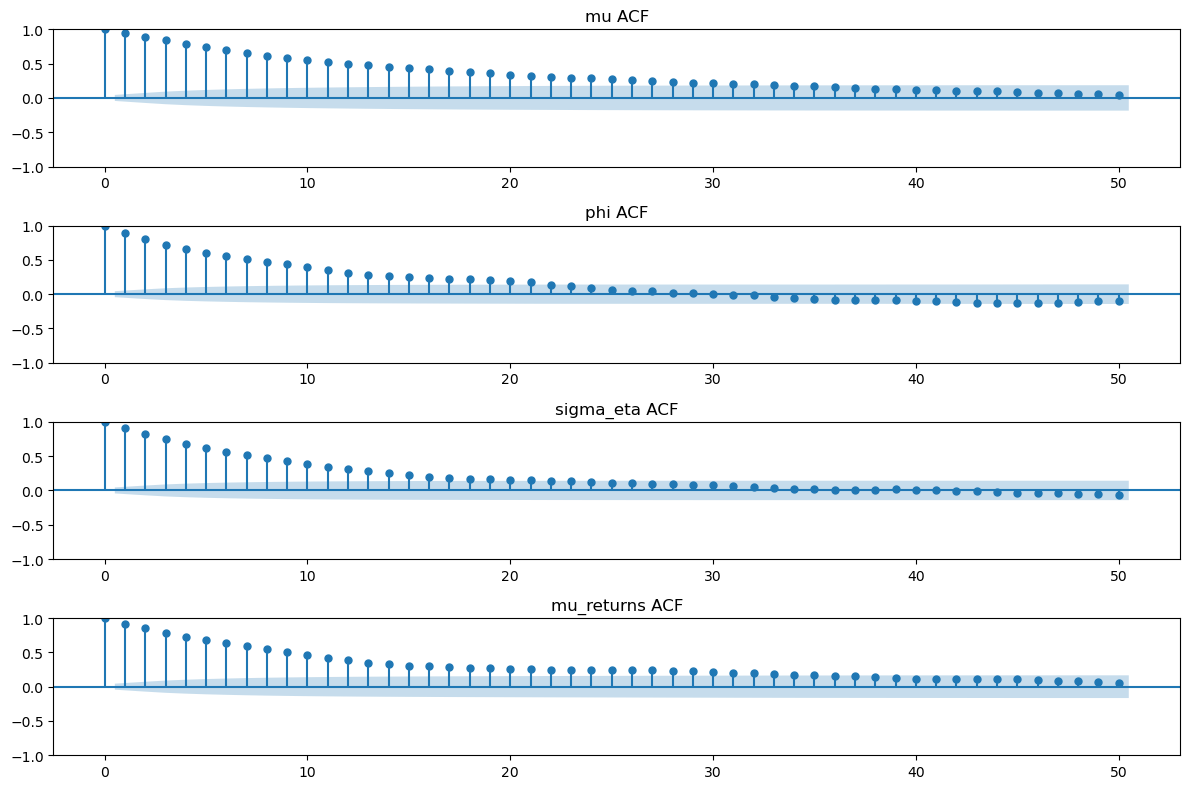

In [88]:
ll_after_burnin = ll_history[burnin:]
print(f"ll std after burnin: {ll_after_burnin.std():.4f}")

# Check ACF quickly
from statsmodels.graphics.tsaplots import plot_acf
fig, axes = plt.subplots(4, 1, figsize=(12, 8))
plot_acf(mu_samples, lags=50, ax=axes[0], title="mu ACF")
plot_acf(phi_samples, lags=50, ax=axes[1], title="phi ACF")
plot_acf(sigma_eta_samples, lags=50, ax=axes[2], title="sigma_eta ACF")
plot_acf(mu_return_samples, lags=50, ax=axes[3], title="mu_returns ACF")
plt.tight_layout()
plt.show()

### Plotting Realized Vol

In [91]:
# ── Step 1: Get filtered vol paths ────────────────────────────────────
thin_interval = 15
idx_thin      = np.arange(0, len(mu_samples), thin_interval)
n_thin        = len(idx_thin)

sigma_posterior_sv = np.zeros((n_thin, len(regression_returns_1d)))

for j, idx in enumerate(idx_thin):
    filtered, _, _ = particle_filter_sv(
        regression_returns_1d,
        mu=mu_samples[idx], phi=phi_samples[idx],
        sigma_eta=sigma_eta_samples[idx],
        mu_return=mu_return_samples[idx], N=1000
    )
    sigma_posterior_sv[j] = np.sqrt(np.exp(filtered))

print(f"sigma_posterior_sv shape: {sigma_posterior_sv.shape}")

# ── Step 2: Convert to RV scale ────────────────────────────────────────
sigma_posterior_rv_sv = sigma_to_rv_vectorized(sigma_posterior_sv, h=21)
print(f"sigma_posterior_rv_sv shape: {sigma_posterior_rv_sv.shape}")

# ── Step 3: Align with actual RV ───────────────────────────────────────
n_sv         = min(len(rv_regression_1d), sigma_posterior_rv_sv.shape[1])
rv_actual_sv = rv_regression_1d[:n_sv]
rv_mean_sv   = sigma_posterior_rv_sv.mean(axis=0)[:n_sv]
rv_lower_sv  = np.percentile(sigma_posterior_rv_sv, 5,  axis=0)[:n_sv]
rv_upper_sv  = np.percentile(sigma_posterior_rv_sv, 95, axis=0)[:n_sv]

sigma_posterior_sv shape: (134, 1008)
sigma_posterior_rv_sv shape: (134, 987)
Coverage (no noise):   21.07%


Measurement noise std: 0.1783
Coverage (with noise): 89.67%
COVID start: 2020-01-30 (obs 522)
COVID end:   2020-04-30 (obs 585)
Pre-COVID coverage:  89.66%
COVID coverage:      66.67%
Post-COVID coverage: 93.28%


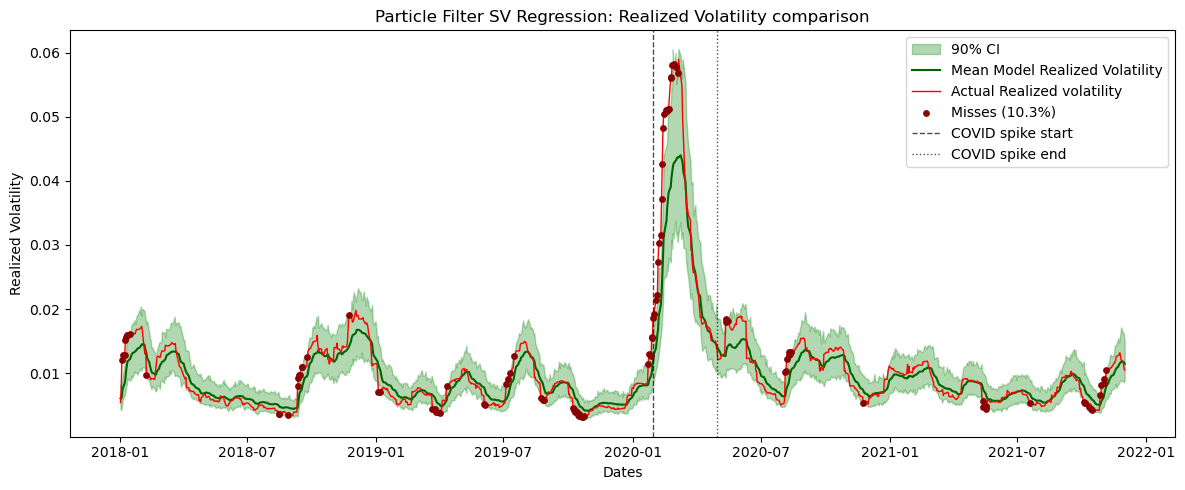

In [94]:
# Coverage with measurement noise
sigma_eta_meas_sv = np.std(np.log(rv_actual_sv) - np.log(rv_mean_sv))
print(f"Measurement noise std: {sigma_eta_meas_sv:.4f}")

noise_sv = np.random.normal(0, sigma_eta_meas_sv, 
                              size=sigma_posterior_rv_sv[:, :n_sv].shape)
sigma_posterior_rv_noisy_sv = sigma_posterior_rv_sv[:, :n_sv] * np.exp(noise_sv)

rv_lower_noisy_sv = np.percentile(sigma_posterior_rv_noisy_sv, 5,  axis=0)
rv_upper_noisy_sv = np.percentile(sigma_posterior_rv_noisy_sv, 95, axis=0)

inside_noisy_sv   = (rv_actual_sv >= rv_lower_noisy_sv) & \
                    (rv_actual_sv <= rv_upper_noisy_sv)
coverage_noisy_sv = np.mean(inside_noisy_sv)
print(f"Coverage (with noise): {coverage_noisy_sv:.2%}")

# COVID — same dates as EGARCH
print(f"COVID start: {regression_dates[covid_idx].date()} (obs {covid_idx})")
print(f"COVID end:   {regression_dates[covid_end].date()} (obs {covid_end})")

# Pre-COVID
inside_pre_sv = (rv_actual_sv[:covid_idx] >= rv_lower_noisy_sv[:covid_idx]) & \
                (rv_actual_sv[:covid_idx] <= rv_upper_noisy_sv[:covid_idx])
print(f"Pre-COVID coverage:  {np.mean(inside_pre_sv):.2%}")

# COVID period
inside_covid_sv = (rv_actual_sv[covid_idx:covid_end] >= rv_lower_noisy_sv[covid_idx:covid_end]) & \
                  (rv_actual_sv[covid_idx:covid_end] <= rv_upper_noisy_sv[covid_idx:covid_end])
print(f"COVID coverage:      {np.mean(inside_covid_sv):.2%}")

# Post-COVID
inside_post_sv = (rv_actual_sv[covid_end:n_sv] >= rv_lower_noisy_sv[covid_end:n_sv]) & \
                 (rv_actual_sv[covid_end:n_sv] <= rv_upper_noisy_sv[covid_end:n_sv])
print(f"Post-COVID coverage: {np.mean(inside_post_sv):.2%}")

# Plot
fig, ax = plt.subplots(figsize=(12, 5))

ax.fill_between(regression_dates[:n_sv], rv_lower_noisy_sv, rv_upper_noisy_sv,
                alpha=0.3, color='green', label='90% CI')
ax.plot(regression_dates[:n_sv], rv_mean_sv, 
        color='darkgreen', lw=1.5, label='Mean Model Realized Volatility')
ax.plot(regression_dates[:n_sv], rv_actual_sv, 
        color='red', lw=1, label='Actual Realized volatility')

# Misses
miss_idx_sv_reg   = np.where(~inside_noisy_sv)[0]
miss_dates_sv_reg = regression_dates[miss_idx_sv_reg]
ax.scatter(miss_dates_sv_reg, rv_actual_sv[miss_idx_sv_reg],
           color='darkred', s=15, zorder=5,
           label=f'Misses ({(1-coverage_noisy_sv)*100:.1f}%)')

ax.axvline(covid_start_date, color='black', linestyle='--',
           alpha=0.7, lw=1, label='COVID spike start')
ax.axvline(covid_end_date, color='black', linestyle=':',
           alpha=0.7, lw=1, label='COVID spike end')

ax.set_title("Particle Filter SV Regression: Realized Volatility comparison")
ax.set_xlabel("Dates")
ax.set_ylabel("Realized Volatility")
ax.legend()
plt.tight_layout()
plt.savefig("sv_regression_rv.pdf", bbox_inches='tight')
plt.show()

PIT histogram (not used since its hard to interpret)

PF SV PIT KS p-value: 0.0219
PF SV PIT coverage:   98.31%


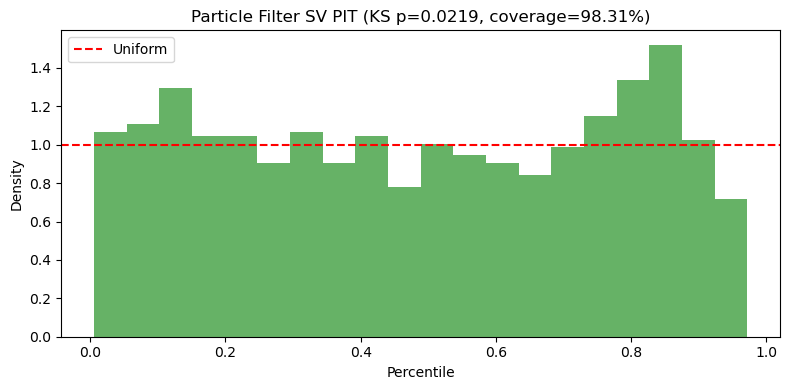

In [120]:
# ── PIT for Particle Filter SV ─────────────────────────────────────────
n_pit_sv = min(len(regression_returns_1d), sigma_posterior_sv.shape[1])

cdf_matrix_sv = scipy_stats.norm.cdf(
    regression_returns_1d[:n_pit_sv][np.newaxis, :],
    loc=mu_return_samples[idx_thin][:, np.newaxis],
    scale=sigma_posterior_sv[:, :n_pit_sv]
)
u_sv = cdf_matrix_sv.mean(axis=0)

ks_stat_sv, ks_pval_sv = scipy_stats.kstest(u_sv, 'uniform')
coverage_pit_sv = np.mean((u_sv >= 0.05) & (u_sv <= 0.95))

print(f"PF SV PIT KS p-value: {ks_pval_sv:.4f}")
print(f"PF SV PIT coverage:   {coverage_pit_sv:.2%}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(u_sv, bins=20, density=True, alpha=0.6, color='green')
ax.axhline(1, color='red', linestyle='--', label='Uniform')
ax.set_xlabel("Percentile")
ax.set_ylabel("Density")
ax.set_title(f"Particle Filter SV PIT (KS p={ks_pval_sv:.4f}, "
             f"coverage={coverage_pit_sv:.2%})")
ax.legend()
plt.tight_layout()
plt.savefig("sv_regression_pit.pdf", bbox_inches='tight')
plt.show()

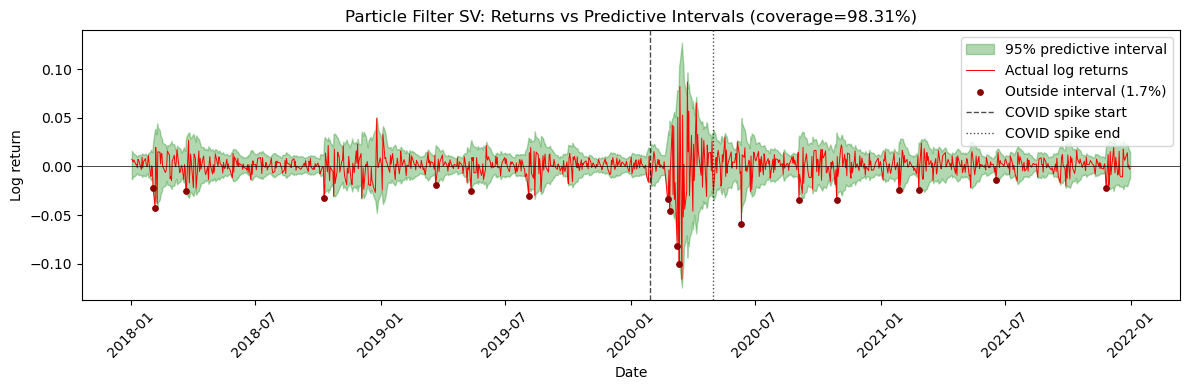

In [127]:
# ── SV Regression Returns predictive interval ──────────────────────────
mu_return_mean_sv = mu_return_samples[idx_thin].mean()
scale_mean_sv_ret = sigma_posterior_sv.mean(axis=0)

n_ret_sv = min(len(regression_returns_1d), len(scale_mean_sv_ret),
               len(regression_returns.index))

lower_ret_sv = scipy_stats.norm.ppf(0.05, loc=mu_return_mean_sv,
                                     scale=scale_mean_sv_ret)
upper_ret_sv = scipy_stats.norm.ppf(0.95, loc=mu_return_mean_sv,
                                     scale=scale_mean_sv_ret)

inside_ret_sv   = (regression_returns_1d[:n_ret_sv] >= lower_ret_sv[:n_ret_sv]) & \
                  (regression_returns_1d[:n_ret_sv] <= upper_ret_sv[:n_ret_sv])
miss_idx_ret_sv = np.where(~inside_ret_sv)[0]

fig, ax = plt.subplots(figsize=(12, 4))

ax.fill_between(regression_returns.index[:n_ret_sv],
                lower_ret_sv[:n_ret_sv], upper_ret_sv[:n_ret_sv],
                alpha=0.3, color='green', label='90% predictive interval')
ax.plot(regression_returns.index[:n_ret_sv],
        regression_returns_1d[:n_ret_sv], 
        color='red', lw=0.7, label='Actual log returns')
ax.scatter(regression_dates[miss_idx_ret_sv],
           regression_returns_1d[miss_idx_ret_sv],
           color='darkred', s=15, zorder=5,
           label=f'Outside interval ({(1-coverage_pit_sv)*100:.1f}%)')
ax.axhline(0, color='black', lw=0.5)

# COVID lines — already defined
ax.axvline(covid_start_date, color='black', linestyle='--',
           alpha=0.7, lw=1, label='COVID spike start')
ax.axvline(covid_end_date, color='black', linestyle=':',
           alpha=0.7, lw=1, label='COVID spike end')

ax.set_xlabel("Date")
ax.set_ylabel("Log return")
ax.set_title(f"Particle Filter SV: Returns vs Predictive Intervals "
             f"(coverage={coverage_pit_sv:.2%})")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("sv_regression_returns_interval.pdf", bbox_inches='tight')
plt.show()

In [119]:
print("Coverage at different CI levels (SV Regression):")
print("-" * 40)
for level in [50, 60, 70, 80, 85, 90, 95, 99]:
    lower = np.percentile(sigma_posterior_rv_noisy_sv, (100-level)/2, axis=0)
    upper = np.percentile(sigma_posterior_rv_noisy_sv, 100-(100-level)/2, axis=0)
    inside = (rv_actual_sv >= lower) & (rv_actual_sv <= upper)
    print(f"{level}% CI coverage: {np.mean(inside):.2%}")

Coverage at different CI levels (SV Regression):
----------------------------------------
50% CI coverage: 49.44%
60% CI coverage: 60.99%
70% CI coverage: 72.24%
80% CI coverage: 82.47%
85% CI coverage: 86.63%
90% CI coverage: 89.67%
95% CI coverage: 93.92%
99% CI coverage: 98.28%


In [ ]:
Key emprical CDF graph

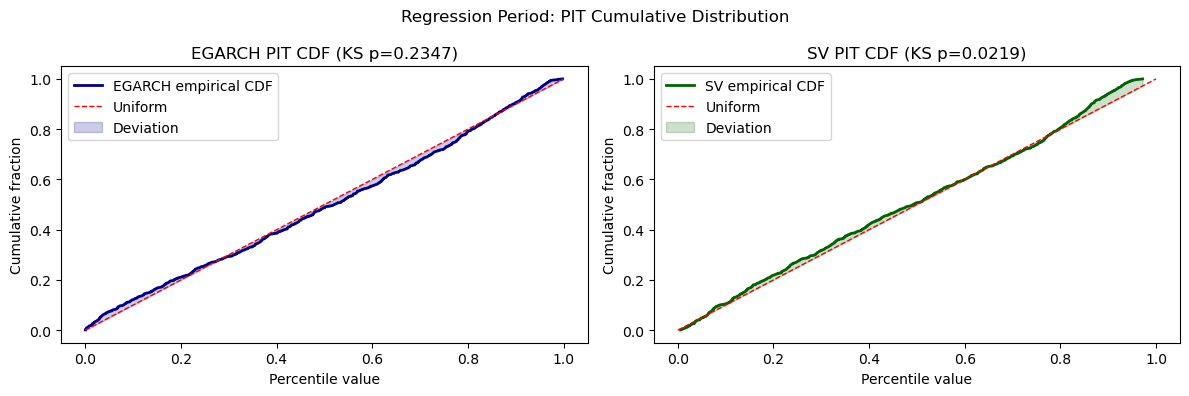

In [272]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Sort u values
u_egarch_sorted = np.sort(u_egarch)
u_sv_sorted     = np.sort(u_sv)
n_e = len(u_egarch_sorted)
n_s = len(u_sv_sorted)

# Empirical CDF
ecdf_egarch = np.arange(1, n_e+1) / n_e
ecdf_sv     = np.arange(1, n_s+1) / n_s

# Uniform reference line
x_uniform = np.linspace(0, 1, 100)

# EGARCH
axes[0].plot(u_egarch_sorted, ecdf_egarch, 
             color='darkblue', lw=2, label='EGARCH empirical CDF')
axes[0].plot(x_uniform, x_uniform, 
             color='red', linestyle='--', lw=1, label='Uniform')
axes[0].fill_between(u_egarch_sorted, ecdf_egarch, u_egarch_sorted,
                     alpha=0.2, color='darkblue', label='Deviation')
axes[0].set_xlabel("Percentile value")
axes[0].set_ylabel("Cumulative fraction")
axes[0].set_title(f"EGARCH PIT CDF (KS p={ks_pval_egarch:.4f})")
axes[0].legend()

# SV
axes[1].plot(u_sv_sorted, ecdf_sv,
             color='darkgreen', lw=2, label='SV empirical CDF')
axes[1].plot(x_uniform, x_uniform,
             color='red', linestyle='--', lw=1, label='Uniform')
axes[1].fill_between(u_sv_sorted, ecdf_sv, u_sv_sorted,
                     alpha=0.2, color='darkgreen', label='Deviation')
axes[1].set_xlabel("Percentile value")
axes[1].set_ylabel("Cumulative fraction")
axes[1].set_title(f"SV PIT CDF (KS p={ks_pval_sv:.4f})")
axes[1].legend()

plt.suptitle("Regression Period: PIT Cumulative Distribution")
plt.tight_layout()
plt.savefig("regression_pit_cdf.pdf", bbox_inches='tight')
plt.show()

In [115]:
sigma_mean_egarch = sigma_posterior_rv_egarch.mean(axis=0)  # RV scale
sigma_mean_sv     = sigma_posterior_rv_sv.mean(axis=0)

In [131]:
print("Return coverage at different CI levels (SV Regression):")
print("-" * 40)

for level in [50, 60, 70, 80, 85, 90, 95, 99]:
    lower_u = (100 - level) / 200
    upper_u = 1 - (100 - level) / 200
    coverage_l = np.mean((u_sv >= lower_u) & (u_sv <= upper_u))
    print(f"{level}% CI coverage: {coverage_l:.2%}")

Return coverage at different CI levels (SV Regression):
----------------------------------------
50% CI coverage: 46.43%
60% CI coverage: 58.53%
70% CI coverage: 70.44%
80% CI coverage: 83.63%
85% CI coverage: 88.19%
90% CI coverage: 94.35%
95% CI coverage: 98.31%
99% CI coverage: 100.00%


### QLIKE Values

In [116]:
from scipy import stats

def qlike(sigma, rv):
    ratio = rv**2 / sigma**2
    return ratio - np.log(ratio) - 1

# ── Rolling vol forecast — RV shifted back 21 days ─────────────────────
rolling_vol_reg = full_rv.shift(21)["2018-01-01":"2021-12-31"].dropna().values.flatten()

# ── Align all lengths ──────────────────────────────────────────────────
n_dm = min(len(rv_regression_1d),
           len(rolling_vol_reg),
           len(sigma_mean_egarch),
           len(sigma_mean_sv))

rv_dm = rv_regression_1d[:n_dm]

# ── QLIKE losses ───────────────────────────────────────────────────────
ql_rolling = qlike(rolling_vol_reg[:n_dm], rv_dm)
ql_egarch  = qlike(sigma_mean_egarch[:n_dm], rv_dm)
ql_sv      = qlike(sigma_mean_sv[:n_dm], rv_dm)

# ── Results ────────────────────────────────────────────────────────────
print("Mean QLIKE (lower = better):")
print(f"Rolling: {ql_rolling.mean():.6f}")
print(f"EGARCH:  {ql_egarch.mean():.6f}")
print(f"SV:      {ql_sv.mean():.6f}")


Mean QLIKE (lower = better):
Rolling: 1.291349
EGARCH:  0.107254
SV:      0.067584


In [258]:
# ── QLIKE by COVID period ──────────────────────────────────────────────
covid_idx_dm = np.searchsorted(rv_regression_dates[:n_dm], covid_start_date)
covid_end_dm = np.searchsorted(rv_regression_dates[:n_dm], covid_end_date)

print("Mean QLIKE (lower = better):")
print(f"{'':20} {'Rolling':>10} {'EGARCH':>10} {'SV':>10}")
print("-" * 55)

# Overall
print(f"{'Overall':20} {ql_rolling.mean():>10.4f} "
      f"{ql_egarch.mean():>10.4f} {ql_sv.mean():>10.4f}")

# Pre-COVID
print(f"{'Pre-COVID':20} "
      f"{ql_rolling[:covid_idx_dm].mean():>10.4f} "
      f"{ql_egarch[:covid_idx_dm].mean():>10.4f} "
      f"{ql_sv[:covid_idx_dm].mean():>10.4f}")

# COVID spike
print(f"{'COVID spike':20} "
      f"{ql_rolling[covid_idx_dm:covid_end_dm].mean():>10.4f} "
      f"{ql_egarch[covid_idx_dm:covid_end_dm].mean():>10.4f} "
      f"{ql_sv[covid_idx_dm:covid_end_dm].mean():>10.4f}")

# Post-COVID
print(f"{'Post-COVID':20} "
      f"{ql_rolling[covid_end_dm:].mean():>10.4f} "
      f"{ql_egarch[covid_end_dm:].mean():>10.4f} "
      f"{ql_sv[covid_end_dm:].mean():>10.4f}")

Mean QLIKE (lower = better):
                        Rolling     EGARCH         SV
-------------------------------------------------------
Overall                  1.2913     0.1073     0.0676
Pre-COVID                1.2380     0.1231     0.0678
COVID spike              6.3625     0.1383     0.1794
Post-COVID               0.5659     0.0819     0.0498


Suggests that fat-tailedness isn't a major issue for the model

z_pf mean:     0.0326
z_pf std:      0.9433
z_pf skew:     -0.3566
z_pf kurtosis: -0.4983

Fitted nu: 63331869759898.6641


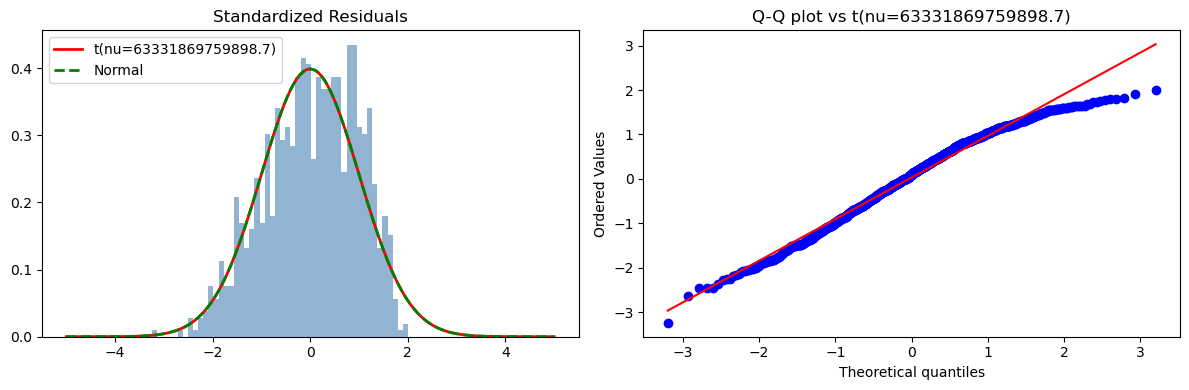

In [74]:
# Get filtered vol from posterior mean parameters
filtered_means_pf, _, _ = particle_filter_sv(
    regression_returns_1d,
    mu=mu_samples.mean(),
    phi=phi_samples.mean(),
    sigma_eta=sigma_eta_samples.mean(),
    mu_return=mu_return,
    N=1000
)
sigma_pf = np.sqrt(np.exp(filtered_means_pf))

# Standardized residuals
z_pf = (regression_returns_1d - mu_return) / sigma_pf

# Basic checks
print(f"z_pf mean:     {z_pf.mean():.4f}")   # should be ~0
print(f"z_pf std:      {z_pf.std():.4f}")    # should be ~1
print(f"z_pf skew:     {scipy_stats.skew(z_pf):.4f}")
print(f"z_pf kurtosis: {scipy_stats.kurtosis(z_pf):.4f}")  # >0 = fat tails

# Fit t-distribution
nu_pf, mu_pf_fit, scale_pf_fit = scipy_stats.t.fit(z_pf, floc=0, fscale=1)
print(f"\nFitted nu: {nu_pf:.4f}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram vs t-distribution
x = np.linspace(-5, 5, 200)
axes[0].hist(z_pf, bins=50, density=True, alpha=0.6, color='steelblue')
axes[0].plot(x, scipy_stats.t.pdf(x, df=nu_pf), 
             color='red', lw=2, label=f't(nu={nu_pf:.1f})')
axes[0].plot(x, scipy_stats.norm.pdf(x), 
             color='green', lw=2, linestyle='--', label='Normal')
axes[0].set_title("Standardized Residuals")
axes[0].legend()

# Q-Q plot
scipy_stats.probplot(z_pf, dist=scipy_stats.t(df=nu_pf), plot=axes[1])
axes[1].set_title(f"Q-Q plot vs t(nu={nu_pf:.1f})")

plt.tight_layout()
plt.show()

### Sequential Stochastic Volatility

This follows the same process as EGARCH 

In [204]:
# Extract posterior mean parameters first
mu_post_sv        = mu_samples.mean()
phi_post_sv       = phi_samples.mean()
sigma_eta_post_sv = sigma_eta_samples.mean()
mu_return_post_sv = mu_return_samples.mean()

print(f"mu_post_sv:        {mu_post_sv:.4f}")
print(f"phi_post_sv:       {phi_post_sv:.4f}")
print(f"sigma_eta_post_sv: {sigma_eta_post_sv:.4f}")
print(f"mu_return_post_sv: {mu_return_post_sv:.6f}")

# Then run particle filter
filtered_reg, _, particle_carry = particle_filter_sv(
    regression_returns_1d,
    mu=mu_post_sv,
    phi=phi_post_sv,
    sigma_eta=sigma_eta_post_sv,
    mu_return=mu_return_post_sv,
    N=2000
)

ls2_carry_sv = filtered_reg[-1]
print(f"ls2_carry_sv:   {ls2_carry_sv:.4f}")
print(f"sigma_carry_sv: {np.sqrt(np.exp(ls2_carry_sv)):.6f}")


mu_post_sv:        -9.7405
phi_post_sv:       0.9481
sigma_eta_post_sv: 0.3821
mu_return_post_sv: 0.001366
ls2_carry_sv:   -9.9810
sigma_carry_sv: 0.006802


In [205]:
# Reset before SV sequential loop
sigma_eta_noise_current = sigma_eta_meas_sv  # reset to SV regression noise
print(f"Reset sigma_eta_noise_current: {sigma_eta_noise_current:.4f}")

Reset sigma_eta_noise_current: 0.1783


In [207]:
# Window boundaries — same as EGARCH
window_boundaries = pd.date_range(start="2022-01-01",
                                   end="2026-01-01",
                                   freq="6MS")

# Verify no overlaps
for i in range(len(window_boundaries)-1):
    window_start = window_boundaries[i]
    window_end   = window_boundaries[i+1] - pd.Timedelta(days=1)
    w = full_returns[window_start:window_end]
    print(f"Window {i+1}: {w.index[0].date()} to {w.index[-1].date()}, n={len(w)}")

# Storage
all_pit_sv_seq  = []
all_vol_sv_seq  = []
all_ret_sv_seq  = []
all_window_stats_sv = []

# Initialize particle cloud from regression end state
N_seq     = 2000
particles = particle_carry.copy()

# Noise from regression
sigma_eta_noise_current = sigma_eta_meas_sv

print(f"Initial params:")
print(f"mu:        {mu_post_sv:.4f}")
print(f"phi:       {phi_post_sv:.4f}")
print(f"sigma_eta: {sigma_eta_post_sv:.4f}")
print(f"mu_return: {mu_return_post_sv:.6f}")
print(f"sigma_carry: {np.sqrt(np.exp(ls2_carry_sv)):.6f}")

Window 1: 2022-01-03 to 2022-06-30, n=124
Window 2: 2022-07-01 to 2022-12-30, n=127
Window 3: 2023-01-03 to 2023-06-30, n=124
Window 4: 2023-07-03 to 2023-12-29, n=126
Window 5: 2024-01-02 to 2024-06-28, n=124
Window 6: 2024-07-01 to 2024-12-31, n=128
Window 7: 2025-01-02 to 2025-06-30, n=122
Window 8: 2025-07-01 to 2025-12-30, n=127
Initial params:
mu:        -9.7405
phi:       0.9481
sigma_eta: 0.3821
mu_return: 0.001366
sigma_carry: 0.006802


In [208]:
def pmcmc_sequential(returns, n_mcmc=1000, N=500,
                     mu_init=None, phi_init=None,
                     sigma_eta_init=None, mu_return_init=None,
                     # Prior parameters — updated from previous posterior
                     mu_prior_mu=None, mu_prior_std=1.0,
                     phi_prior_a=7, phi_prior_b=1,
                     sigma_eta_prior_scale=0.5,
                     mu_return_prior_mu=None, mu_return_prior_std=0.001):
    
    mu_prior_mu        = mu_prior_mu or mu_init
    mu_return_prior_mu = mu_return_prior_mu or mu_return_init
    
    theta_current = np.array([mu_init, phi_init,
                               sigma_eta_init, mu_return_init])
    _, ll_current, _ = particle_filter_sv(returns, *theta_current, N=N)
    
    samples    = np.zeros((n_mcmc, 4))
    ll_history = np.zeros(n_mcmc)
    accepted   = 0
    
    proposal_std   = np.array([0.2, 0.02, 0.05, 0.0002])
    target_rate    = 0.20
    adapt_interval = 50
    adapt_end      = 500
    scale_factor   = 0.85
    
    def log_prior(theta):
        mu_p, phi_p, sigma_eta_p, mu_ret_p = theta
        lp  = scipy_stats.norm.logpdf(mu_p,     mu_prior_mu,        mu_prior_std)
        lp += scipy_stats.beta.logpdf(phi_p,    phi_prior_a,        phi_prior_b)
        lp += scipy_stats.halfnorm.logpdf(sigma_eta_p, scale=sigma_eta_prior_scale)
        lp += scipy_stats.norm.logpdf(mu_ret_p, mu_return_prior_mu, mu_return_prior_std)
        return lp
    
    print("Running Sequential PMCMC...")
    for i in range(n_mcmc):
        if i > 0 and i < adapt_end and i % adapt_interval == 0:
            current_rate = accepted / i
            if current_rate < target_rate:
                proposal_std *= scale_factor
            else:
                proposal_std /= scale_factor
            proposal_std = np.clip(proposal_std, 1e-4, 1.0)
            print(f"Step {i}: rate={current_rate:.2%}, "
                  f"proposal_std={proposal_std.round(4)}")
        elif i % 100 == 0:
            print(f"Step {i}/{n_mcmc}, "
                  f"acceptance rate: {accepted/(i+1) if i>0 else 0:.2%}")
        
        theta_proposed = theta_current + np.random.normal(0, proposal_std, 4)
        
        if np.abs(theta_proposed[1]) >= 1:
            samples[i] = theta_current; ll_history[i] = ll_current; continue
        if theta_proposed[2] <= 0:
            samples[i] = theta_current; ll_history[i] = ll_current; continue
        
        _, ll_proposed, _ = particle_filter_sv(returns, *theta_proposed, N=N)
        
        log_alpha = (ll_proposed + log_prior(theta_proposed)) - \
                    (ll_current  + log_prior(theta_current))
        
        if np.log(np.random.uniform()) < log_alpha:
            theta_current = theta_proposed
            ll_current    = ll_proposed
            accepted     += 1
        
        samples[i]    = theta_current
        ll_history[i] = ll_current
    
    print(f"Final acceptance rate: {accepted/n_mcmc:.2%}")
    return samples, ll_history
  


In [209]:
# Initialize prior params before loop
phi_a_new, phi_b_new       = fit_beta_params(phi_samples)
sigma_eta_scale_new        = max(float(sigma_eta_samples.std()), 0.05)
mu_std_new                 = max(float(mu_samples.std()), 0.1)
mu_return_std_new          = max(float(mu_return_samples.std()), 0.0001)

for i in range(len(window_boundaries)-1):
    window_start = window_boundaries[i]
    window_end   = window_boundaries[i+1] - pd.Timedelta(days=1)
    
    window_returns = full_returns[window_start:window_end]\
                     .values.flatten().astype('float64')
    window_rv      = full_rv[window_start:window_end]\
                     .dropna().values.flatten()
    
    if len(window_returns) < 50:
        continue
    
    print(f"\nWindow {i+1}: {window_start.date()} to {window_end.date()}, "
          f"n={len(window_returns)}")
    
    # ── Step 1: Sequential evaluation BEFORE refit ────────────────────
    pit_w = []
    vol_w = []
    
    for r_t in window_returns:
        # 1. Propagate
        particles = mu_post_sv + phi_post_sv*(particles - mu_post_sv) + \
                    np.random.normal(0, sigma_eta_post_sv, N_seq)
        
        # 2. Reweight
        sigma_t = np.sqrt(np.exp(particles))
        log_w   = scipy_stats.norm.logpdf(r_t,
                                           loc=mu_return_post_sv,
                                           scale=sigma_t)
        max_lw  = log_w.max()
        log_w  -= max_lw
        weights = np.exp(log_w)
        weights /= weights.sum()
        
        # 3. PIT — before update
        u_t = np.mean(scipy_stats.norm.cdf(r_t,
                                            loc=mu_return_post_sv,
                                            scale=sigma_t))
        pit_w.append(u_t)
        vol_w.append(np.sum(weights * sigma_t))
        
        # 4. Resample
        cumsum    = np.cumsum(weights)
        u_rs      = np.random.uniform(0, 1/N_seq) + np.arange(N_seq)/N_seq
        idx_rs    = np.searchsorted(cumsum, u_rs)
        particles = particles[idx_rs]
    
    # Store
    all_pit_sv_seq.extend(pit_w)
    all_vol_sv_seq.extend(vol_w)
    all_ret_sv_seq.extend(window_returns)
    
    all_window_stats_sv.append({
        "window":          i+1,
        "start":           str(window_start.date()),
        "end":             str(window_end.date()),
        "n_obs":           len(window_returns),
        "pit_coverage":    float(np.mean((np.array(pit_w) >= 0.025) &
                                          (np.array(pit_w) <= 0.975))),
        "mu":              float(mu_post_sv),
        "phi":             float(phi_post_sv),
        "sigma_eta":       float(sigma_eta_post_sv),
        "mu_return":       float(mu_return_post_sv),
        "sigma_eta_noise": float(sigma_eta_noise_current)
    })
    print(f"Window {i+1} PIT coverage: {all_window_stats_sv[-1]['pit_coverage']:.2%}")
    
    # ── Step 2: Refit PMCMC with updated priors ───────────────────────
    samples_w_sv, _ = pmcmc_sequential(
        window_returns,
        n_mcmc=1500, N=2000,
        mu_init=mu_post_sv,
        phi_init=phi_post_sv,
        sigma_eta_init=sigma_eta_post_sv,
        mu_return_init=mu_return_post_sv,
        mu_prior_mu=mu_post_sv,
        mu_prior_std=mu_std_new,
        phi_prior_a=phi_a_new,
        phi_prior_b=phi_b_new,
        sigma_eta_prior_scale=sigma_eta_scale_new,
        mu_return_prior_mu=mu_return_post_sv,
        mu_return_prior_std=mu_return_std_new
    )
    burnin_w     = 500
    samples_w_sv = samples_w_sv[burnin_w:]
    
    print(f"Window {i+1} acceptance rate: "
          f"{samples_w_sv.shape[0]/(1500-500):.2%}")
    
    # ── Step 3: Update parameters ─────────────────────────────────────
    mu_post_sv        = samples_w_sv[:, 0].mean()
    phi_post_sv       = samples_w_sv[:, 1].mean()
    sigma_eta_post_sv = samples_w_sv[:, 2].mean()
    mu_return_post_sv = samples_w_sv[:, 3].mean()
    
    print(f"Updated params: mu={mu_post_sv:.4f}, phi={phi_post_sv:.4f}, "
          f"sigma_eta={sigma_eta_post_sv:.4f}, mu_return={mu_return_post_sv:.6f}")
    
    # ── Step 4: Update prior params for next window ───────────────────
    phi_a_new, phi_b_new    = fit_beta_params(samples_w_sv[:, 1])
    sigma_eta_scale_new     = max(float(samples_w_sv[:, 2].std()), 0.05)
    mu_std_new              = max(float(samples_w_sv[:, 0].std()), 0.1)
    mu_return_std_new       = max(float(samples_w_sv[:, 3].std()), 0.0001)
    
    # ── Step 5: Update noise estimate ────────────────────────────────
    filtered_w, _, particles = particle_filter_sv(
        window_returns,
        mu=mu_post_sv, phi=phi_post_sv,
        sigma_eta=sigma_eta_post_sv,
        mu_return=mu_return_post_sv,
        N=N_seq
    )
    sigma_w  = np.sqrt(np.exp(filtered_w))
    vol_rv_w = sigma_to_rv_vectorized(sigma_w.reshape(1,-1), h=21).flatten()
    
    window_rv_strict = window_rv[:-21] if len(window_rv) > 21 else window_rv
    n_noise = min(len(window_rv_strict), len(vol_rv_w))
    
    if n_noise > 21:
        sigma_eta_noise_current = np.std(
            np.log(window_rv_strict[:n_noise]) - np.log(vol_rv_w[:n_noise]))
        print(f"Updated noise std: {sigma_eta_noise_current:.4f}")
    
    print(f"Carry forward sigma: {np.sqrt(np.exp(filtered_w[-1])):.6f}")

# ── Final evaluation ───────────────────────────────────────────────────
all_pit_sv_seq = np.array(all_pit_sv_seq)
all_vol_sv_seq = np.array(all_vol_sv_seq)
all_ret_sv_seq = np.array(all_ret_sv_seq)

ks_stat_sv_seq, ks_pval_sv_seq = scipy_stats.kstest(all_pit_sv_seq, 'uniform')
coverage_pit_sv_seq = np.mean((all_pit_sv_seq >= 0.025) &
                               (all_pit_sv_seq <= 0.975))
print(f"\nFinal Sequential Results:")
print(f"PIT KS p-value: {ks_pval_sv_seq:.4f}")
print(f"PIT coverage:   {coverage_pit_sv_seq:.2%}")
print(f"Total obs:      {len(all_pit_sv_seq)}")


Window 1: 2022-01-01 to 2022-06-30, n=124
Window 1 PIT coverage: 95.16%
Running Sequential PMCMC...
Step 0/1500, acceptance rate: 0.00%
Step 50: rate=28.00%, proposal_std=[2.353e-01 2.350e-02 5.880e-02 2.000e-04]
Step 100: rate=22.00%, proposal_std=[0.2768 0.0277 0.0692 0.0003]
Step 150: rate=16.00%, proposal_std=[2.353e-01 2.350e-02 5.880e-02 2.000e-04]
Step 200: rate=18.00%, proposal_std=[0.2    0.02   0.05   0.0002]
Step 250: rate=19.60%, proposal_std=[0.17   0.017  0.0425 0.0002]
Step 300: rate=20.33%, proposal_std=[0.2    0.02   0.05   0.0002]
Step 350: rate=20.00%, proposal_std=[2.353e-01 2.350e-02 5.880e-02 2.000e-04]
Step 400: rate=19.00%, proposal_std=[0.2    0.02   0.05   0.0002]
Step 450: rate=20.00%, proposal_std=[2.353e-01 2.350e-02 5.880e-02 2.000e-04]
Step 500/1500, acceptance rate: 20.16%
Step 600/1500, acceptance rate: 19.80%
Step 700/1500, acceptance rate: 20.11%
Step 800/1500, acceptance rate: 19.98%
Step 900/1500, acceptance rate: 19.42%
Step 1000/1500, acceptance 

In order to determine the noise

In [244]:
# ── Initialize with regression residuals ───────────────────────────────
all_log_resid_sv = list(
    np.log(rv_actual_sv) - np.log(rv_mean_sv))

print(f"Regression noise: {np.std(all_log_resid_sv):.4f}")

# ── Accumulate window residuals ────────────────────────────────────────
noise_running_sv = [np.std(all_log_resid_sv)]  # window 0 = regression

seq_vol_rv_sv_seq = sigma_to_rv_vectorized(
    np.array(all_vol_sv_seq).reshape(1,-1), h=21).flatten()

cumulative = 0
for j, stat in enumerate(all_window_stats_sv):
    n_w     = stat['n_obs']
    end_idx = min(cumulative + n_w, len(seq_vol_rv_sv_seq))
    n_valid = min(end_idx - cumulative,
                  len(rv_sequential_1d) - cumulative)

    if n_valid > 21:
        rv_w  = rv_sequential_1d[cumulative:cumulative+n_valid]
        vol_w = seq_vol_rv_sv_seq[cumulative:cumulative+n_valid]
        log_resid_w = np.log(rv_w) - np.log(vol_w)
        all_log_resid_sv.extend(log_resid_w)

    noise_running_sv.append(np.std(all_log_resid_sv))
    print(f"Window {j+1}: n_total={len(all_log_resid_sv)}, "
          f"noise={noise_running_sv[-1]:.4f}")
    cumulative += n_w

# ── Build noisy vol per window ─────────────────────────────────────────
vol_noisy_combined_sv = np.zeros((200, len(seq_vol_rv_sv_seq)))

cumulative = 0
for j, stat in enumerate(all_window_stats_sv):
    n_w     = stat['n_obs']
    end_idx = min(cumulative + n_w, len(seq_vol_rv_sv_seq))
    if cumulative >= len(seq_vol_rv_sv_seq):
        break
    n_valid = end_idx - cumulative
    noise_w = np.random.normal(0, noise_running_sv[j],
                                size=(200, n_valid))
    vol_noisy_combined_sv[:, cumulative:end_idx] = \
        seq_vol_rv_sv_seq[cumulative:end_idx].reshape(1,-1) * np.exp(noise_w)
    cumulative += n_w

# ── CI bands ───────────────────────────────────────────────────────────
rv_lower_seq_sv = np.percentile(vol_noisy_combined_sv, 5,  axis=0)
rv_upper_seq_sv = np.percentile(vol_noisy_combined_sv, 95, axis=0)

n_rv_seq_sv = min(len(rv_sequential_1d), len(seq_vol_rv_sv_seq))

# ── RV Coverage at different levels ───────────────────────────────────
print("\nSV Sequential RV Coverage at different CI levels:")
print("-" * 40)
for level in [80, 85, 90, 95, 99]:
    lower_l = np.percentile(vol_noisy_combined_sv, (100-level)/2, axis=0)
    upper_l = np.percentile(vol_noisy_combined_sv, 100-(100-level)/2, axis=0)
    inside_l = (rv_sequential_1d[:n_rv_seq_sv] >= lower_l[:n_rv_seq_sv]) & \
               (rv_sequential_1d[:n_rv_seq_sv] <= upper_l[:n_rv_seq_sv])
    print(f"{level}% CI coverage: {np.mean(inside_l):.2%}")

# Main 90% coverage
inside_rv_seq_sv   = (rv_sequential_1d[:n_rv_seq_sv] >=
                      rv_lower_seq_sv[:n_rv_seq_sv]) & \
                     (rv_sequential_1d[:n_rv_seq_sv] <=
                      rv_upper_seq_sv[:n_rv_seq_sv])
coverage_rv_seq_sv = np.mean(inside_rv_seq_sv)
print(f"\nMain 90% CI coverage: {coverage_rv_seq_sv:.2%}")

# ── Per window RV breakdown ────────────────────────────────────────────
print("\nPer window RV breakdown:")
cumulative = 0
for j, stat in enumerate(all_window_stats_sv):
    n_w     = stat['n_obs']
    end_idx = min(cumulative + n_w, n_rv_seq_sv)
    if cumulative >= n_rv_seq_sv:
        print(f"Window {stat['window']}: no RV data")
        cumulative += n_w
        continue
    rv_w    = rv_sequential_1d[cumulative:end_idx]
    lower_w = rv_lower_seq_sv[cumulative:end_idx]
    upper_w = rv_upper_seq_sv[cumulative:end_idx]
    n_valid = min(len(rv_w), len(lower_w))
    if n_valid == 0:
        cumulative += n_w
        continue
    inside_w = (rv_w[:n_valid] >= lower_w[:n_valid]) & \
               (rv_w[:n_valid] <= upper_w[:n_valid])
    print(f"Window {stat['window']} ({stat['start']} to {stat['end']}): "
          f"RV={np.mean(inside_w):.2%}, "
          f"noise={noise_running_sv[j]:.4f}, "       # ← updated
          f"ratio={rv_w.mean()/seq_vol_rv_sv_seq[cumulative:end_idx].mean():.3f}")
    cumulative += n_w

# ── Return coverage from PIT ───────────────────────────────────────────
print("\nSV Sequential Return Coverage at different CI levels:")
print("-" * 40)
all_pit_sv_arr = np.array(all_pit_sv_seq)
for level in [50, 60, 70, 80, 85, 90, 95, 99]:
    lower_u    = (100 - level) / 200
    upper_u    = 1 - (100 - level) / 200
    coverage_l = np.mean((all_pit_sv_arr >= lower_u) &
                          (all_pit_sv_arr <= upper_u))
    print(f"{level}% CI coverage: {coverage_l:.2%}")

# ── Per window return coverage ─────────────────────────────────────────
print("\nPer window return (PIT) coverage:")
cumulative = 0
for stat in all_window_stats_sv:
    n_w   = stat['n_obs']
    pit_w = all_pit_sv_arr[cumulative:cumulative+n_w]
    cov_w = np.mean((pit_w >= 0.025) & (pit_w <= 0.975))
    print(f"Window {stat['window']} ({stat['start']} to {stat['end']}): "
          f"{cov_w:.2%}")
    cumulative += n_w

Regression noise: 0.1783
Window 1: n_total=1111, noise=0.1709
Window 2: n_total=1238, noise=0.1684
Window 3: n_total=1362, noise=0.1979
Window 4: n_total=1488, noise=0.2076
Window 5: n_total=1612, noise=0.2106
Window 6: n_total=1740, noise=0.2150
Window 7: n_total=1862, noise=0.2339
Window 8: n_total=1968, noise=0.2319

SV Sequential RV Coverage at different CI levels:
----------------------------------------
80% CI coverage: 64.12%
85% CI coverage: 68.60%
90% CI coverage: 74.11%
95% CI coverage: 80.63%
99% CI coverage: 88.58%

Main 90% CI coverage: 74.11%

Per window RV breakdown:
Window 1 (2022-01-01 to 2022-06-30): RV=100.00%, noise=0.1783, ratio=1.013
Window 2 (2022-07-01 to 2022-12-31): RV=97.64%, noise=0.1709, ratio=1.044
Window 3 (2023-01-01 to 2023-06-30): RV=37.10%, noise=0.1684, ratio=0.711
Window 4 (2023-07-01 to 2023-12-31): RV=58.73%, noise=0.1979, ratio=0.761
Window 5 (2024-01-01 to 2024-06-30): RV=73.39%, noise=0.2076, ratio=0.838
Window 6 (2024-07-01 to 2024-12-31): RV=

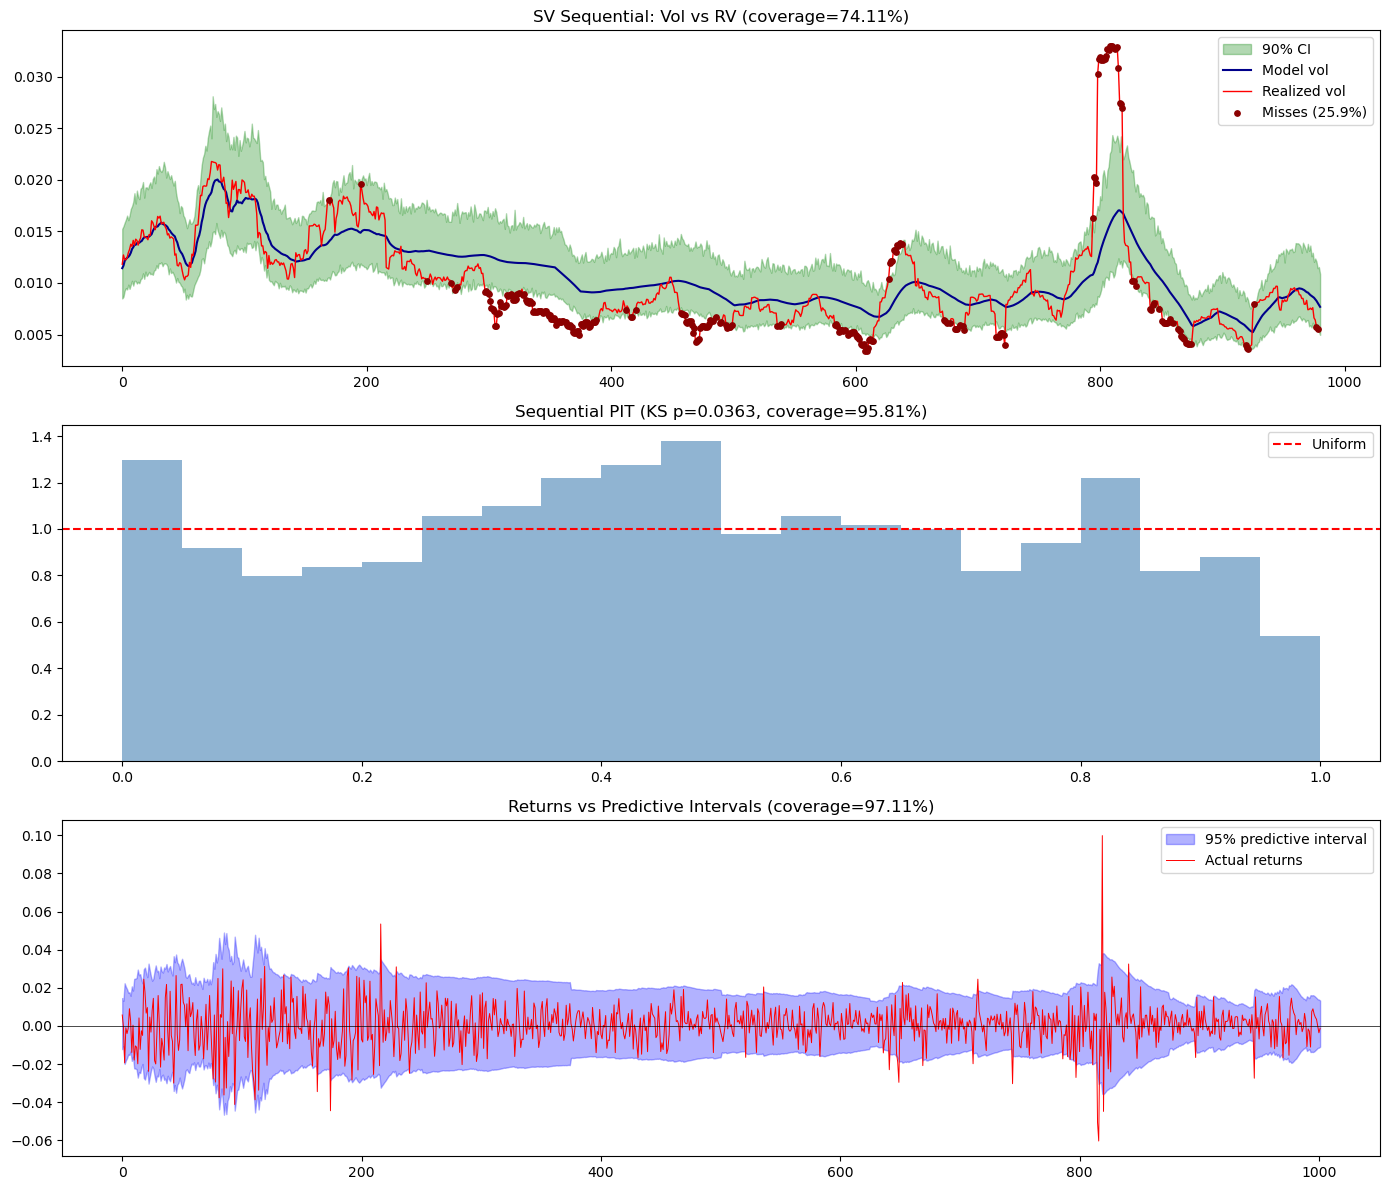

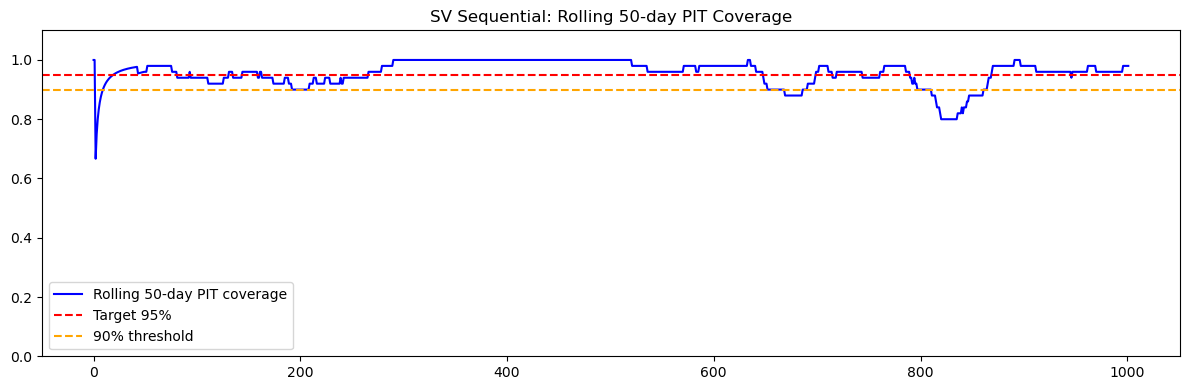

In [245]:

# ── Plots ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# 1. RV plot with misses
miss_idx_sv = np.where(~inside_rv_seq_sv[:n_rv_sv])[0]
axes[0].fill_between(range(n_rv_sv), 
                     rv_lower_seq_sv[:n_rv_sv], rv_upper_seq_sv[:n_rv_sv],
                     alpha=0.3, color='green', label='90% CI')
axes[0].plot(seq_vol_rv_sv[:n_rv_sv], color='darkblue', 
             lw=1.5, label='Model vol')
axes[0].plot(rv_sequential_1d[:n_rv_sv], color='red', 
             lw=1, label='Realized vol')
axes[0].scatter(miss_idx_sv, rv_sequential_1d[miss_idx_sv],
                color='darkred', s=15, zorder=5,
                label=f'Misses ({(1-coverage_rv_seq_sv)*100:.1f}%)')
axes[0].set_title(f"SV Sequential: Vol vs RV (coverage={coverage_rv_seq_sv:.2%})")
axes[0].legend()

# 2. PIT histogram
axes[1].hist(all_pit_sv_seq, bins=20, density=True, 
             alpha=0.6, color='steelblue')
axes[1].axhline(1, color='red', linestyle='--', label='Uniform')
axes[1].set_title(f"Sequential PIT (KS p={ks_pval_sv_seq:.4f}, "
                  f"coverage={coverage_pit_sv_seq:.2%})")
axes[1].legend()

# 3. Returns plot
lower_ret_sv = scipy_stats.norm.ppf(0.025, loc=mu_return_post_sv,
                                     scale=all_vol_sv_seq)
upper_ret_sv = scipy_stats.norm.ppf(0.975, loc=mu_return_post_sv,
                                     scale=all_vol_sv_seq)
inside_ret_sv = (all_ret_sv_seq >= lower_ret_sv) & \
                (all_ret_sv_seq <= upper_ret_sv)

axes[2].fill_between(range(len(all_ret_sv_seq)), 
                     lower_ret_sv, upper_ret_sv,
                     alpha=0.3, color='blue', label='95% predictive interval')
axes[2].plot(all_ret_sv_seq, color='red', lw=0.7, label='Actual returns')
axes[2].axhline(0, color='black', lw=0.5)
axes[2].set_title(f"Returns vs Predictive Intervals "
                  f"(coverage={np.mean(inside_ret_sv):.2%})")
axes[2].legend()

plt.tight_layout()
plt.savefig("sv_sequential.pdf", bbox_inches='tight')
plt.show()

# ── Rolling coverage ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))
rolling_pit_sv = pd.Series(
    ((all_pit_sv_seq >= 0.025) & (all_pit_sv_seq <= 0.975)).astype(float)
).rolling(50, min_periods=1).mean()

ax.plot(rolling_pit_sv, color='blue', lw=1.5, label='Rolling 50-day PIT coverage')
ax.axhline(0.95, color='red', linestyle='--', label='Target 95%')
ax.axhline(0.90, color='orange', linestyle='--', label='90% threshold')
ax.set_ylim(0, 1.1)
ax.set_title("SV Sequential: Rolling 50-day PIT Coverage")
ax.legend()
plt.tight_layout()
plt.savefig("sv_sequential_rolling.pdf", bbox_inches='tight')
plt.show()

In [ ]:
Raw values for monthly breakdown given below. Not particulary interpretable.

In [213]:
# Within-window monthly breakdown
print("Monthly breakdown within windows:")
cumulative = 0
for stat in all_window_stats_egarch:
    window_start = pd.Timestamp(stat['start'])
    window_end   = pd.Timestamp(stat['end'])
    
    # Get monthly boundaries within window
    monthly = pd.date_range(start=window_start, end=window_end, freq='MS')
    
    print(f"\nWindow {stat['window']} ({stat['start']} to {stat['end']}):")
    
    month_start_idx = cumulative
    for m in range(len(monthly)-1):
        m_start = monthly[m]
        m_end   = monthly[m+1] - pd.Timedelta(days=1)
        
        # Get returns in this month
        m_returns = full_returns[m_start:m_end]
        n_m       = len(m_returns)
        end_idx   = month_start_idx + n_m
        
        # PIT coverage for this month
        pit_m = np.array(all_pit_values_egarch)[month_start_idx:end_idx]
        cov_m = np.mean((pit_m >= 0.025) & (pit_m <= 0.975))
        
        # RV coverage for this month
        if month_start_idx < n_rv_seq_egarch:
            rv_m      = rv_sequential_1d[month_start_idx:
                                          min(end_idx, n_rv_seq_egarch)]
            lower_m   = rv_lower_seq_egarch[month_start_idx:
                                             min(end_idx, n_rv_seq_egarch)]
            upper_m   = rv_upper_seq_egarch[month_start_idx:
                                             min(end_idx, n_rv_seq_egarch)]
            inside_m  = (rv_m >= lower_m) & (rv_m <= upper_m)
            rv_cov_m  = np.mean(inside_m)
        else:
            rv_cov_m = float('nan')
        
        print(f"  Month {m+1} ({m_start.strftime('%Y-%m')}): "
              f"PIT={cov_m:.2%}, RV={rv_cov_m:.2%}, n={n_m}")
        
        month_start_idx += n_m
    
    cumulative += stat['n_obs']

Monthly breakdown within windows:

Window 1 (2022-01-01 to 2022-06-30):
  Month 1 (2022-01): PIT=95.00%, RV=100.00%, n=20
  Month 2 (2022-02): PIT=94.74%, RV=100.00%, n=19
  Month 3 (2022-03): PIT=95.65%, RV=100.00%, n=23
  Month 4 (2022-04): PIT=90.00%, RV=100.00%, n=20
  Month 5 (2022-05): PIT=90.48%, RV=100.00%, n=21

Window 2 (2022-07-01 to 2022-12-31):
  Month 1 (2022-07): PIT=100.00%, RV=100.00%, n=20
  Month 2 (2022-08): PIT=91.30%, RV=86.96%, n=23
  Month 3 (2022-09): PIT=95.24%, RV=90.48%, n=21
  Month 4 (2022-10): PIT=100.00%, RV=100.00%, n=21
  Month 5 (2022-11): PIT=85.71%, RV=95.24%, n=21

Window 3 (2023-01-01 to 2023-06-30):
  Month 1 (2023-01): PIT=100.00%, RV=85.00%, n=20
  Month 2 (2023-02): PIT=100.00%, RV=0.00%, n=19
  Month 3 (2023-03): PIT=100.00%, RV=17.39%, n=23
  Month 4 (2023-04): PIT=94.74%, RV=31.58%, n=19
  Month 5 (2023-05): PIT=100.00%, RV=0.00%, n=22

Window 4 (2023-07-01 to 2023-12-31):
  Month 1 (2023-07): PIT=100.00%, RV=10.00%, n=20
  Month 2 (2023-08

In [216]:
# Within-window monthly breakdown — SV
print("SV Monthly breakdown within windows:")
cumulative = 0
for stat in all_window_stats_sv:
    window_start = pd.Timestamp(stat['start'])
    window_end   = pd.Timestamp(stat['end'])
    
    # Get monthly boundaries within window
    monthly = pd.date_range(start=window_start, end=window_end, freq='MS')
    
    print(f"\nWindow {stat['window']} ({stat['start']} to {stat['end']}):")
    
    month_start_idx = cumulative
    for m in range(len(monthly)-1):
        m_start = monthly[m]
        m_end   = monthly[m+1] - pd.Timedelta(days=1)
        
        # Get returns in this month
        m_returns = full_returns[m_start:m_end]
        n_m       = len(m_returns)
        end_idx   = month_start_idx + n_m
        
        # PIT coverage for this month
        pit_m = np.array(all_pit_sv_seq)[month_start_idx:end_idx]
        cov_m = np.mean((pit_m >= 0.025) & (pit_m <= 0.975))
        
        # RV coverage for this month
        if month_start_idx < n_rv_seq_sv:
            rv_m     = rv_sequential_1d[month_start_idx:
                                         min(end_idx, n_rv_seq_sv)]
            lower_m  = rv_lower_seq_sv[month_start_idx:
                                        min(end_idx, n_rv_seq_sv)]
            upper_m  = rv_upper_seq_sv[month_start_idx:
                                        min(end_idx, n_rv_seq_sv)]
            inside_m = (rv_m >= lower_m) & (rv_m <= upper_m)
            rv_cov_m = np.mean(inside_m) if len(inside_m) > 0 else float('nan')
        else:
            rv_cov_m = float('nan')
        
        print(f"  Month {m+1} ({m_start.strftime('%Y-%m')}): "
              f"PIT={cov_m:.2%}, RV={rv_cov_m:.2%}, n={n_m}")
        
        month_start_idx += n_m
    
    cumulative += stat['n_obs']

SV Monthly breakdown within windows:

Window 1 (2022-01-01 to 2022-06-30):
  Month 1 (2022-01): PIT=95.00%, RV=100.00%, n=20
  Month 2 (2022-02): PIT=100.00%, RV=100.00%, n=19
  Month 3 (2022-03): PIT=95.65%, RV=100.00%, n=23
  Month 4 (2022-04): PIT=90.00%, RV=100.00%, n=20
  Month 5 (2022-05): PIT=95.24%, RV=100.00%, n=21

Window 2 (2022-07-01 to 2022-12-31):
  Month 1 (2022-07): PIT=95.00%, RV=100.00%, n=20
  Month 2 (2022-08): PIT=91.30%, RV=100.00%, n=23
  Month 3 (2022-09): PIT=95.24%, RV=100.00%, n=21
  Month 4 (2022-10): PIT=90.48%, RV=100.00%, n=21
  Month 5 (2022-11): PIT=90.48%, RV=100.00%, n=21

Window 3 (2023-01-01 to 2023-06-30):
  Month 1 (2023-01): PIT=100.00%, RV=90.00%, n=20
  Month 2 (2023-02): PIT=100.00%, RV=100.00%, n=19
  Month 3 (2023-03): PIT=100.00%, RV=30.43%, n=23
  Month 4 (2023-04): PIT=100.00%, RV=21.05%, n=19
  Month 5 (2023-05): PIT=100.00%, RV=0.00%, n=22

Window 4 (2023-07-01 to 2023-12-31):
  Month 1 (2023-07): PIT=100.00%, RV=20.00%, n=20
  Month 2 

In [174]:
log_resid_reg_egarch = np.log(rv_actual_egarch) - np.log(rv_mean_egarch)

print(f"EGARCH residuals — mean: {log_resid_reg_egarch.mean():.4f}, "
      f"std: {log_resid_reg_egarch.std():.4f}")

# SV
log_resid_reg_sv = np.log(rv_actual_sv) - np.log(rv_mean_sv)

print(f"SV residuals — mean: {log_resid_reg_sv.mean():.4f}, "
      f"std: {log_resid_reg_sv.std():.4f}")

EGARCH residuals — mean: -0.1428, std: 0.2052
SV residuals — mean: -0.0098, std: 0.1783


In [177]:
all_pit_egarch_arr = np.array(all_pit_values_egarch)
all_pit_sv_arr     = np.array(all_pit_sv_seq)

# Verify lengths match
print(f"EGARCH PIT length: {len(all_pit_egarch_arr)}")
print(f"SV PIT length:     {len(all_pit_sv_arr)}")
print(f"Sequential dates:  {len(sequential_returns.index)}")

# Both should use same dates
n_pit_seq = min(len(all_pit_egarch_arr), len(all_pit_sv_arr))
seq_dates_pit = sequential_returns.index[:n_pit_seq]

print(f"Using n_pit_seq: {n_pit_seq}")

EGARCH PIT length: 1002
SV PIT length:     1002
Sequential dates:  1002
Using n_pit_seq: 1002


In [185]:
rolling_rv_egarch = pd.Series(
    inside_rv_seq_egarch.astype(float),
    index=sequential_returns.index[:n_rv_seq_egarch]
).rolling(63).mean()

# SV
rolling_rv_sv = pd.Series(
    inside_rv_seq_sv.astype(float),
    index=sequential_returns.index[:n_rv_seq_sv]
).rolling(63).mean()

n_rv_combined = min(n_rv_seq_egarch, n_rv_seq_sv)
print(f"EGARCH RV length: {n_rv_seq_egarch}")
print(f"SV RV length:     {n_rv_seq_sv}")

EGARCH RV length: 981
SV RV length:     981


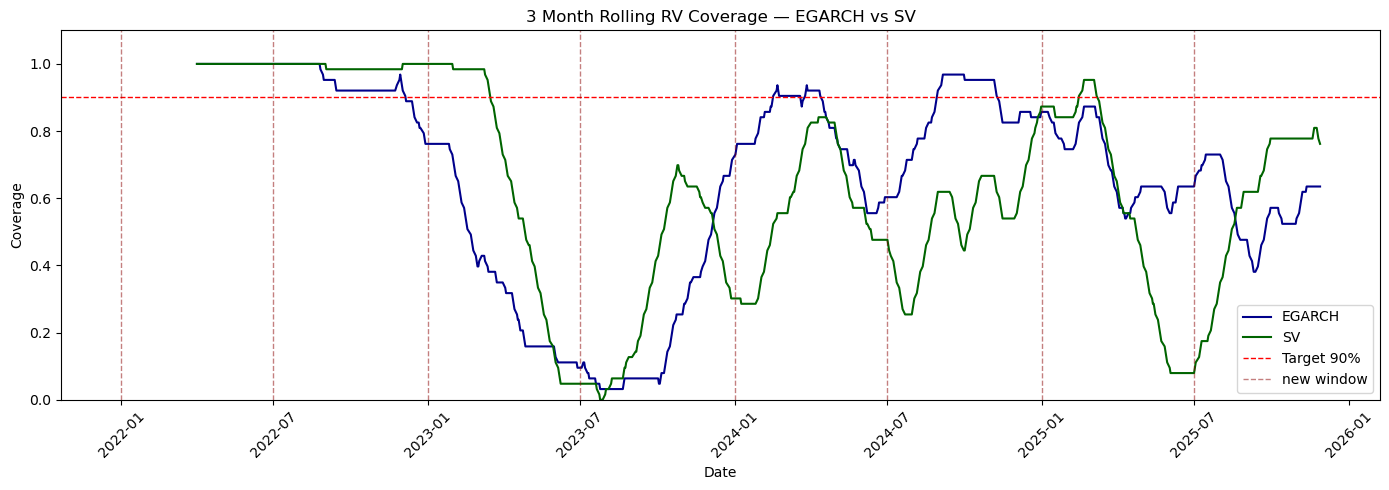

In [211]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(rolling_rv_egarch.index, rolling_rv_egarch,
        color='darkblue', lw=1.5, label='EGARCH')
ax.plot(rolling_rv_sv.index, rolling_rv_sv,
        color='darkgreen', lw=1.5, label='SV')
ax.axhline(0.90, color='red', linestyle='--', lw=1, label='Target 90%')

for date in window_start_dates:
    if date==window_start_dates[0]:
        ax.axvline(date, color='darkred', linestyle='--', alpha=0.5, lw=1, label='new window')
    else:
        ax.axvline(date, color='darkred', linestyle='--', alpha=0.5, lw=1)

ax.set_xlabel("Date")
ax.set_ylabel("Coverage")
ax.set_ylim(0, 1.1)
ax.set_title("3 Month Rolling RV Coverage — EGARCH vs SV")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("sequential_rolling_rv_combined.pdf", bbox_inches='tight')
plt.show()

This graph basically shows the realized volatility coverage across the previous 3 months. 

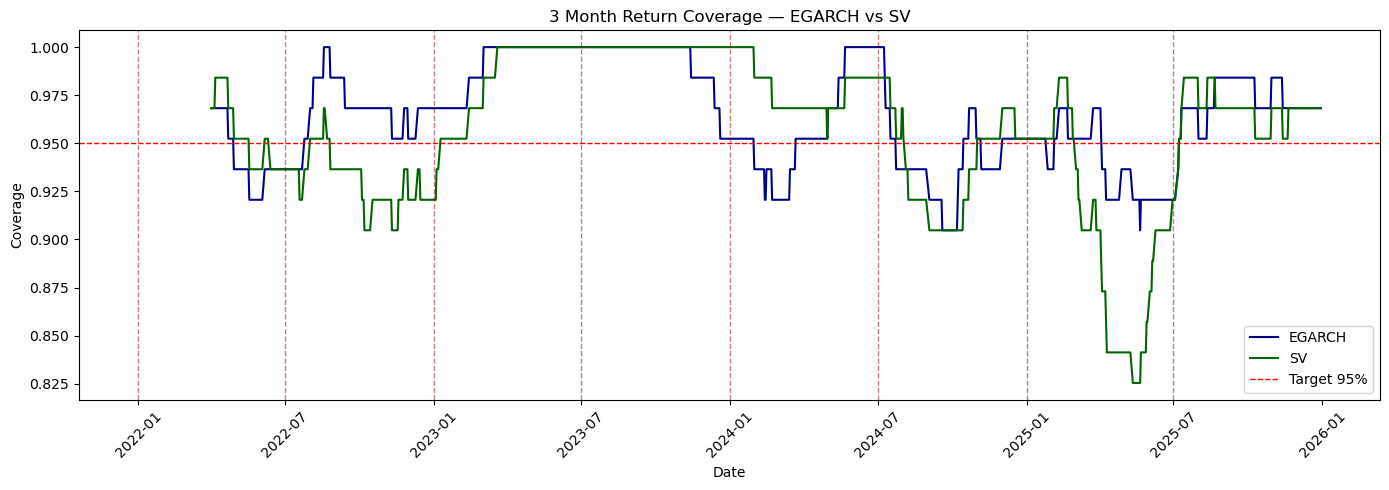

In [256]:
# ── Plot 3: Rolling 50-day PIT coverage combined ───────────────────────
rolling_pit_egarch = pd.Series(
    ((all_pit_egarch_arr >= 0.025) & 
     (all_pit_egarch_arr <= 0.975)).astype(float),
    index=sequential_returns.index[:len(all_pit_egarch_arr)]
).rolling(63).mean()

rolling_pit_sv = pd.Series(
    ((all_pit_sv_arr >= 0.025) & 
     (all_pit_sv_arr <= 0.975)).astype(float),
    index=sequential_returns.index[:len(all_pit_sv_arr)]
).rolling(63).mean()

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(rolling_pit_egarch.index, rolling_pit_egarch,
        color='darkblue', lw=1.5, label='EGARCH')
ax.plot(rolling_pit_sv.index, rolling_pit_sv,
        color='darkgreen', lw=1.5, label='SV')
ax.axhline(0.95, color='red', linestyle='--', lw=1, label='Target 95%')

for date in window_start_dates:
    if date < rolling_pit_egarch.index[-1]:
        ax.axvline(date, color='darkred', linestyle='--', alpha=0.5, lw=1)

ax.set_xlabel("Date")
ax.set_ylabel("Coverage")
ax.set_title("3 Month Return Coverage — EGARCH vs SV")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("sequential_rolling_pit_combined.pdf", bbox_inches='tight')
plt.show()

### Sequential QLIKE

In [237]:
# ── Sequential QLIKE ───────────────────────────────────────────────────
rolling_vol_seq = full_rv.shift(21)["2022-01-01":"2025-12-31"].dropna().values.flatten()

# Sequential model vol — already in RV scale
sigma_mean_egarch_seq = seq_vol_rv_egarch
sigma_mean_sv_seq     = seq_vol_rv_sv_seq

# ── Align all lengths ──────────────────────────────────────────────────
n_dm_seq = min(len(rv_sequential_1d),
               len(rolling_vol_seq),
               len(sigma_mean_egarch_seq),
               len(sigma_mean_sv_seq))

rv_dm_seq = rv_sequential_1d[:n_dm_seq]

# ── QLIKE losses ───────────────────────────────────────────────────────
ql_rolling_seq = qlike(rolling_vol_seq[:n_dm_seq], rv_dm_seq)
ql_egarch_seq  = qlike(sigma_mean_egarch_seq[:n_dm_seq], rv_dm_seq)
ql_sv_seq      = qlike(sigma_mean_sv_seq[:n_dm_seq], rv_dm_seq)

# ── Results ────────────────────────────────────────────────────────────
print("Sequential Mean QLIKE (lower = better):")
print(f"Rolling: {ql_rolling_seq.mean():.6f}")
print(f"EGARCH:  {ql_egarch_seq.mean():.6f}")
print(f"SV:      {ql_sv_seq.mean():.6f}")



Sequential Mean QLIKE (lower = better):
Rolling: 0.395487
EGARCH:  0.101000
SV:      0.160691

DM test sequential (vs Rolling):
EGARCH vs Rolling: DM=10.0164, p=0.0000 → Model better, significant
SV vs Rolling: DM=9.2335, p=0.0000 → Model better, significant

DM test sequential (EGARCH vs SV):
EGARCH vs SV: DM=-6.7016, p=0.0000 → EGARCH better, significant


In [261]:
# ── Sequential QLIKE by window ─────────────────────────────────────────
print("Sequential Mean QLIKE by window (lower = better):")
print(f"{'':20} {'Rolling':>10} {'EGARCH':>10} {'SV':>10}")
print("-" * 55)

# Overall
print(f"{'Overall':20} {ql_rolling_seq.mean():>10.4f} "
      f"{ql_egarch_seq.mean():>10.4f} {ql_sv_seq.mean():>10.4f}")
print("-" * 55)

# Per window
cumulative = 0
for stat in all_window_stats_egarch:
    n_w      = stat['n_obs']
    end_idx  = min(cumulative + n_w, n_dm_seq)
    
    if cumulative >= n_dm_seq:
        break
    
    n_valid  = end_idx - cumulative
    
    ql_roll_w   = ql_rolling_seq[cumulative:end_idx]
    ql_egarch_w = ql_egarch_seq[cumulative:end_idx]
    ql_sv_w     = ql_sv_seq[cumulative:end_idx]
    
    print(f"W{stat['window']} {stat['start']}-{stat['end'][:7]} "
          f"{ql_roll_w.mean():>10.4f} "
          f"{ql_egarch_w.mean():>10.4f} "
          f"{ql_sv_w.mean():>10.4f}")
    
    cumulative += n_w

Sequential Mean QLIKE by window (lower = better):
                        Rolling     EGARCH         SV
-------------------------------------------------------
Overall                  0.3955     0.1010     0.1607
-------------------------------------------------------
W1 2022-01-01-2022-06     0.2578     0.0155     0.0170
W2 2022-07-01-2022-12     0.1093     0.0487     0.0429
W3 2023-01-01-2023-06     0.0842     0.1597     0.2396
W4 2023-07-01-2023-12     0.1296     0.1715     0.1690
W5 2024-01-01-2024-06     0.1702     0.0995     0.1231
W6 2024-07-01-2024-12     0.9491     0.0461     0.1334
W7 2025-01-01-2025-06     1.0283     0.1379     0.4826
W8 2025-07-01-2025-12     0.4464     0.1368     0.0741
